In [1]:
#Load Libraries
library(Seurat)
library(data.table)
library(dplyr)
library(future)

#Set Options
options(future.globals.maxSize = 400000 * 1024^2) #for 300GB max size
plan("multicore", workers = 4)

#Set working directory
setwd("/storage1/fs1/jmillman/Active/DigitalTwin")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# RNA Data Preprocessing

## This Study

### Stage 2 Day 1

In [2]:
#Load RNA data
rna.s2d1 <- Read10X_h5('rawdata/Multiome/S2D1/outs/filtered_feature_bc_matrix.h5')

Genome matrix has multiple modalities, returning a list of matrices for this genome



In [1]:
#Homogenization of gene names
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(rna.s2d1$`Gene Expression`)[colnames(rna.s2d1$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "WRB"] ="GET1"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "AES"] ="TLE5"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "HN1"] ="JPT1"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(rna.s2d1$`Gene Expression`)[rownames(rna.s2d1$`Gene Expression`) == "LARGE1"] ="LARGE"

ERROR: Error: object 'rna.s2d1' not found


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


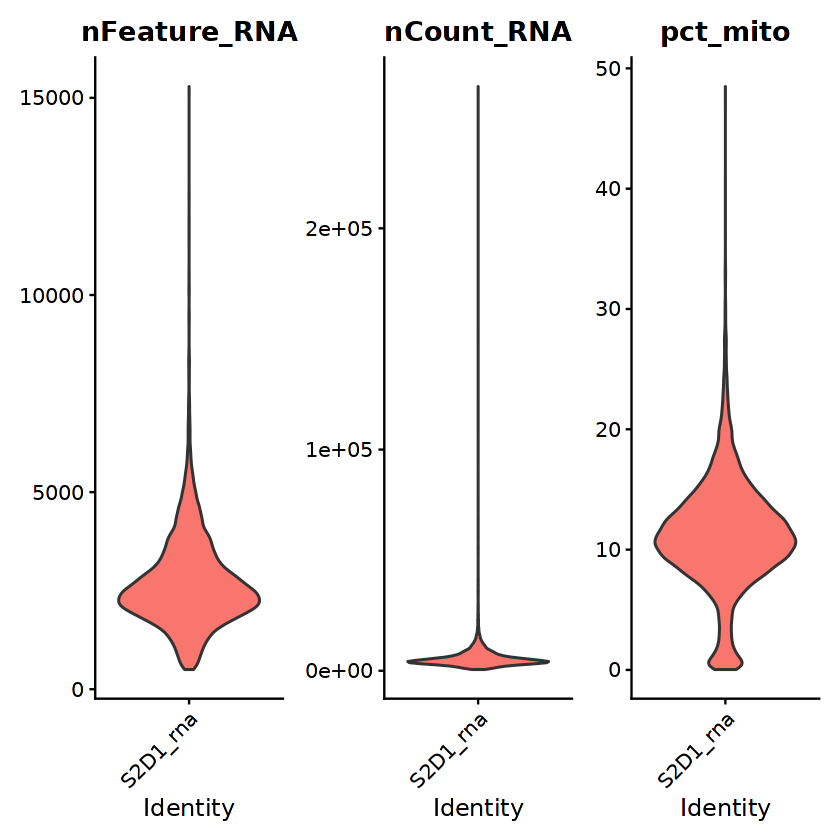

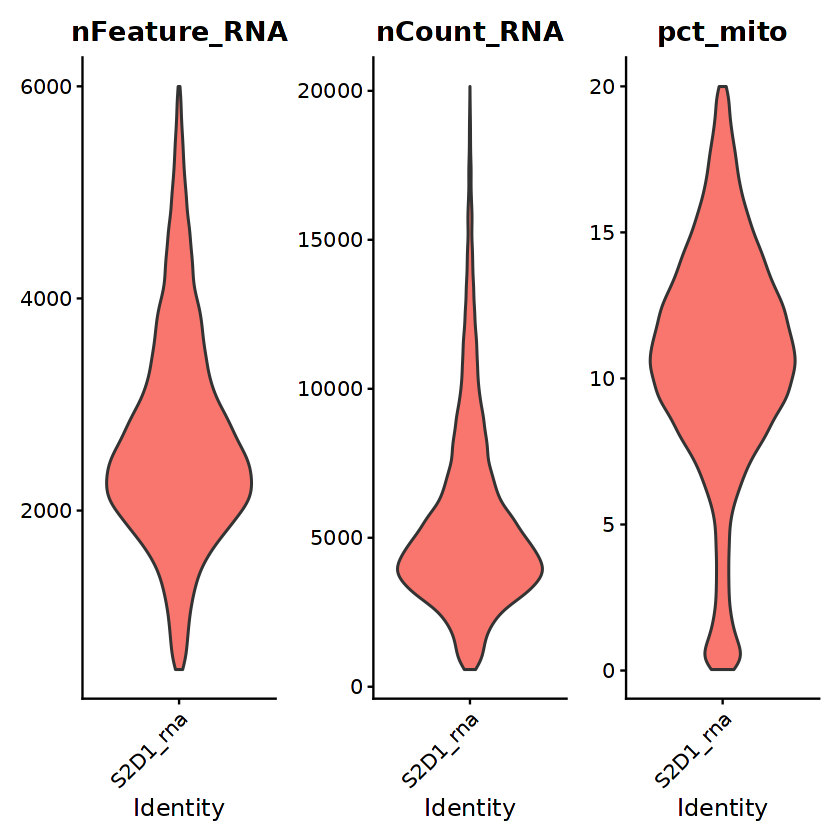

In [4]:
#Create Seurat object
s2d1 <- CreateSeuratObject(counts = rna.s2d1$`Gene Expression`, project = 'S2D1_rna', assay = 'RNA', min.cells = 10, min.features = 500)
rm('rna.s2d1')

#Add metadata
s2d1 = RenameCells(s2d1, add.cell.id = 's2d1')
s2d1$modality = 'paired' 
s2d1$dataset = 'Multiome_s2d1'
s2d1$protocol = 'Millman.v3'
s2d1$stage = 'Stage2_DE'
s2d1$day = 'Day5'
s2d1$cellsource = 'ESC_HUES8'
s2d1$gender = 'male'

#QC filtering
s2d1[['pct_mito']] = PercentageFeatureSet(s2d1, pattern = '^MT-')
VlnPlot(s2d1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

s2d1 <- subset(s2d1, subset = nFeature_RNA > 500 & nFeature_RNA < 6000 & pct_mito < 20)
VlnPlot(s2d1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(s2d1)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
s2d1 = subset(s2d1, features = anti_mt_genes)

#Save Checkpoint
saveRDS(s2d1, file='checkpoints/RNA_datasets/rna_s2d1.rds')
rm(s2d1)

### Stage 3 Day 1

In [5]:
#Load RNA data
rna.s3d1 <- Read10X_h5('rawdata/Multiome/S3D1/outs/filtered_feature_bc_matrix.h5')

Genome matrix has multiple modalities, returning a list of matrices for this genome



In [6]:
#Homogenization of gene names
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(rna.s3d1$`Gene Expression`)[colnames(rna.s3d1$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "WRB"] ="GET1"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "AES"] ="TLE5"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "HN1"] ="JPT1"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(rna.s3d1$`Gene Expression`)[rownames(rna.s3d1$`Gene Expression`) == "LARGE1"] ="LARGE"

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


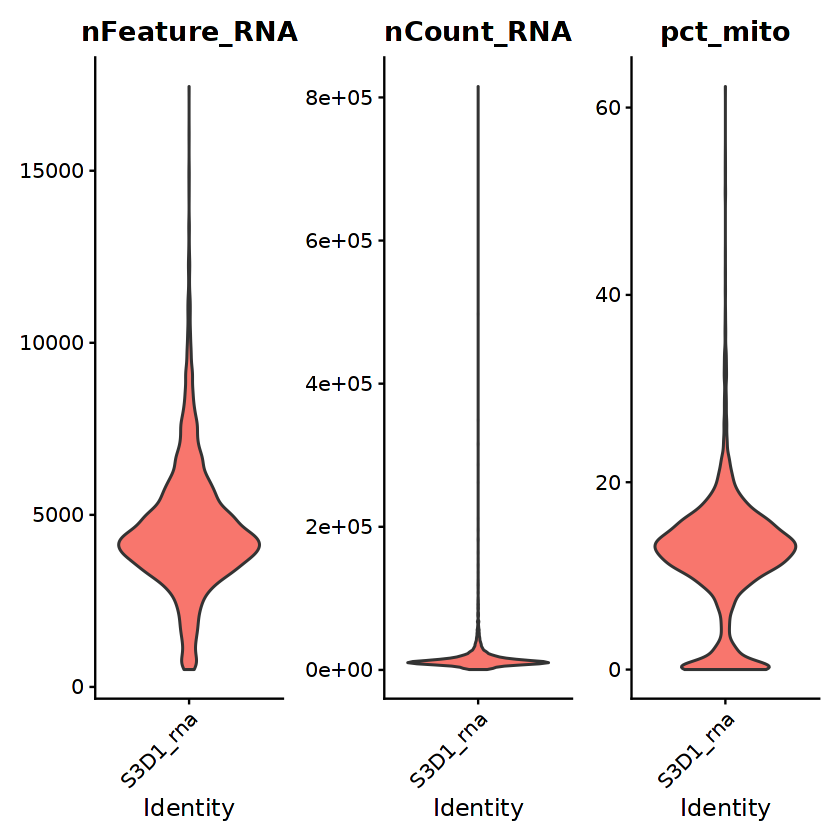

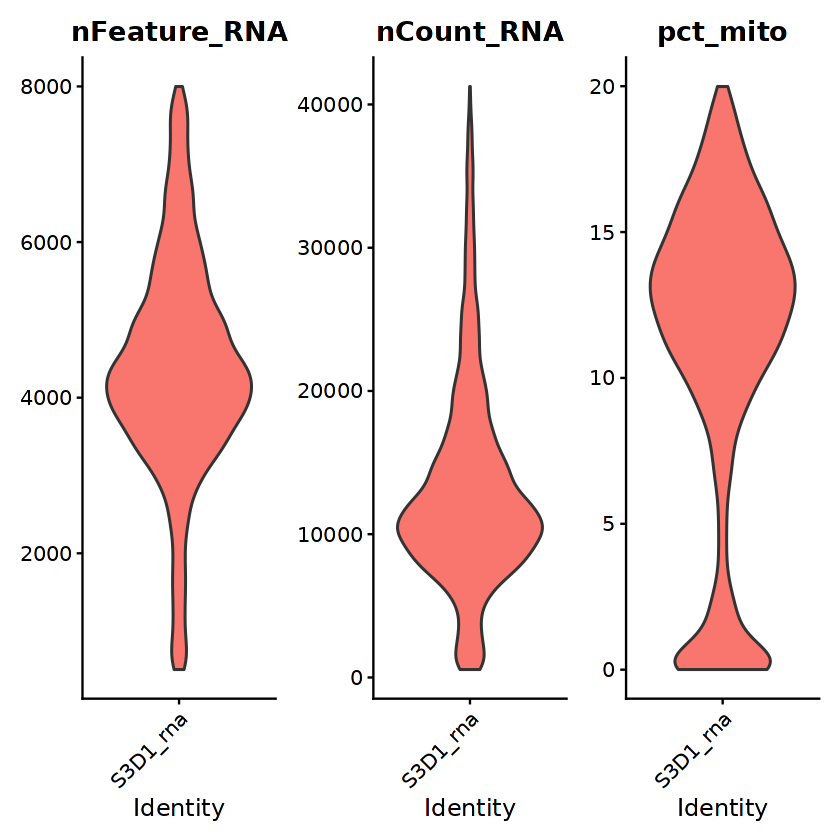

In [7]:
#Create Seurat object
s3d1 <- CreateSeuratObject(counts = rna.s3d1$`Gene Expression`, project = 'S3D1_rna', assay = 'RNA', min.cells = 10, min.features = 500)
rm('rna.s3d1')

#Add metadata
s3d1 = RenameCells(s3d1, add.cell.id = 's3d1')
s3d1$modality = 'paired' 
s3d1$dataset <- 'Multiome_s3d1'
s3d1$protocol = 'Millman.v3'
s3d1$stage = 'Stage3_PGT'
s3d1$day = 'Day7'
s3d1$cellsource = 'ESC_HUES8'
s3d1$gender = 'male'

#QC filtering
s3d1[['pct_mito']] = PercentageFeatureSet(s3d1, pattern = '^MT-')
VlnPlot(s3d1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

s3d1 <- subset(s3d1, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(s3d1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(s3d1)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
s3d1 = subset(s3d1, features = anti_mt_genes)

#Save Checkpoint
saveRDS(s3d1, file='checkpoints/RNA_datasets/rna_s3d1.rds')
rm(s3d1)

### Stage 4 Day 2

In [8]:
#Load RNA data
rna.s4d2 <- Read10X_h5('rawdata/Multiome/S4D2/outs/filtered_feature_bc_matrix.h5')

Genome matrix has multiple modalities, returning a list of matrices for this genome



In [9]:
#Homogenization of gene names
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(rna.s4d2$`Gene Expression`)[colnames(rna.s4d2$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "WRB"] ="GET1"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "AES"] ="TLE5"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "HN1"] ="JPT1"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(rna.s4d2$`Gene Expression`)[rownames(rna.s4d2$`Gene Expression`) == "LARGE1"] ="LARGE"

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


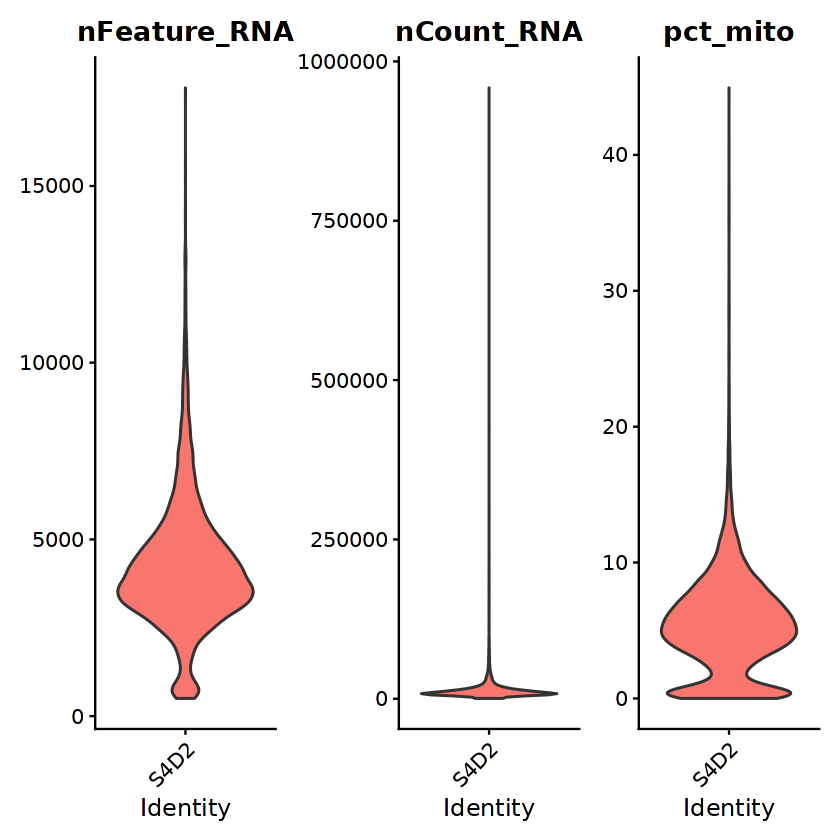

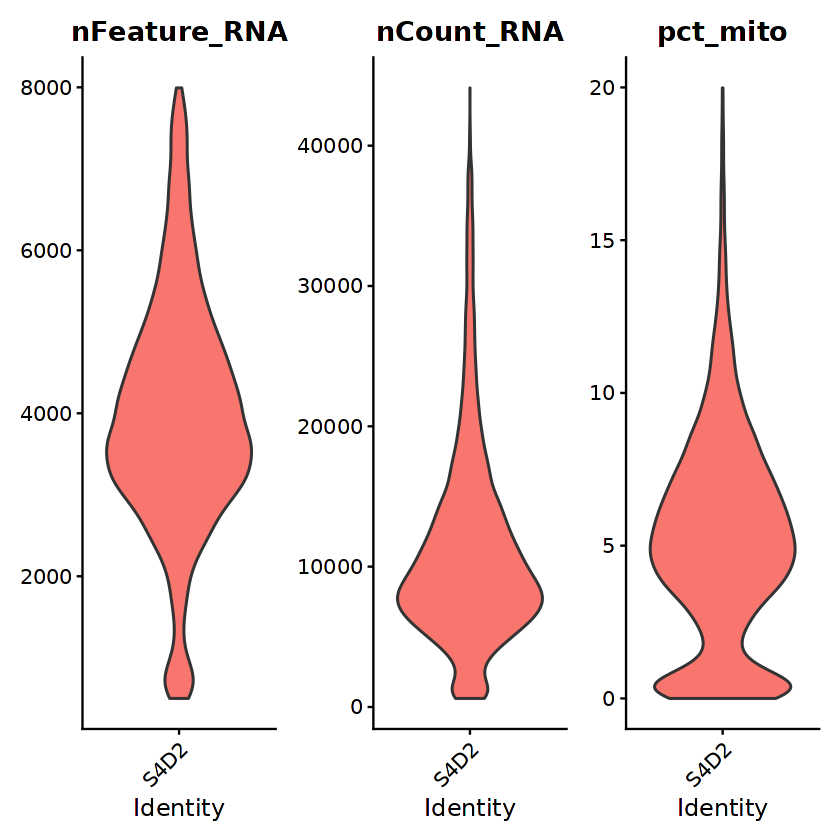

In [10]:
#Create Seurat object
s4d2 <- CreateSeuratObject(counts = rna.s4d2$`Gene Expression`, project = 'S4D2', assay = 'RNA', min.cells = 10, min.features = 500)
rm('rna.s4d2')

#Add metadata
s4d2 = RenameCells(s4d2, add.cell.id = 's4d2')
s4d2$modality = 'paired' 
s4d2$dataset <- 'Multiome_s4d2'
s4d2$protocol = 'Millman.v3'
s4d2$stage = 'Stage4_PP1'
s4d2$day = 'Day10'
s4d2$cellsource = 'ESC_HUES8'
s4d2$gender = 'male'

#QC filtering
s4d2[['pct_mito']] = PercentageFeatureSet(s4d2, pattern = '^MT-')
VlnPlot(s4d2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

s4d2 <- subset(s4d2, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(s4d2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(s4d2)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
s4d2 = subset(s4d2, features = anti_mt_genes)

#Save Checkpoint
saveRDS(s4d2, file='checkpoints/RNA_datasets/rna_s4d2.rds')
rm(s4d2)

### Stage 5 Day 1

In [11]:
#Load RNA data
rna.s5d1 <- Read10X_h5('rawdata/Multiome/S5D1/outs/filtered_feature_bc_matrix.h5')

Genome matrix has multiple modalities, returning a list of matrices for this genome



In [12]:
#Homogenization of gene names
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(rna.s5d1$`Gene Expression`)[colnames(rna.s5d1$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "WRB"] ="GET1"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "AES"] ="TLE5"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "HN1"] ="JPT1"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(rna.s5d1$`Gene Expression`)[rownames(rna.s5d1$`Gene Expression`) == "LARGE1"] ="LARGE"

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


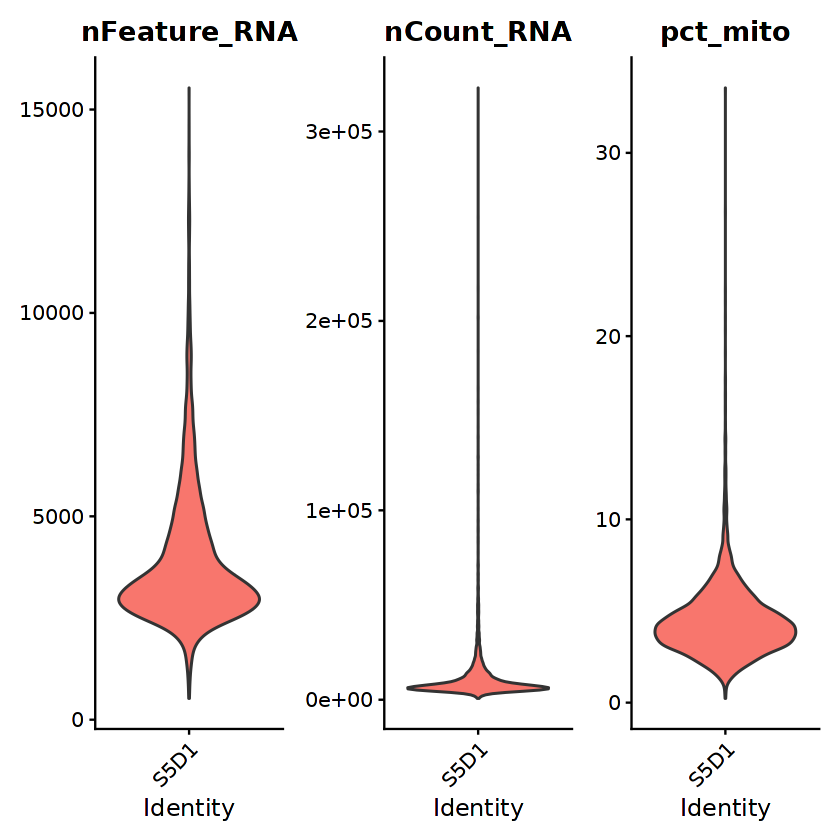

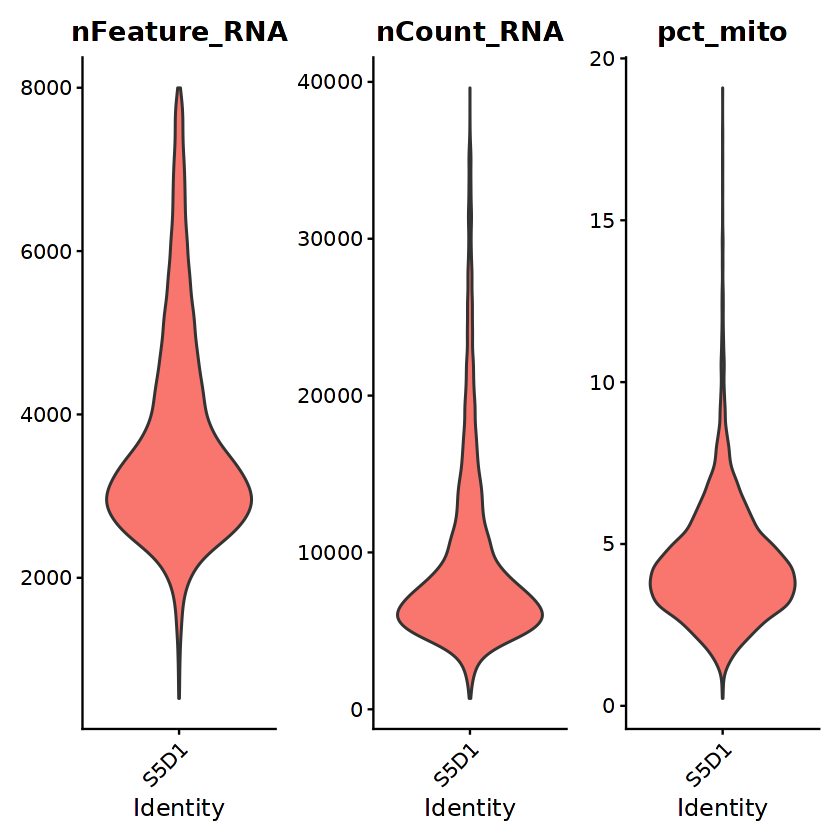

In [13]:
#Create Seurat object
s5d1 <- CreateSeuratObject(counts = rna.s5d1$`Gene Expression`, project = 'S5D1', assay = 'RNA', min.cells = 10, min.features = 500)
rm('rna.s5d1')

#Add metadata
s5d1 = RenameCells(s5d1, add.cell.id = 's5d1')
s5d1$modality = 'paired' 
s5d1$dataset <- 'Multiome_s5d1'
s5d1$protocol = 'Millman.v3'
s5d1$stage = 'Stage5_PP2'
s5d1$day = 'Day13'
s5d1$cellsource = 'ESC_HUES8'
s5d1$gender = 'male'

#QC filtering
s5d1[['pct_mito']] = PercentageFeatureSet(s5d1, pattern = '^MT-')
VlnPlot(s5d1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

s5d1 <- subset(s5d1, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(s5d1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(s5d1)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
s5d1 = subset(s5d1, features = anti_mt_genes)

#Save Checkpoint
saveRDS(s5d1, file='checkpoints/RNA_datasets/rna_s5d1.rds')
rm(s5d1)

### Stage 5 Day 3

In [14]:
#Load RNA data
rna.s5d3 <- Read10X_h5('rawdata/Multiome/S5D3/outs/filtered_feature_bc_matrix.h5')

Genome matrix has multiple modalities, returning a list of matrices for this genome



In [15]:
#Homogenization of gene names
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(rna.s5d3$`Gene Expression`)[colnames(rna.s5d3$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "WRB"] ="GET1"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "AES"] ="TLE5"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "HN1"] ="JPT1"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(rna.s5d3$`Gene Expression`)[rownames(rna.s5d3$`Gene Expression`) == "LARGE1"] ="LARGE"

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


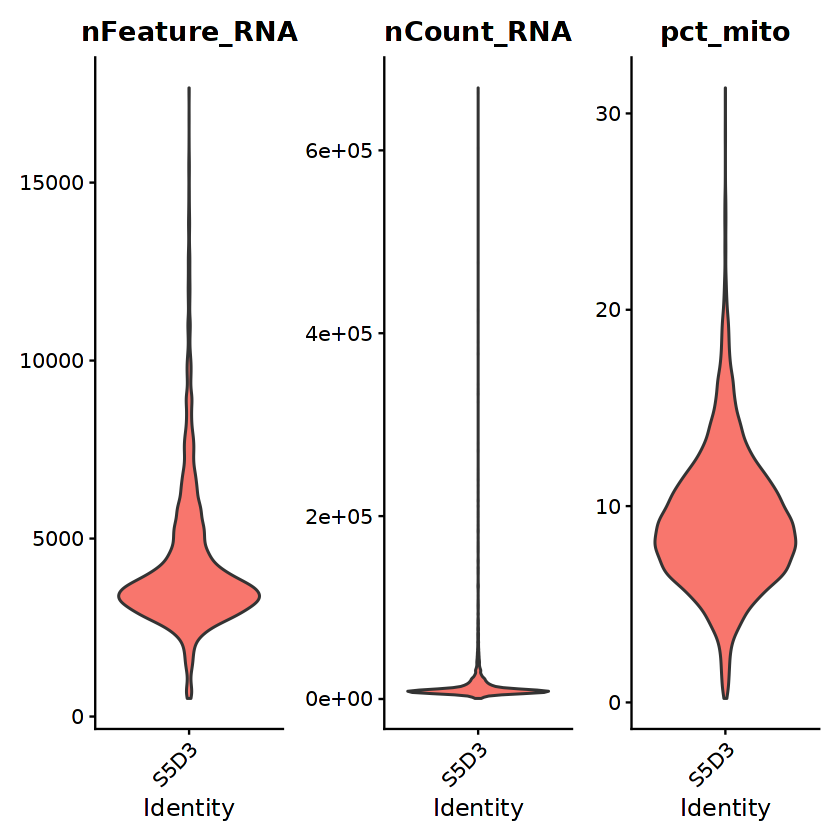

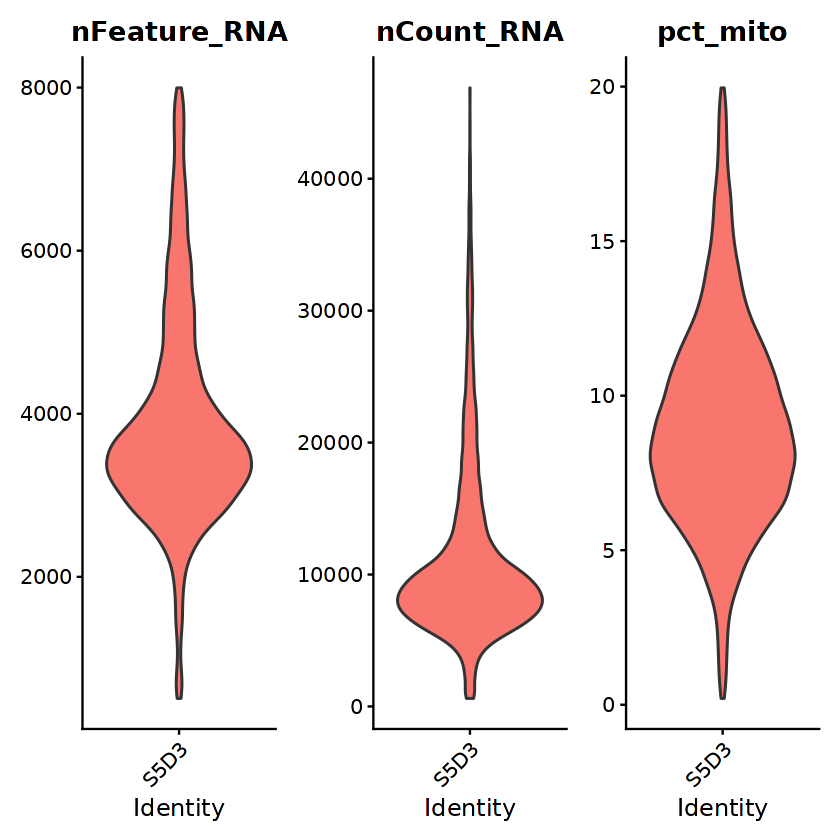

In [16]:
#Create Seurat object
s5d3 <- CreateSeuratObject(counts = rna.s5d3$`Gene Expression`, project = 'S5D3', assay = 'RNA', min.cells = 10, min.features = 500)
rm('rna.s5d3')

#Add metadata
s5d3 = RenameCells(s5d3, add.cell.id = 's5d3')
s5d3$modality = 'paired' 
s5d3$dataset <- 'Multiome_s5d3'
s5d3$protocol = 'Millman.v3'
s5d3$stage = 'Stage5_PP2'
s5d3$day = 'Day15'
s5d3$cellsource = 'ESC_HUES8'
s5d3$gender = 'male'

#QC filtering
s5d3[['pct_mito']] = PercentageFeatureSet(s5d3, pattern = '^MT-')
VlnPlot(s5d3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

s5d3 <- subset(s5d3, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(s5d3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(s5d3)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
s5d3 = subset(s5d3, features = anti_mt_genes)

#Save Checkpoint
saveRDS(s5d3, file='checkpoints/RNA_datasets/rna_s5d3.rds')
rm(s5d3)

### Stage 5 Day 5

In [17]:
#Load RNA data
rna.s5d5 <- Read10X_h5('rawdata/Multiome/S5D5/outs/filtered_feature_bc_matrix.h5')

Genome matrix has multiple modalities, returning a list of matrices for this genome



In [18]:
#Homogenization of gene names
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(rna.s5d5$`Gene Expression`)[colnames(rna.s5d5$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "WRB"] ="GET1"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "AES"] ="TLE5"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "HN1"] ="JPT1"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(rna.s5d5$`Gene Expression`)[rownames(rna.s5d5$`Gene Expression`) == "LARGE1"] ="LARGE"

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


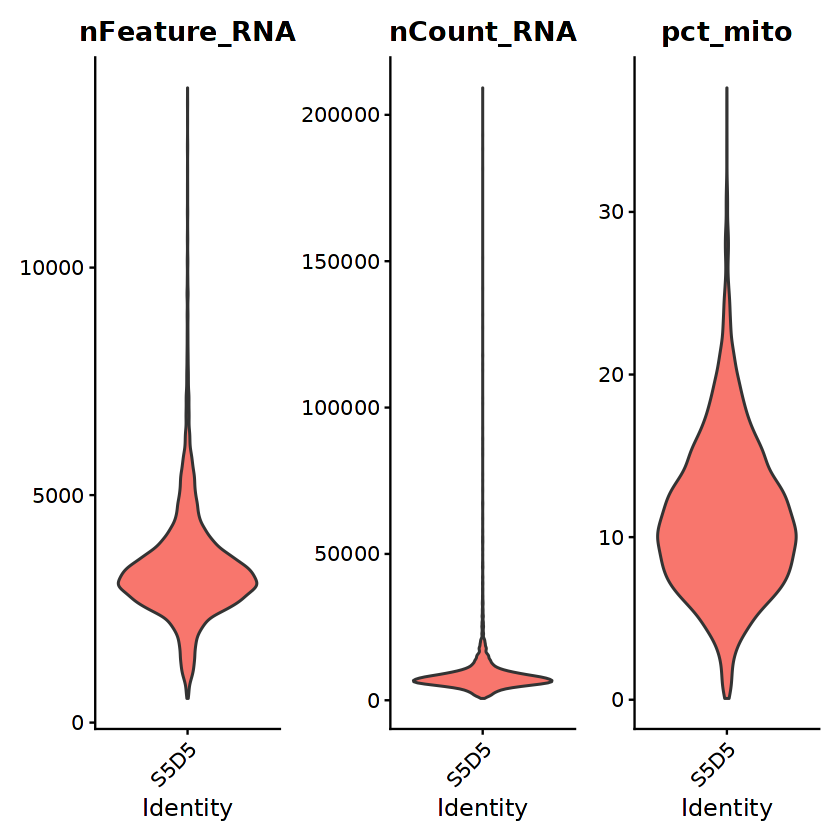

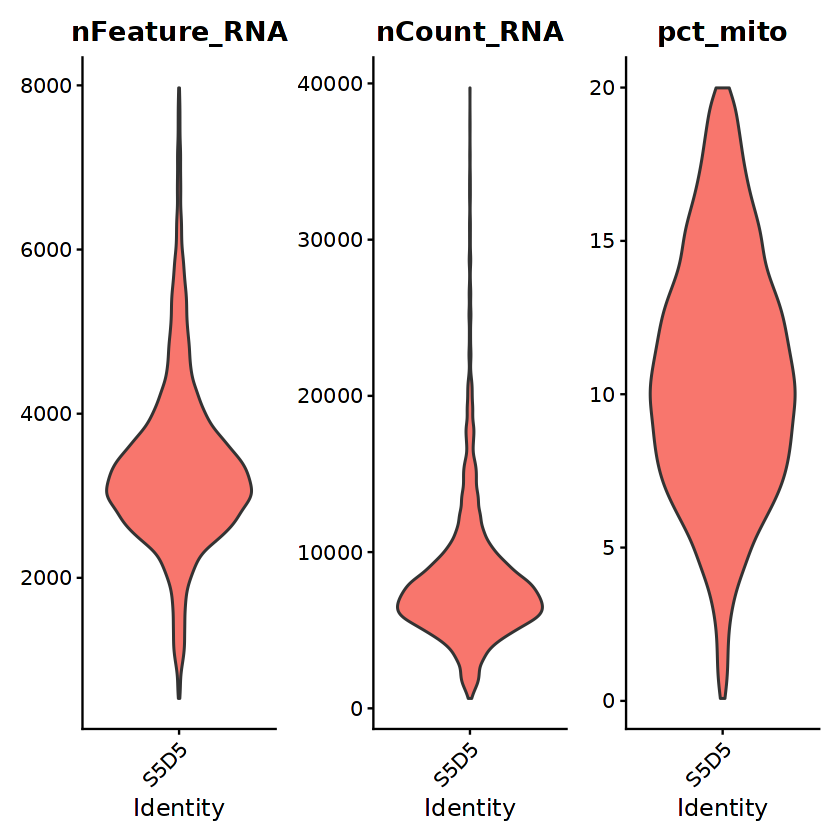

In [19]:

#Create Seurat object
s5d5 <- CreateSeuratObject(counts = rna.s5d5$`Gene Expression`, project = 'S5D5', assay = 'RNA', min.cells = 10, min.features = 500)
rm('rna.s5d5')

#Add metadata
s5d5 = RenameCells(s5d5, add.cell.id = 's5d5')
s5d5$modality = 'paired' 
s5d5$dataset <- 'Multiome_s5d5'
s5d5$protocol = 'Millman.v3'
s5d5$stage = 'Stage5_PP2'
s5d5$day = 'Day17'
s5d5$cellsource = 'ESC_HUES8'
s5d5$gender = 'male'

#QC filtering
s5d5[['pct_mito']] = PercentageFeatureSet(s5d5, pattern = '^MT-')
VlnPlot(s5d5, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

s5d5 <- subset(s5d5, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(s5d5, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(s5d5)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
s5d5 = subset(s5d5, features = anti_mt_genes)

#Save Checkpoint
saveRDS(s5d5, file='checkpoints/RNA_datasets/rna_s5d5.rds')
rm(s5d5)

### Stage 6 Day 1

In [20]:
#Load RNA data
rna.s6d1 <- Read10X_h5('rawdata/Multiome/S6D1/outs/filtered_feature_bc_matrix.h5')

Genome matrix has multiple modalities, returning a list of matrices for this genome



In [21]:
#Homogenization of gene names
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(rna.s6d1$`Gene Expression`)[colnames(rna.s6d1$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "WRB"] ="GET1"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "AES"] ="TLE5"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "HN1"] ="JPT1"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(rna.s6d1$`Gene Expression`)[rownames(rna.s6d1$`Gene Expression`) == "LARGE1"] ="LARGE"

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


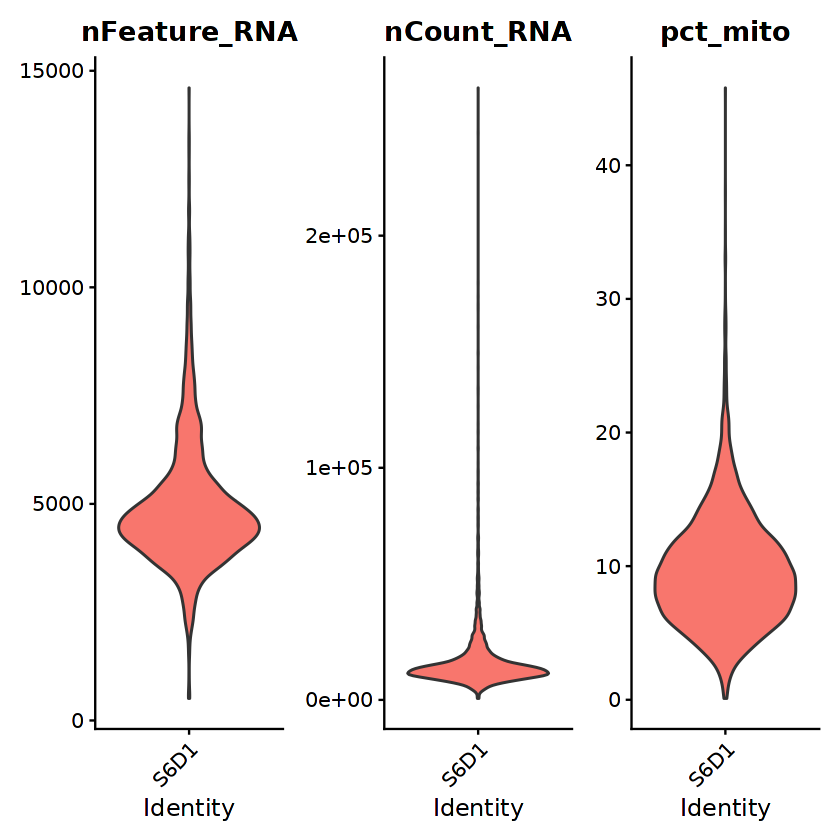

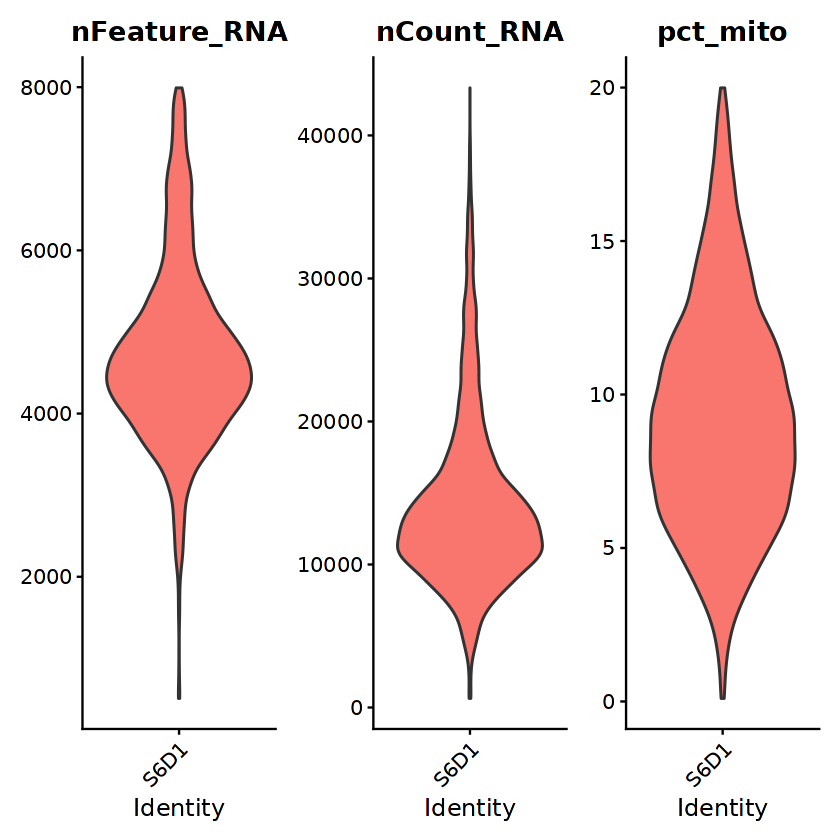

In [22]:
#Create Seurat object
s6d1 <- CreateSeuratObject(counts = rna.s6d1$`Gene Expression`, project = 'S6D1', assay = 'RNA', min.cells = 10, min.features = 500)
rm('rna.s6d1')

#Add metadata
s6d1 = RenameCells(s6d1, add.cell.id = 's6d1')
s6d1$modality = 'paired' 
s6d1$dataset <- 'Multiome_s6d1'
s6d1$protocol = 'Millman.v3'
s6d1$stage = 'Stage6_EP'
s6d1$day = 'Day20'
s6d1$cellsource = 'ESC_HUES8'
s6d1$gender = 'male'

#QC filtering
s6d1[['pct_mito']] = PercentageFeatureSet(s6d1, pattern = '^MT-')
VlnPlot(s6d1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

s6d1 <- subset(s6d1, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(s6d1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(s6d1)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
s6d1 = subset(s6d1, features = anti_mt_genes)

#Save Checkpoint
saveRDS(s6d1, file='checkpoints/RNA_datasets/rna_s6d1.rds')
rm(s6d1)

### Stage 6 Day 7

In [23]:
#Load RNA data
rna.s6d7 <- Read10X_h5("rawdata/Multiome/S6D7/outs/filtered_feature_bc_matrix.h5")

Genome matrix has multiple modalities, returning a list of matrices for this genome



In [24]:
#Homogenization of gene names
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(rna.s6d7$`Gene Expression`)[colnames(rna.s6d7$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "WRB"] ="GET1"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "AES"] ="TLE5"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "HN1"] ="JPT1"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(rna.s6d7$`Gene Expression`)[rownames(rna.s6d7$`Gene Expression`) == "LARGE1"] ="LARGE"

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


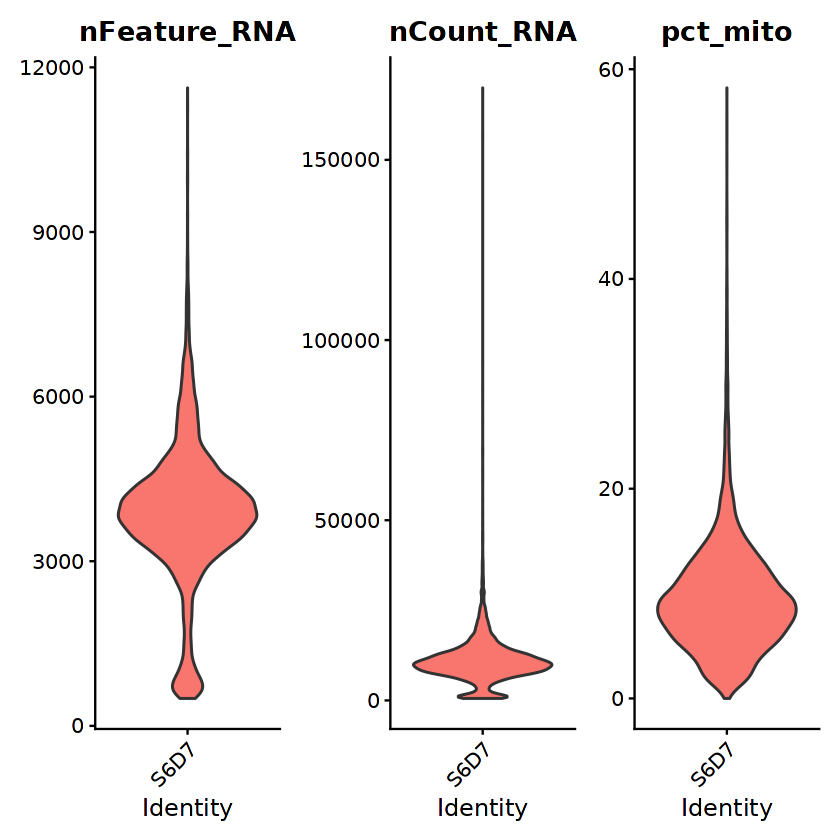

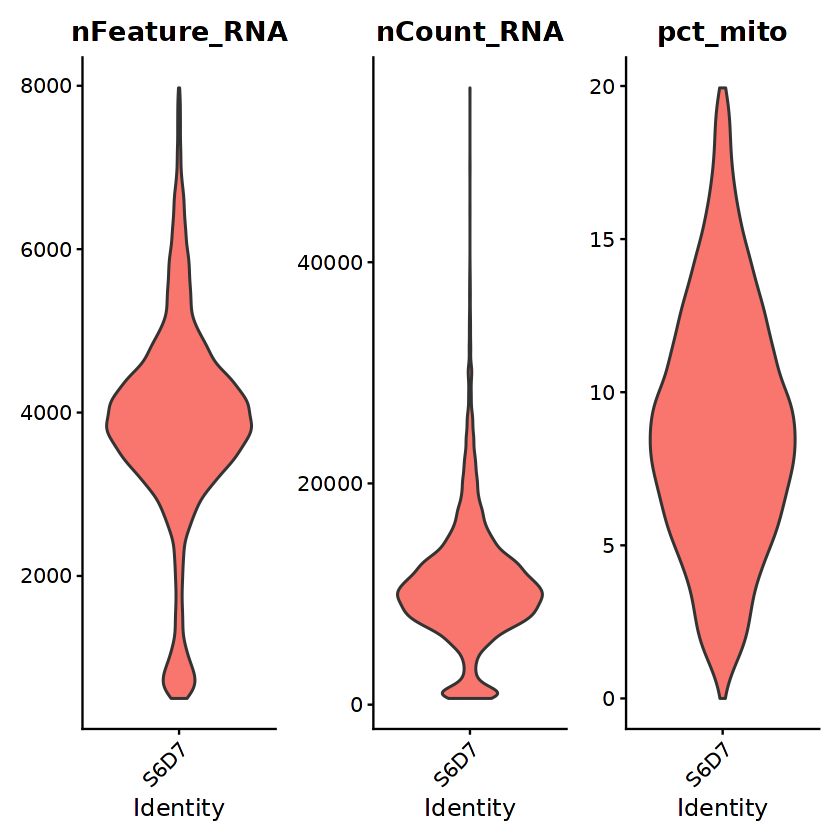

In [25]:
#Create Seurat object
s6d7 <- CreateSeuratObject(counts = rna.s6d7$`Gene Expression`, project = 'S6D7', assay = 'RNA', min.cells = 10, min.features = 500)
rm('rna.s6d7')

#Add metadata
s6d7 = RenameCells(s6d7, add.cell.id = 's6d7')
s6d7$modality = 'paired' 
s6d7$dataset <- 'Multiome_s6d7'
s6d7$protocol = 'Millman.v3'
s6d7$stage = 'Stage7_SCi'
s6d7$day = 'Day26'
s6d7$cellsource = 'ESC_HUES8'
s6d7$gender = 'male'

#QC filtering
s6d7[['pct_mito']] = PercentageFeatureSet(s6d7, pattern = '^MT-')
VlnPlot(s6d7, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

s6d7 <- subset(s6d7, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(s6d7, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(s6d7)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
s6d7 = subset(s6d7, features = anti_mt_genes)

#Save Checkpoint
saveRDS(s6d7, file='checkpoints/RNA_datasets/rna_s6d7.rds')
rm(s6d7)

### Stage 6 Day 14

In [26]:
#Load RNA data
rna.s6d14 <- Read10X_h5("rawdata/Multiome/S6D14/outs/filtered_feature_bc_matrix.h5")

Genome matrix has multiple modalities, returning a list of matrices for this genome



In [27]:
#Homogenization of gene names
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(rna.s6d14$`Gene Expression`)[colnames(rna.s6d14$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "WRB"] ="GET1"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "AES"] ="TLE5"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "HN1"] ="JPT1"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(rna.s6d14$`Gene Expression`)[rownames(rna.s6d14$`Gene Expression`) == "LARGE1"] ="LARGE"

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


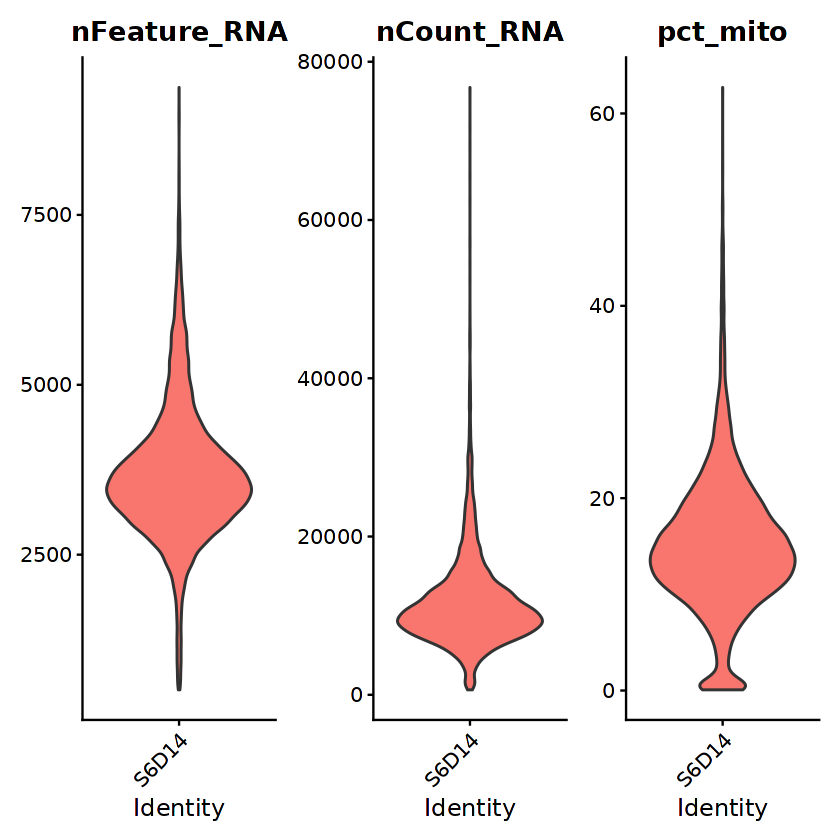

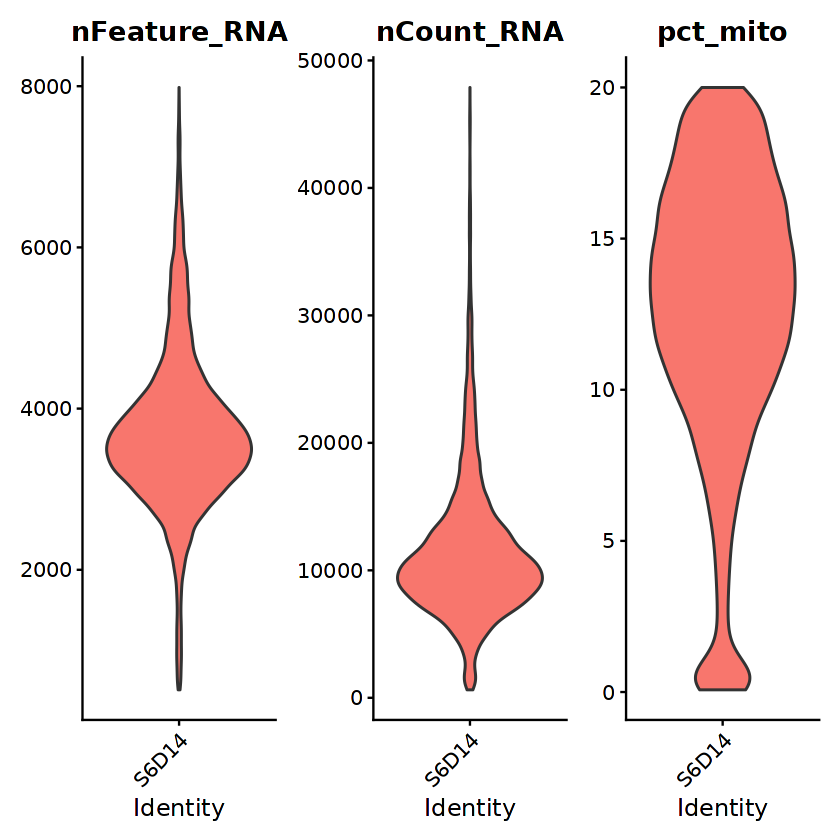

In [28]:
#Create Seurat object
s6d14 <- CreateSeuratObject(counts = rna.s6d14$`Gene Expression`, project = 'S6D14', assay = 'RNA', min.cells = 10, min.features = 500)
rm('rna.s6d14')

#Add metadata
s6d14 = RenameCells(s6d14, add.cell.id = 's6d14')
s6d14$modality = 'paired' 
s6d14$dataset <- 'Multiome_s6d14'
s6d14$protocol = 'Millman.v3'
s6d14$stage = 'Stage7_SCi'
s6d14$day = 'Day33'
s6d14$cellsource = 'ESC_HUES8'
s6d14$gender = 'male'

#QC filtering
s6d14[['pct_mito']] = PercentageFeatureSet(s6d14, pattern = '^MT-')
VlnPlot(s6d14, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

s6d14 <- subset(s6d14, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(s6d14, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(s6d14)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
s6d14 = subset(s6d14, features = anti_mt_genes)

#Save Checkpoint
saveRDS(s6d14, file='checkpoints/RNA_datasets/rna_s6d14.rds')
rm(s6d14)

## Veres et al Nature 2019

### Stage 3 complete Protocol x1

In [29]:
#Load raw data
veres.s3x1.raw <- as.data.frame(fread('rawdata/RNA/Veres/GSM3141954_S3x1.processed_counts.tsv'))
rownames(veres.s3x1.raw)<- veres.s3x1.raw[,1]
veres.s3x1.raw <- t(veres.s3x1.raw[,-1])
veres.s3x1.raw <- as(veres.s3x1.raw, "sparseMatrix") 

In [30]:
#Homogenization of gene names
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5I"] ="ATP5ME"
rownames(veres.s3x1.raw )[colnames(veres.s3x1.raw ) == "ATP5G2"] ="ATP5MC2"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5E"] ="ATP5F1E"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5L"] ="ATP5MG"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "TCEB2"] ="ELOB"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SHFM1"] ="SEM1"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "USMG5"] ="ATP5MD"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "NGFRAP1"] ="BEX3"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM213A"] ="PRXL2A"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "GNB2L1"] ="RACK1"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "TCEB3"] ="ELOA"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C8orf59"] ="RBIS"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C19orf24"] ="FAM174C"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C20orf24"] ="RAB5IF"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM173A"] ="ANTKMT"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C6orf1"] ="SMIM29"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SEPT2"] ="SEPTIN2"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM57B"] ="TLCD3B"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "PVRL2"] ="NECTIN2"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM96A"] ="CIAO2A"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "KIAA1715"] ="LNPK"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "RTFDC1"] ="RTF2"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM134A"] ="RETREG2"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "STRA13"] ="CENPX"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C9orf3"] ="AOPEP"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "HBT8"] ="PWAR6"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "PVRL3"] ="NECTIN3"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "WRB"] ="GET1"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ASNA1"] ="GET3"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM60A"] ="SINHCAF"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM63B"] ="MINDY2"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "COL4A3BP"] ="CERT1"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "WHSC1"] ="NSD2"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "APOPT1"] ="COA8"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "TOMM70A"] ="TOMM70"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "PVRL1"] ="NECTIN1"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "TMEM261"] ="DMAC1"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM195A"] ="MCRIP2"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "PPP2R4"] ="PTPA"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SUMO2.1"] ="SUMO2"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "UQR11.1"] ="UQCR11"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C11orf73"] ="HIKESHI"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C19orf60"] ="REX1BD"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ZCCHC11"] ="TUT4"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "LHFP"] ="LHFPL6"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "MESDC2"] ="MESD"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM127B"] ="RTL8A"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C7orf55"] ="FMC1"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "LINC00493"] ="SMIM26"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "WBSCR22"] ="BUD23"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM105A"] ="OTULINL"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM127A"] ="RTL8C"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C14orf1"] ="ERG28"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SEPT2"] ="SEPTIN2"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "VIMP"] ="SELENOS"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C16orf13"] ="METTL26"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SELM"] ="SELENOM"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM195B"] ="MCRIP1"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "MLLT4"] ="AFDN"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "WBP5"] ="TCEAL9"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SEPT11"] ="SEPTIN11"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C19orf70"] ="MICOS13"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "WHSC1L1"] ="NSD3"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5H"] ="ATP5PD"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "TCEB1"] ="ELOC"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5C1"] ="ATP5F1C"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SEP15"] ="SELENOF"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM96B"] ="CIA02B"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C17orf89"] ="NDUFAF8"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "APOA1BP"] ="NAXE"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5F1"] ="ATP5PB"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM46A"] ="TENT5A"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C14orf166"] ="RTRAF"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SEPT7"] ="SEPTIN7"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "MINOS1"] ="MICOS10"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C11orf31"] ="SELENOH"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "GLTSCR2"] ="NOP53"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "LINC01420"] ="NBDY"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "FAM159B"] ="SHISAL2B"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C7orf73"] ="STMP1"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "C19orf43"] ="TRIR"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SELT"] ="SELENOT"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "AES"] ="TLE5"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5G1"] ="ATP5MC1"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5B"] ="ATP5F1B"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SEPW1"] ="SELENOW"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5D"] ="ATP5F1D"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5O"] ="ATP5PO"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SELK"] ="SELENOK"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "HN1"] ="JPT1"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATPIF1"] ="ATP5IF1"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5J"] ="ATP5PF"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5A1"] ="ATP5F1A"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5G3"] ="ATP5MC3"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "ATP5J2"] ="ATP5MF"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "MYEOV2"] ="COPS9"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "UQCR11.1"] ="UQCR11"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SUMO2.1"] ="SUMO2"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "LRRC75A-AS1"] ="SNHG29"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "SEPT4"] ="SEPTIN4"
rownames(veres.s3x1.raw )[rownames(veres.s3x1.raw ) == "LARGE1"] ="LARGE"

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


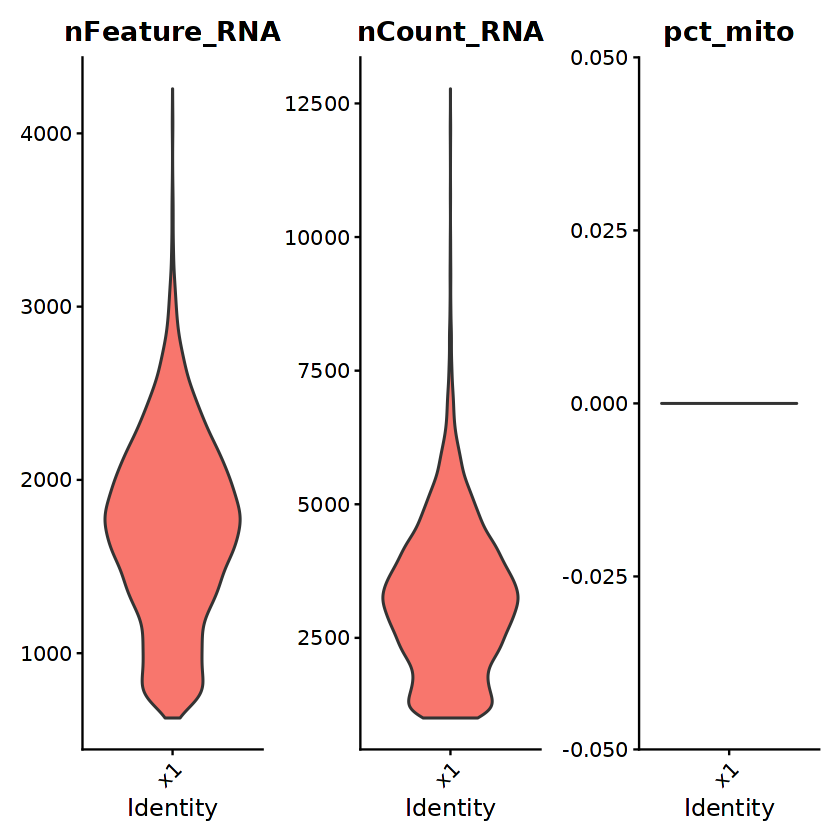

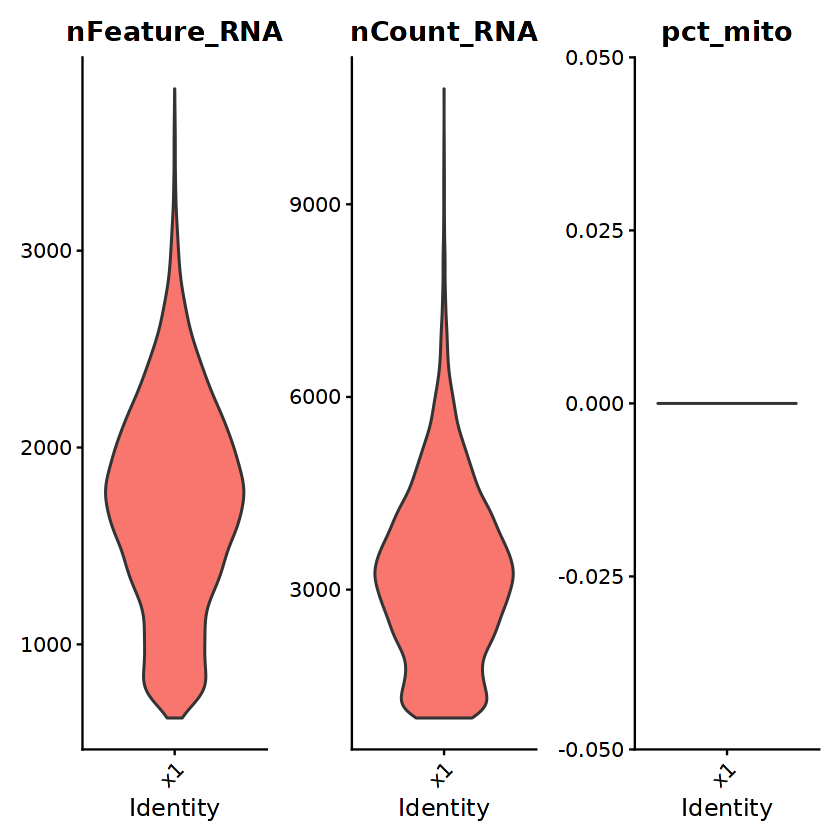

In [31]:
#Load metadata
veres.s3x1.meta <- read.table('rawdata/RNA/Veres/GSM3141954_S3x1.cell_metadata.tsv',header=T,sep='\t')
rownames(veres.s3x1.meta)<- veres.s3x1.meta[,1]
veres.s3x1.meta <- veres.s3x1.meta[,-1]

#Create Seurat object
veres.s3x1 <- CreateSeuratObject(counts=veres.s3x1.raw, project='Veres_s3x1', min.cells = 10, min.features = 500) #meta.data = veres.s3x1.meta,)

#Add metadata
veres.s3x1 = RenameCells(veres.s3x1, add.cell.id = 'veres.s3x1')
veres.s3x1$modality = 'expression'
veres.s3x1$dataset <- 'Veres_s3x1'
veres.s3x1$protocol = 'Veres.x1'
veres.s3x1$stage = 'Stage4_PP1'
veres.s3x1$day = 'Day8'
veres.s3x1$cellsource = 'ESC_HUES8'
veres.s3x1$gender = 'male'

#QC filtering
veres.s3x1[['pct_mito']] = PercentageFeatureSet(veres.s3x1, pattern = '^MT-')
VlnPlot(veres.s3x1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

veres.s3x1 <- subset(veres.s3x1, subset = nFeature_RNA > 500 & nFeature_RNA < 4000 & pct_mito < 20)
VlnPlot(veres.s3x1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(veres.s3x1, file="checkpoints/RNA_datasets/veres_s3x1.rds")
rm(list = c("veres.s3x1.raw","veres.s3x1.meta","veres.s3x1"))

### Stage 3 complete Protocol x2

In [32]:
#Load raw data
veres.s3x2.raw <- as.data.frame(fread('rawdata/RNA/Veres/GSM3141958_S3x2.processed_counts.tsv'))
rownames(veres.s3x2.raw)<- veres.s3x2.raw[,1]
veres.s3x2.raw <- t(veres.s3x2.raw[,-1])
veres.s3x2.raw <- as(veres.s3x2.raw, "sparseMatrix") 

In [33]:
#Homogenization of gene names
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5I"] ="ATP5ME"
rownames(veres.s3x2.raw)[colnames(veres.s3x2.raw) == "ATP5G2"] ="ATP5MC2"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5E"] ="ATP5F1E"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5L"] ="ATP5MG"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "TCEB2"] ="ELOB"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SHFM1"] ="SEM1"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "USMG5"] ="ATP5MD"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "NGFRAP1"] ="BEX3"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM213A"] ="PRXL2A"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "GNB2L1"] ="RACK1"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "TCEB3"] ="ELOA"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C8orf59"] ="RBIS"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C19orf24"] ="FAM174C"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C20orf24"] ="RAB5IF"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM173A"] ="ANTKMT"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C6orf1"] ="SMIM29"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM57B"] ="TLCD3B"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "PVRL2"] ="NECTIN2"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM96A"] ="CIAO2A"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "KIAA1715"] ="LNPK"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "RTFDC1"] ="RTF2"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM134A"] ="RETREG2"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "STRA13"] ="CENPX"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C9orf3"] ="AOPEP"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "HBT8"] ="PWAR6"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "PVRL3"] ="NECTIN3"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "WRB"] ="GET1"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ASNA1"] ="GET3"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM60A"] ="SINHCAF"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM63B"] ="MINDY2"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "COL4A3BP"] ="CERT1"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "WHSC1"] ="NSD2"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "APOPT1"] ="COA8"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "TOMM70A"] ="TOMM70"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "PVRL1"] ="NECTIN1"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "TMEM261"] ="DMAC1"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM195A"] ="MCRIP2"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "PPP2R4"] ="PTPA"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "UQR11.1"] ="UQCR11"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C11orf73"] ="HIKESHI"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C19orf60"] ="REX1BD"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ZCCHC11"] ="TUT4"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "LHFP"] ="LHFPL6"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "MESDC2"] ="MESD"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM127B"] ="RTL8A"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C7orf55"] ="FMC1"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "LINC00493"] ="SMIM26"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "WBSCR22"] ="BUD23"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM105A"] ="OTULINL"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM127A"] ="RTL8C"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C14orf1"] ="ERG28"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "VIMP"] ="SELENOS"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C16orf13"] ="METTL26"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SELM"] ="SELENOM"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM195B"] ="MCRIP1"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "MLLT4"] ="AFDN"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "WBP5"] ="TCEAL9"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SEPT11"] ="SEPTIN11"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C19orf70"] ="MICOS13"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "WHSC1L1"] ="NSD3"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5H"] ="ATP5PD"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "TCEB1"] ="ELOC"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5C1"] ="ATP5F1C"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SEP15"] ="SELENOF"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM96B"] ="CIA02B"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C17orf89"] ="NDUFAF8"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "APOA1BP"] ="NAXE"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5F1"] ="ATP5PB"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM46A"] ="TENT5A"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C14orf166"] ="RTRAF"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SEPT7"] ="SEPTIN7"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "MINOS1"] ="MICOS10"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C11orf31"] ="SELENOH"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "GLTSCR2"] ="NOP53"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "LINC01420"] ="NBDY"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "FAM159B"] ="SHISAL2B"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C7orf73"] ="STMP1"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "C19orf43"] ="TRIR"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SELT"] ="SELENOT"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "AES"] ="TLE5"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5G1"] ="ATP5MC1"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5B"] ="ATP5F1B"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SEPW1"] ="SELENOW"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5D"] ="ATP5F1D"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5O"] ="ATP5PO"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SELK"] ="SELENOK"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "HN1"] ="JPT1"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATPIF1"] ="ATP5IF1"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5J"] ="ATP5PF"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5A1"] ="ATP5F1A"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5G3"] ="ATP5MC3"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "ATP5J2"] ="ATP5MF"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "MYEOV2"] ="COPS9"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "UQCR11.1"] ="UQCR11"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "SEPT4"] ="SEPTIN4"
rownames(veres.s3x2.raw)[rownames(veres.s3x2.raw) == "LARGE1"] ="LARGE"

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


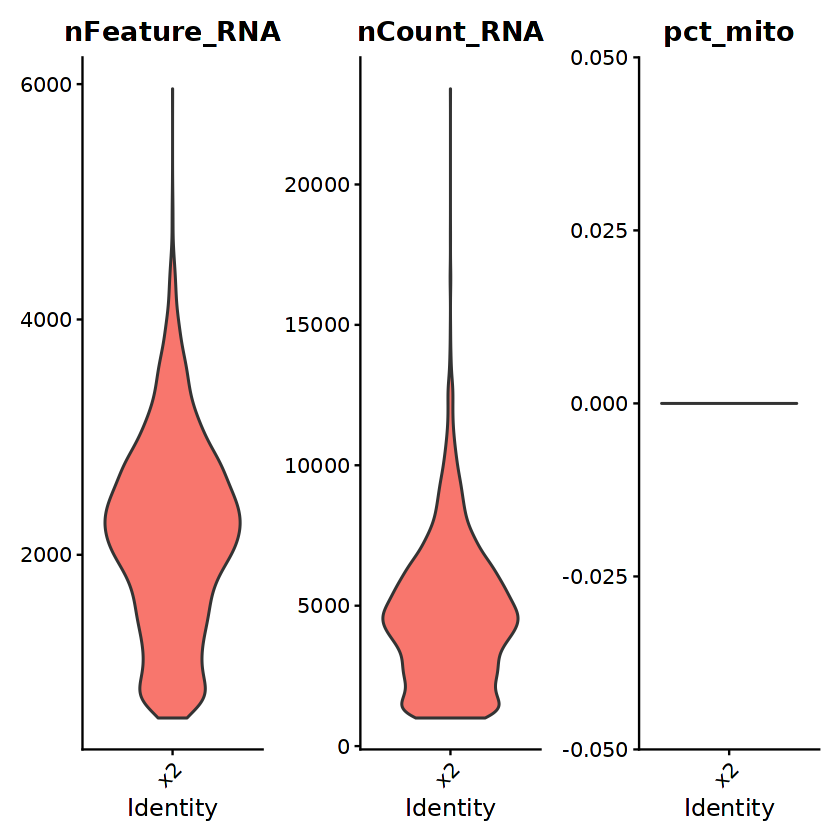

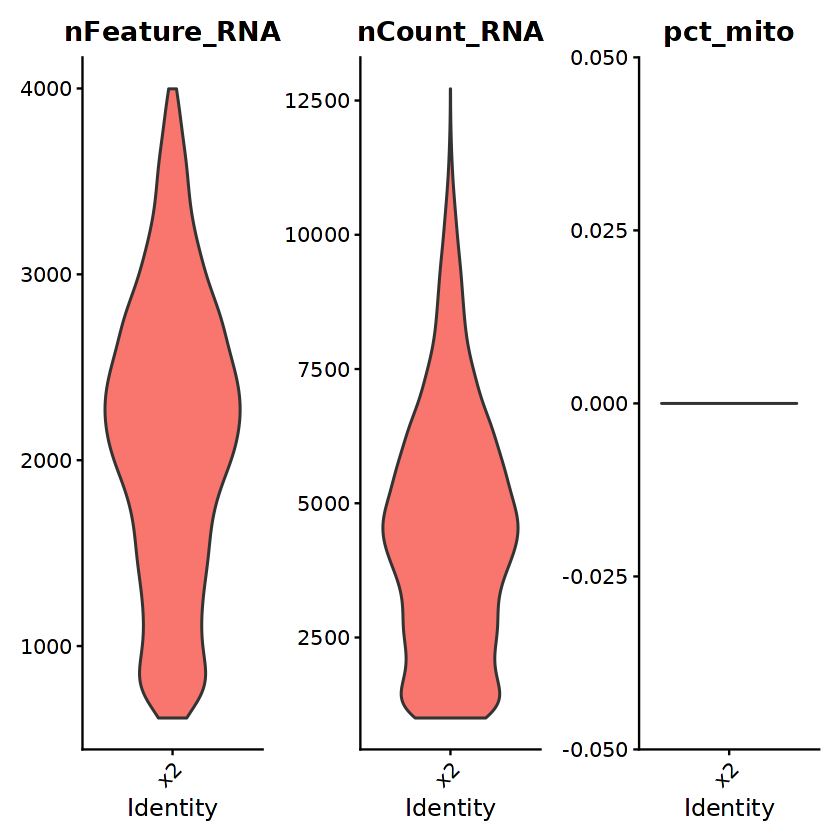

In [34]:
#Load metadata
veres.s3x2.meta <- read.table('rawdata/RNA/Veres/GSM3141958_S3x2.cell_metadata.tsv',header=T,sep='\t')
rownames(veres.s3x2.meta)<- veres.s3x2.meta[,1]
veres.s3x2.meta <- veres.s3x2.meta[,-1]

#Create Seurat object
veres.s3x2 <- CreateSeuratObject(counts=veres.s3x2.raw, project='Veres_s3x2', min.cells = 10, min.features = 500) #meta.data = veres.s3x2.meta, 

#Add metadata
veres.s3x2 = RenameCells(veres.s3x2, add.cell.id = 'veres.s3x2')
veres.s3x2$modality = 'expression'
veres.s3x2$dataset <- 'Veres_s3x2'
veres.s3x2$protocol = 'Veres.x2'
veres.s3x2$stage = 'Stage4_PP1'
veres.s3x2$day = 'Day8'
veres.s3x2$cellsource = 'ESC_HUES8'
veres.s3x2$gender = 'male'

#QC filtering
veres.s3x2[['pct_mito']] = PercentageFeatureSet(veres.s3x2, pattern = '^MT-')
VlnPlot(veres.s3x2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

veres.s3x2 <- subset(veres.s3x2, subset = nFeature_RNA > 500 & nFeature_RNA < 4000 & pct_mito < 20)
VlnPlot(veres.s3x2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(veres.s3x2, file="checkpoints/RNA_datasets/veres_s3x2.rds")
rm(list = c("veres.s3x2.raw","veres.s3x2.meta","veres.s3x2"))

### Stage 4 complete Protocol x1

In [35]:
#Load raw data
veres.s4x1.raw <- as.data.frame(fread('rawdata/RNA/Veres/GSM3141955_S4x1.processed_counts.tsv'))
rownames(veres.s4x1.raw)<- veres.s4x1.raw[,1]
veres.s4x1.raw <- t(veres.s4x1.raw[,-1])
veres.s4x1.raw <- as(veres.s4x1.raw, "sparseMatrix") 

In [36]:
#Homogenization of gene names
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5I"] ="ATP5ME"
rownames(veres.s4x1.raw)[colnames(veres.s4x1.raw) == "ATP5G2"] ="ATP5MC2"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5E"] ="ATP5F1E"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5L"] ="ATP5MG"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "TCEB2"] ="ELOB"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SHFM1"] ="SEM1"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "USMG5"] ="ATP5MD"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "NGFRAP1"] ="BEX3"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM213A"] ="PRXL2A"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "GNB2L1"] ="RACK1"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "TCEB3"] ="ELOA"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C8orf59"] ="RBIS"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C19orf24"] ="FAM174C"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C20orf24"] ="RAB5IF"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM173A"] ="ANTKMT"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C6orf1"] ="SMIM29"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM57B"] ="TLCD3B"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "PVRL2"] ="NECTIN2"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM96A"] ="CIAO2A"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "KIAA1715"] ="LNPK"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "RTFDC1"] ="RTF2"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM134A"] ="RETREG2"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "STRA13"] ="CENPX"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C9orf3"] ="AOPEP"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "HBT8"] ="PWAR6"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "PVRL3"] ="NECTIN3"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "WRB"] ="GET1"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ASNA1"] ="GET3"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM60A"] ="SINHCAF"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM63B"] ="MINDY2"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "COL4A3BP"] ="CERT1"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "WHSC1"] ="NSD2"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "APOPT1"] ="COA8"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "TOMM70A"] ="TOMM70"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "PVRL1"] ="NECTIN1"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "TMEM261"] ="DMAC1"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM195A"] ="MCRIP2"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "PPP2R4"] ="PTPA"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "UQR11.1"] ="UQCR11"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C11orf73"] ="HIKESHI"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C19orf60"] ="REX1BD"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ZCCHC11"] ="TUT4"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "LHFP"] ="LHFPL6"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "MESDC2"] ="MESD"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM127B"] ="RTL8A"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C7orf55"] ="FMC1"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "LINC00493"] ="SMIM26"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "WBSCR22"] ="BUD23"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM105A"] ="OTULINL"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM127A"] ="RTL8C"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C14orf1"] ="ERG28"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "VIMP"] ="SELENOS"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C16orf13"] ="METTL26"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SELM"] ="SELENOM"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM195B"] ="MCRIP1"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "MLLT4"] ="AFDN"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "WBP5"] ="TCEAL9"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SEPT11"] ="SEPTIN11"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C19orf70"] ="MICOS13"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "WHSC1L1"] ="NSD3"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5H"] ="ATP5PD"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "TCEB1"] ="ELOC"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5C1"] ="ATP5F1C"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SEP15"] ="SELENOF"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM96B"] ="CIA02B"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C17orf89"] ="NDUFAF8"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "APOA1BP"] ="NAXE"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5F1"] ="ATP5PB"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM46A"] ="TENT5A"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C14orf166"] ="RTRAF"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SEPT7"] ="SEPTIN7"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "MINOS1"] ="MICOS10"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C11orf31"] ="SELENOH"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "GLTSCR2"] ="NOP53"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "LINC01420"] ="NBDY"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "FAM159B"] ="SHISAL2B"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C7orf73"] ="STMP1"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "C19orf43"] ="TRIR"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SELT"] ="SELENOT"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "AES"] ="TLE5"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5G1"] ="ATP5MC1"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5B"] ="ATP5F1B"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SEPW1"] ="SELENOW"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5D"] ="ATP5F1D"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5O"] ="ATP5PO"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SELK"] ="SELENOK"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "HN1"] ="JPT1"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATPIF1"] ="ATP5IF1"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5J"] ="ATP5PF"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5A1"] ="ATP5F1A"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5G3"] ="ATP5MC3"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "ATP5J2"] ="ATP5MF"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "MYEOV2"] ="COPS9"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "UQCR11.1"] ="UQCR11"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "SEPT4"] ="SEPTIN4"
rownames(veres.s4x1.raw)[rownames(veres.s4x1.raw) == "LARGE1"] ="LARGE"

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


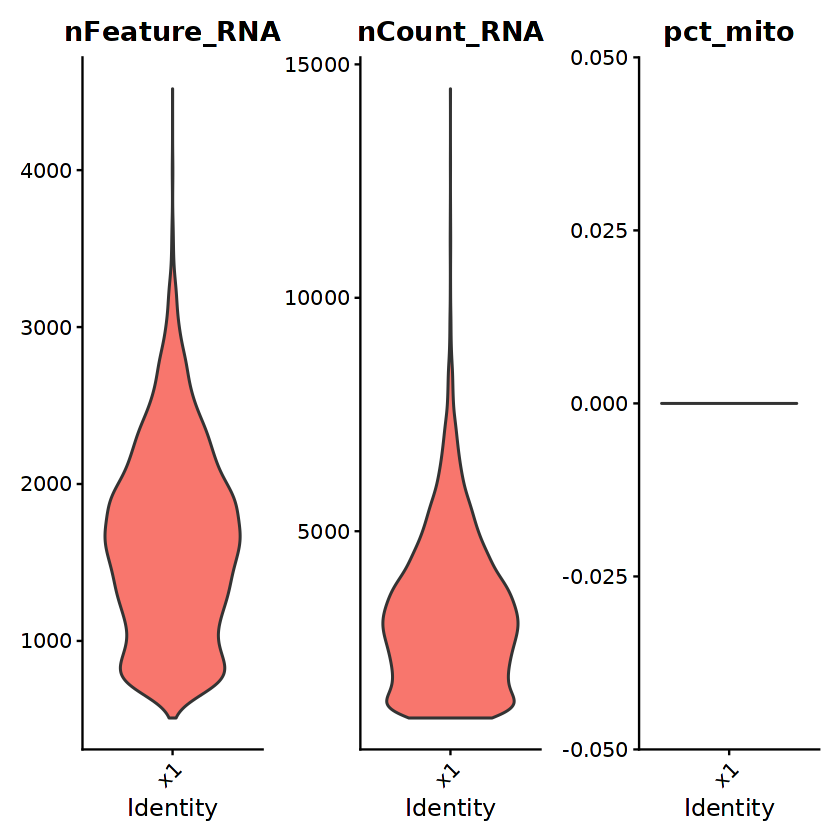

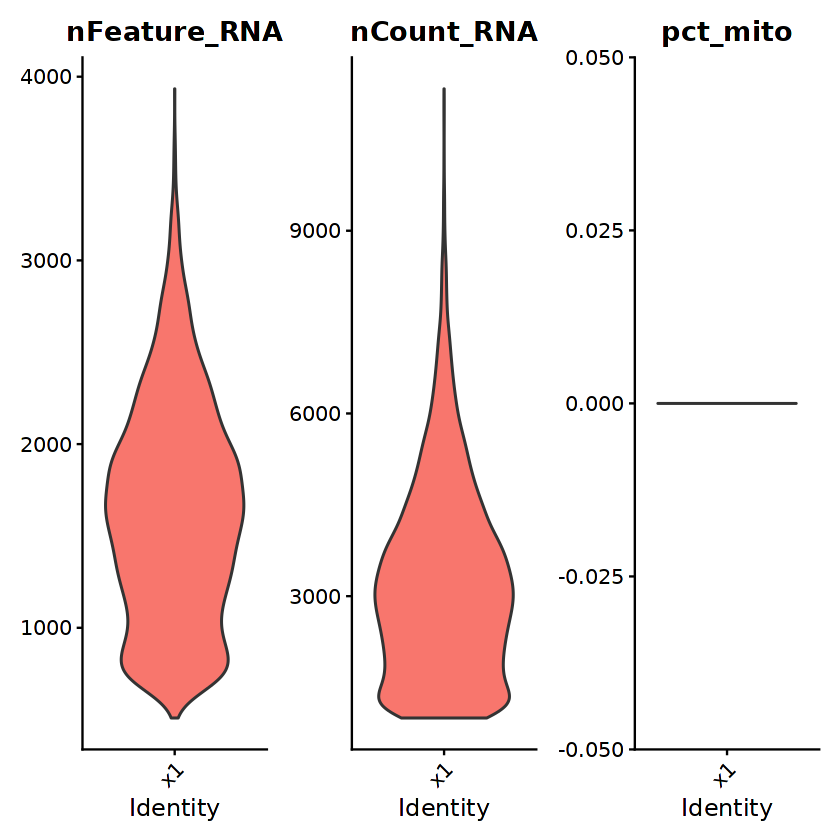

In [37]:
#Load metadata
veres.s4x1.meta <- read.table('rawdata/RNA/Veres/GSM3141955_S4x1.cell_metadata.tsv',header=T,sep='\t')
rownames(veres.s4x1.meta)<- veres.s4x1.meta[,1]
veres.s4x1.meta <- veres.s4x1.meta[,-1]

#Create Seurat object
veres.s4x1 <- CreateSeuratObject(counts=veres.s4x1.raw, project='Veres_s4x1', min.cells = 10, min.features = 500) #meta.data = veres.s4x1.meta, 

#Add metadata
veres.s4x1 = RenameCells(veres.s4x1, add.cell.id = 'veres.s4x1')
veres.s4x1$modality = 'expression'
veres.s4x1$dataset <- 'Veres_s4x1'
veres.s4x1$protocol = 'Veres.x1'
veres.s4x1$stage = 'Stage5_PP2'
veres.s4x1$day = 'Day13'
veres.s4x1$cellsource = 'ESC_HUES8'
veres.s4x1$gender = 'male'

#QC filtering
veres.s4x1[['pct_mito']] = PercentageFeatureSet(veres.s4x1, pattern = '^MT-')
VlnPlot(veres.s4x1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

veres.s4x1 <- subset(veres.s4x1, subset = nFeature_RNA > 500 & nFeature_RNA < 4000 & pct_mito < 20)
VlnPlot(veres.s4x1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(veres.s4x1, file="checkpoints/RNA_datasets/veres_s4x1.rds")
rm(list = c("veres.s4x1.raw","veres.s4x1.meta","veres.s4x1"))

### Stage 4 complete Protocol x2

In [38]:
#Load raw data
veres.s4x2.raw <- as.data.frame(fread('rawdata/RNA/Veres/GSM3141959_S4x2.processed_counts.tsv'))
rownames(veres.s4x2.raw)<- veres.s4x2.raw[,1]
veres.s4x2.raw <- t(veres.s4x2.raw[,-1])
veres.s4x2.raw <- as(veres.s4x2.raw, "sparseMatrix") 

In [39]:
#Homogenization of gene names
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5I"] ="ATP5ME"
rownames(veres.s4x2.raw)[colnames(veres.s4x2.raw) == "ATP5G2"] ="ATP5MC2"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5E"] ="ATP5F1E"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5L"] ="ATP5MG"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "TCEB2"] ="ELOB"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SHFM1"] ="SEM1"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "USMG5"] ="ATP5MD"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "NGFRAP1"] ="BEX3"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM213A"] ="PRXL2A"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "GNB2L1"] ="RACK1"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "TCEB3"] ="ELOA"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C8orf59"] ="RBIS"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C19orf24"] ="FAM174C"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C20orf24"] ="RAB5IF"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM173A"] ="ANTKMT"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C6orf1"] ="SMIM29"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM57B"] ="TLCD3B"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "PVRL2"] ="NECTIN2"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM96A"] ="CIAO2A"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "KIAA1715"] ="LNPK"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "RTFDC1"] ="RTF2"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM134A"] ="RETREG2"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "STRA13"] ="CENPX"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C9orf3"] ="AOPEP"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "HBT8"] ="PWAR6"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "PVRL3"] ="NECTIN3"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "WRB"] ="GET1"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ASNA1"] ="GET3"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM60A"] ="SINHCAF"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM63B"] ="MINDY2"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "COL4A3BP"] ="CERT1"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "WHSC1"] ="NSD2"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "APOPT1"] ="COA8"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "TOMM70A"] ="TOMM70"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "PVRL1"] ="NECTIN1"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "TMEM261"] ="DMAC1"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM195A"] ="MCRIP2"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "PPP2R4"] ="PTPA"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "UQR11.1"] ="UQCR11"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C11orf73"] ="HIKESHI"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C19orf60"] ="REX1BD"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ZCCHC11"] ="TUT4"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "LHFP"] ="LHFPL6"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "MESDC2"] ="MESD"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM127B"] ="RTL8A"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C7orf55"] ="FMC1"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "LINC00493"] ="SMIM26"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "WBSCR22"] ="BUD23"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM105A"] ="OTULINL"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM127A"] ="RTL8C"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C14orf1"] ="ERG28"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "VIMP"] ="SELENOS"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C16orf13"] ="METTL26"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SELM"] ="SELENOM"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM195B"] ="MCRIP1"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "MLLT4"] ="AFDN"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "WBP5"] ="TCEAL9"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SEPT11"] ="SEPTIN11"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C19orf70"] ="MICOS13"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "WHSC1L1"] ="NSD3"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5H"] ="ATP5PD"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "TCEB1"] ="ELOC"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5C1"] ="ATP5F1C"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SEP15"] ="SELENOF"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM96B"] ="CIA02B"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C17orf89"] ="NDUFAF8"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "APOA1BP"] ="NAXE"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5F1"] ="ATP5PB"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM46A"] ="TENT5A"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C14orf166"] ="RTRAF"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SEPT7"] ="SEPTIN7"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "MINOS1"] ="MICOS10"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C11orf31"] ="SELENOH"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "GLTSCR2"] ="NOP53"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "LINC01420"] ="NBDY"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "FAM159B"] ="SHISAL2B"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C7orf73"] ="STMP1"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "C19orf43"] ="TRIR"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SELT"] ="SELENOT"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "AES"] ="TLE5"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5G1"] ="ATP5MC1"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5B"] ="ATP5F1B"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SEPW1"] ="SELENOW"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5D"] ="ATP5F1D"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5O"] ="ATP5PO"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SELK"] ="SELENOK"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "HN1"] ="JPT1"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATPIF1"] ="ATP5IF1"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5J"] ="ATP5PF"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5A1"] ="ATP5F1A"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5G3"] ="ATP5MC3"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "ATP5J2"] ="ATP5MF"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "MYEOV2"] ="COPS9"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "UQCR11.1"] ="UQCR11"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "SEPT4"] ="SEPTIN4"
rownames(veres.s4x2.raw)[rownames(veres.s4x2.raw) == "LARGE1"] ="LARGE"

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


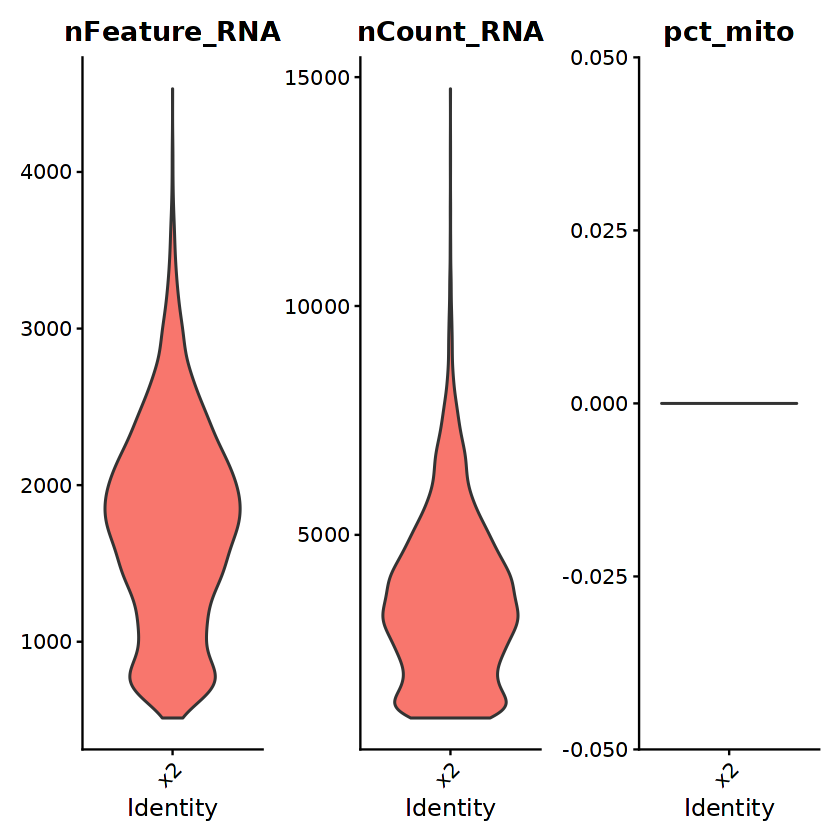

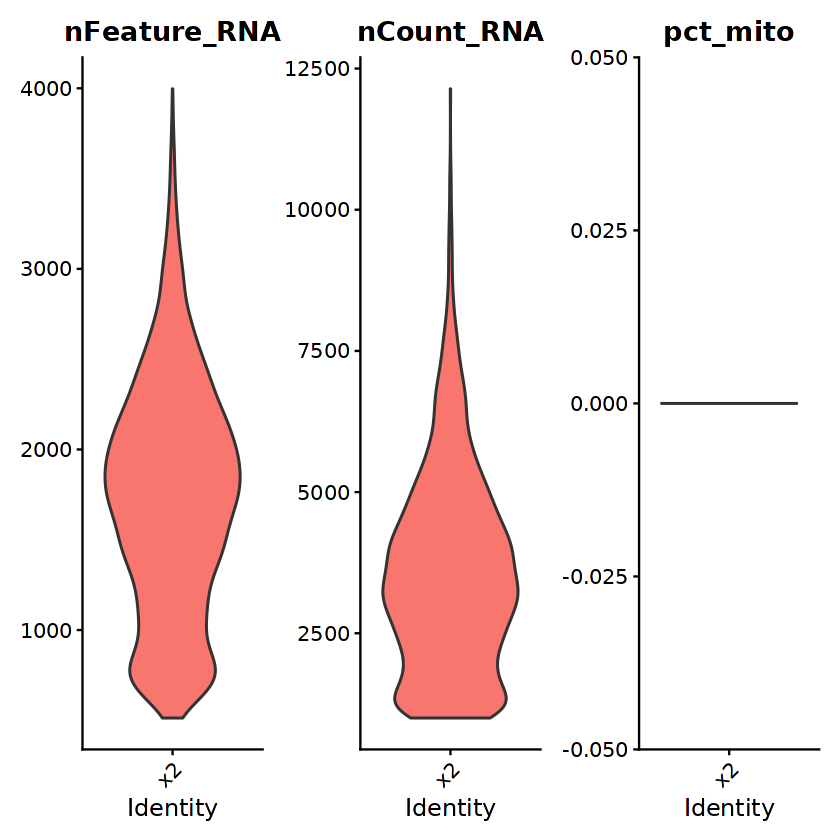

In [40]:
#Load metadata
veres.s4x2.meta <- read.table('rawdata/RNA/Veres/GSM3141959_S4x2.cell_metadata.tsv',header=T,sep='\t')
rownames(veres.s4x2.meta)<- veres.s4x2.meta[,1]
veres.s4x2.meta <- veres.s4x2.meta[,-1]

#Create Seurat object
veres.s4x2 <- CreateSeuratObject(counts=veres.s4x2.raw, project='Veres_s4x2', min.cells = 10, min.features = 500) #meta.data = veres.s4x2.meta, 

#Add metadata
veres.s4x2 = RenameCells(veres.s4x2, add.cell.id = 'veres.s4x2')
veres.s4x2$modality = 'expression'
veres.s4x2$dataset <- 'Veres_s4x2'
veres.s4x2$protocol = 'Veres.x2'
veres.s4x2$stage = 'Stage5_PP2'
veres.s4x2$day = 'Day13'
veres.s4x2$cellsource = 'ESC_HUES8'
veres.s4x2$gender = 'male'

#QC filtering
veres.s4x2[['pct_mito']] = PercentageFeatureSet(veres.s4x2, pattern = '^MT-')
VlnPlot(veres.s4x2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

veres.s4x2 <- subset(veres.s4x2, subset = nFeature_RNA > 500 & nFeature_RNA < 4000 & pct_mito < 20)
VlnPlot(veres.s4x2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(veres.s4x2, file="checkpoints/RNA_datasets/veres_s4x2.rds")
rm(list = c("veres.s4x2.raw","veres.s4x2.meta","veres.s4x2"))

### Stage 5 complete Protocol x1

In [41]:
#load raw data
veres.s5x1.raw <- as.data.frame(fread('rawdata/RNA/Veres/GSM3141956_S5x1.processed_counts.tsv'))
rownames(veres.s5x1.raw)<- veres.s5x1.raw[,1]
veres.s5x1.raw <- t(veres.s5x1.raw[,-1])
veres.s5x1.raw <- as(veres.s5x1.raw, "sparseMatrix") 

In [42]:
#Homogenization of gene names
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5I"] ="ATP5ME"
rownames(veres.s5x1.raw)[colnames(veres.s5x1.raw) == "ATP5G2"] ="ATP5MC2"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5E"] ="ATP5F1E"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5L"] ="ATP5MG"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "TCEB2"] ="ELOB"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SHFM1"] ="SEM1"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "USMG5"] ="ATP5MD"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "NGFRAP1"] ="BEX3"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM213A"] ="PRXL2A"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "GNB2L1"] ="RACK1"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "TCEB3"] ="ELOA"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C8orf59"] ="RBIS"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C19orf24"] ="FAM174C"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C20orf24"] ="RAB5IF"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM173A"] ="ANTKMT"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C6orf1"] ="SMIM29"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM57B"] ="TLCD3B"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "PVRL2"] ="NECTIN2"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM96A"] ="CIAO2A"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "KIAA1715"] ="LNPK"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "RTFDC1"] ="RTF2"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM134A"] ="RETREG2"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "STRA13"] ="CENPX"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C9orf3"] ="AOPEP"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "HBT8"] ="PWAR6"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "PVRL3"] ="NECTIN3"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "WRB"] ="GET1"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ASNA1"] ="GET3"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM60A"] ="SINHCAF"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM63B"] ="MINDY2"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "COL4A3BP"] ="CERT1"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "WHSC1"] ="NSD2"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "APOPT1"] ="COA8"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "TOMM70A"] ="TOMM70"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "PVRL1"] ="NECTIN1"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "TMEM261"] ="DMAC1"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM195A"] ="MCRIP2"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "PPP2R4"] ="PTPA"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "UQR11.1"] ="UQCR11"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C11orf73"] ="HIKESHI"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C19orf60"] ="REX1BD"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ZCCHC11"] ="TUT4"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "LHFP"] ="LHFPL6"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "MESDC2"] ="MESD"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM127B"] ="RTL8A"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C7orf55"] ="FMC1"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "LINC00493"] ="SMIM26"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "WBSCR22"] ="BUD23"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM105A"] ="OTULINL"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM127A"] ="RTL8C"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C14orf1"] ="ERG28"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "VIMP"] ="SELENOS"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C16orf13"] ="METTL26"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SELM"] ="SELENOM"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM195B"] ="MCRIP1"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "MLLT4"] ="AFDN"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "WBP5"] ="TCEAL9"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SEPT11"] ="SEPTIN11"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C19orf70"] ="MICOS13"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "WHSC1L1"] ="NSD3"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5H"] ="ATP5PD"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "TCEB1"] ="ELOC"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5C1"] ="ATP5F1C"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SEP15"] ="SELENOF"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM96B"] ="CIA02B"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C17orf89"] ="NDUFAF8"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "APOA1BP"] ="NAXE"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5F1"] ="ATP5PB"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM46A"] ="TENT5A"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C14orf166"] ="RTRAF"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SEPT7"] ="SEPTIN7"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "MINOS1"] ="MICOS10"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C11orf31"] ="SELENOH"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "GLTSCR2"] ="NOP53"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "LINC01420"] ="NBDY"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "FAM159B"] ="SHISAL2B"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C7orf73"] ="STMP1"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "C19orf43"] ="TRIR"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SELT"] ="SELENOT"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "AES"] ="TLE5"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5G1"] ="ATP5MC1"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5B"] ="ATP5F1B"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SEPW1"] ="SELENOW"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5D"] ="ATP5F1D"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5O"] ="ATP5PO"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SELK"] ="SELENOK"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "HN1"] ="JPT1"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATPIF1"] ="ATP5IF1"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5J"] ="ATP5PF"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5A1"] ="ATP5F1A"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5G3"] ="ATP5MC3"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "ATP5J2"] ="ATP5MF"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "MYEOV2"] ="COPS9"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "UQCR11.1"] ="UQCR11"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "SEPT4"] ="SEPTIN4"
rownames(veres.s5x1.raw)[rownames(veres.s5x1.raw) == "LARGE1"] ="LARGE"

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


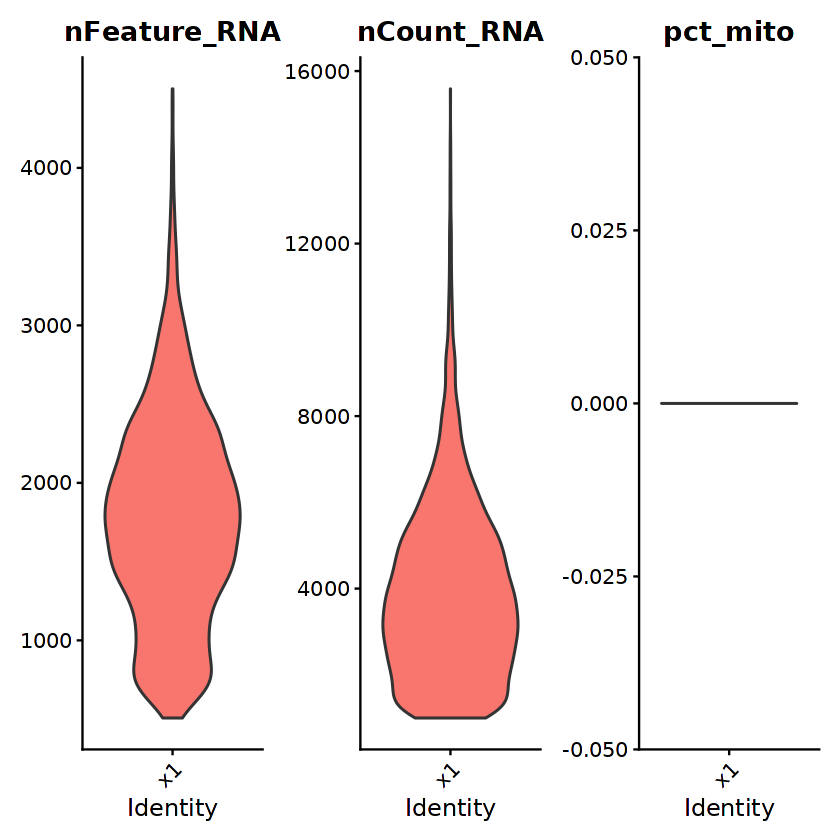

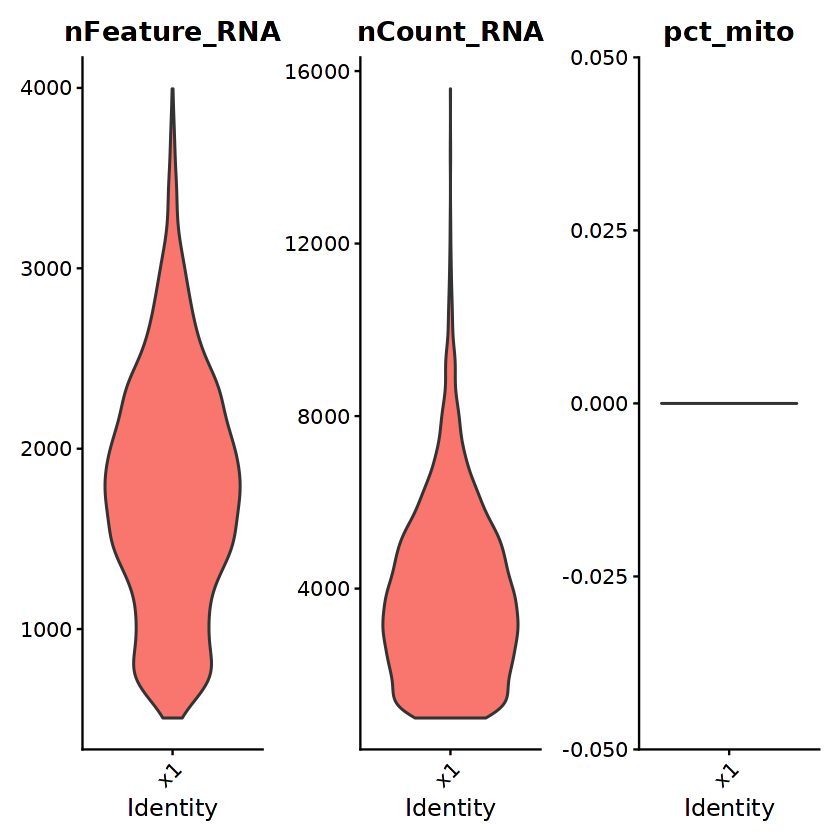

In [43]:
#load metadata
veres.s5x1.meta <- read.table('rawdata/RNA/Veres/GSM3141956_S5x1.cell_metadata.tsv',header=T,sep='\t')
rownames(veres.s5x1.meta)<- veres.s5x1.meta[,1]
veres.s5x1.meta <- veres.s5x1.meta[,-1]

#create seurat object
veres.s5x1 <- CreateSeuratObject(counts=veres.s5x1.raw, project='Veres_s5x1', min.cells = 10, min.features = 500) #meta.data = veres.s5x1.meta, 

#Add metadata
veres.s5x1 = RenameCells(veres.s5x1, add.cell.id = 'veres.s5x1')
veres.s5x1$modality = 'expression'
veres.s5x1$dataset <- 'Veres_s5x1'
veres.s5x1$protocol = 'Veres.x1'
veres.s5x1$stage = 'Stage6_EP'
veres.s5x1$day = 'Day18'
veres.s5x1$cellsource = 'ESC_HUES8'
veres.s5x1$gender = 'male'

#QC filtering
veres.s5x1[['pct_mito']] = PercentageFeatureSet(veres.s5x1, pattern = '^MT-')
VlnPlot(veres.s5x1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

veres.s5x1 <- subset(veres.s5x1, subset = nFeature_RNA > 500 & nFeature_RNA < 4000 & pct_mito < 20)
VlnPlot(veres.s5x1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(veres.s5x1, file="checkpoints/RNA_datasets/veres_s5x1.rds")
rm(list = c("veres.s5x1.raw","veres.s5x1.meta","veres.s5x1"))

### Stage 5 complete Protocol x2

In [44]:
#load raw data
veres.s5x2.raw <- as.data.frame(fread('rawdata/RNA/Veres/GSM3141960_S5x2.processed_counts.tsv'))
rownames(veres.s5x2.raw)<- veres.s5x2.raw[,1]
veres.s5x2.raw <- t(veres.s5x2.raw[,-1])
veres.s5x2.raw <- as(veres.s5x2.raw, "sparseMatrix") 

In [45]:
#Homogenization of gene names
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5I"] ="ATP5ME"
rownames(veres.s5x2.raw)[colnames(veres.s5x2.raw) == "ATP5G2"] ="ATP5MC2"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5E"] ="ATP5F1E"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5L"] ="ATP5MG"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "TCEB2"] ="ELOB"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SHFM1"] ="SEM1"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "USMG5"] ="ATP5MD"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "NGFRAP1"] ="BEX3"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM213A"] ="PRXL2A"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "GNB2L1"] ="RACK1"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "TCEB3"] ="ELOA"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C8orf59"] ="RBIS"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C19orf24"] ="FAM174C"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C20orf24"] ="RAB5IF"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM173A"] ="ANTKMT"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C6orf1"] ="SMIM29"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM57B"] ="TLCD3B"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "PVRL2"] ="NECTIN2"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM96A"] ="CIAO2A"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "KIAA1715"] ="LNPK"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "RTFDC1"] ="RTF2"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM134A"] ="RETREG2"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "STRA13"] ="CENPX"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C9orf3"] ="AOPEP"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "HBT8"] ="PWAR6"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "PVRL3"] ="NECTIN3"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "WRB"] ="GET1"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ASNA1"] ="GET3"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM60A"] ="SINHCAF"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM63B"] ="MINDY2"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "COL4A3BP"] ="CERT1"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "WHSC1"] ="NSD2"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "APOPT1"] ="COA8"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "TOMM70A"] ="TOMM70"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "PVRL1"] ="NECTIN1"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "TMEM261"] ="DMAC1"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM195A"] ="MCRIP2"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "PPP2R4"] ="PTPA"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "UQR11.1"] ="UQCR11"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C11orf73"] ="HIKESHI"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C19orf60"] ="REX1BD"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ZCCHC11"] ="TUT4"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "LHFP"] ="LHFPL6"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "MESDC2"] ="MESD"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM127B"] ="RTL8A"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C7orf55"] ="FMC1"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "LINC00493"] ="SMIM26"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "WBSCR22"] ="BUD23"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM105A"] ="OTULINL"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM127A"] ="RTL8C"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C14orf1"] ="ERG28"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "VIMP"] ="SELENOS"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C16orf13"] ="METTL26"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SELM"] ="SELENOM"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM195B"] ="MCRIP1"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "MLLT4"] ="AFDN"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "WBP5"] ="TCEAL9"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SEPT11"] ="SEPTIN11"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C19orf70"] ="MICOS13"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "WHSC1L1"] ="NSD3"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5H"] ="ATP5PD"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "TCEB1"] ="ELOC"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5C1"] ="ATP5F1C"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SEP15"] ="SELENOF"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM96B"] ="CIA02B"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C17orf89"] ="NDUFAF8"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "APOA1BP"] ="NAXE"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5F1"] ="ATP5PB"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM46A"] ="TENT5A"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C14orf166"] ="RTRAF"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SEPT7"] ="SEPTIN7"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "MINOS1"] ="MICOS10"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C11orf31"] ="SELENOH"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "GLTSCR2"] ="NOP53"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "LINC01420"] ="NBDY"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "FAM159B"] ="SHISAL2B"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C7orf73"] ="STMP1"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "C19orf43"] ="TRIR"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SELT"] ="SELENOT"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "AES"] ="TLE5"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5G1"] ="ATP5MC1"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5B"] ="ATP5F1B"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SEPW1"] ="SELENOW"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5D"] ="ATP5F1D"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5O"] ="ATP5PO"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SELK"] ="SELENOK"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "HN1"] ="JPT1"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATPIF1"] ="ATP5IF1"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5J"] ="ATP5PF"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5A1"] ="ATP5F1A"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5G3"] ="ATP5MC3"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "ATP5J2"] ="ATP5MF"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "MYEOV2"] ="COPS9"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "UQCR11.1"] ="UQCR11"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "SEPT4"] ="SEPTIN4"
rownames(veres.s5x2.raw)[rownames(veres.s5x2.raw) == "LARGE1"] ="LARGE"

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


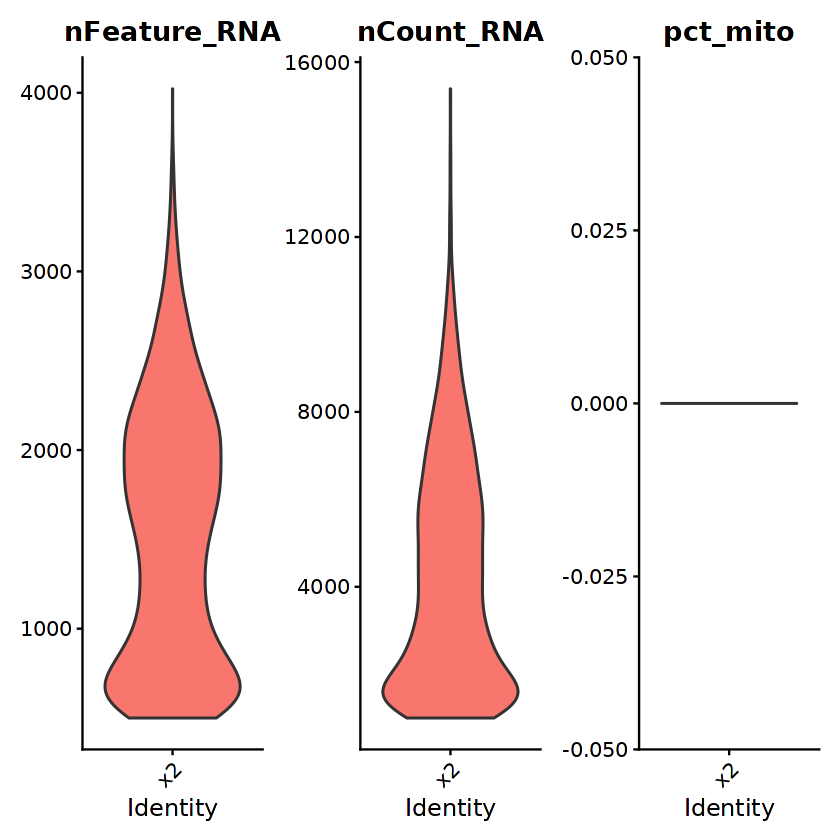

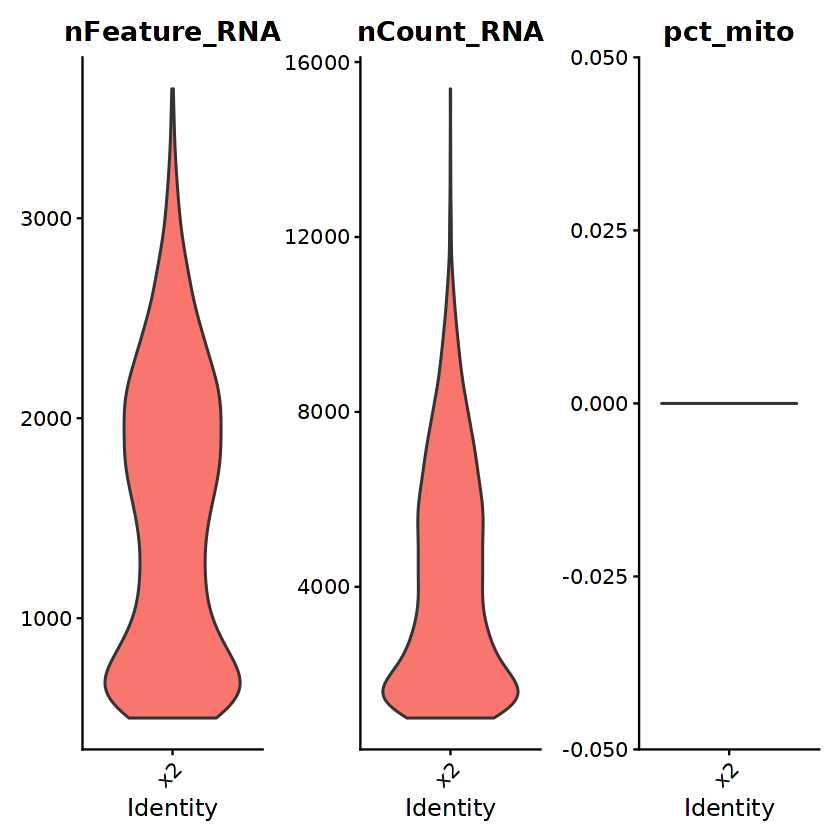

In [46]:


#load metadata
veres.s5x2.meta <- read.table('rawdata/RNA/Veres/GSM3141960_S5x2.cell_metadata.tsv',header=T,sep='\t')
rownames(veres.s5x2.meta)<- veres.s5x2.meta[,1]
veres.s5x2.meta <- veres.s5x2.meta[,-1]

#create seurat object
veres.s5x2 <- CreateSeuratObject(counts=veres.s5x2.raw, project='Veres_s5x2', min.cells = 10, min.features = 500) #meta.data = veres.s5x2.meta, 

#Add metadata
veres.s5x2 = RenameCells(veres.s5x2, add.cell.id = 'veres.s5x2')
veres.s5x2$modality = 'expression'
veres.s5x2$dataset <- 'Veres_s5x2'
veres.s5x2$protocol = 'Veres.x2'
veres.s5x2$stage = 'Stage6_EP'
veres.s5x2$day = 'Day18'
veres.s5x2$cellsource = 'ESC_HUES8'
veres.s5x2$gender = 'male'

#QC filtering
veres.s5x2[['pct_mito']] = PercentageFeatureSet(veres.s5x2, pattern = '^MT-')
VlnPlot(veres.s5x2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

veres.s5x2 <- subset(veres.s5x2, subset = nFeature_RNA > 500 & nFeature_RNA < 4000 & pct_mito < 20)
VlnPlot(veres.s5x2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(veres.s5x2, file='checkpoints/RNA_datasets/veres_s5x2.rds')
rm(list = c('veres.s5x2.raw','veres.s5x2.meta','veres.s5x2'))

### Stage 6 complete Protocol x1

In [47]:
#load raw data
veres.s6x1.raw <- as.data.frame(fread('rawdata/RNA/Veres/GSM3141957_S6x1.processed_counts.tsv'))
rownames(veres.s6x1.raw)<- veres.s6x1.raw[,1]
veres.s6x1.raw <- t(veres.s6x1.raw[,-1])
veres.s6x1.raw <- as(veres.s6x1.raw, "sparseMatrix")

In [48]:
#Homogenization of gene names
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5I"] ="ATP5ME"
rownames(veres.s6x1.raw)[colnames(veres.s6x1.raw) == "ATP5G2"] ="ATP5MC2"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5E"] ="ATP5F1E"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5L"] ="ATP5MG"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "TCEB2"] ="ELOB"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SHFM1"] ="SEM1"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "USMG5"] ="ATP5MD"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "NGFRAP1"] ="BEX3"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM213A"] ="PRXL2A"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "GNB2L1"] ="RACK1"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "TCEB3"] ="ELOA"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C8orf59"] ="RBIS"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C19orf24"] ="FAM174C"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C20orf24"] ="RAB5IF"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM173A"] ="ANTKMT"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C6orf1"] ="SMIM29"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM57B"] ="TLCD3B"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "PVRL2"] ="NECTIN2"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM96A"] ="CIAO2A"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "KIAA1715"] ="LNPK"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "RTFDC1"] ="RTF2"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM134A"] ="RETREG2"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "STRA13"] ="CENPX"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C9orf3"] ="AOPEP"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "HBT8"] ="PWAR6"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "PVRL3"] ="NECTIN3"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "WRB"] ="GET1"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ASNA1"] ="GET3"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM60A"] ="SINHCAF"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM63B"] ="MINDY2"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "COL4A3BP"] ="CERT1"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "WHSC1"] ="NSD2"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "APOPT1"] ="COA8"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "TOMM70A"] ="TOMM70"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "PVRL1"] ="NECTIN1"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "TMEM261"] ="DMAC1"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM195A"] ="MCRIP2"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "PPP2R4"] ="PTPA"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "UQR11.1"] ="UQCR11"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C11orf73"] ="HIKESHI"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C19orf60"] ="REX1BD"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ZCCHC11"] ="TUT4"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "LHFP"] ="LHFPL6"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "MESDC2"] ="MESD"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM127B"] ="RTL8A"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C7orf55"] ="FMC1"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "LINC00493"] ="SMIM26"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "WBSCR22"] ="BUD23"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM105A"] ="OTULINL"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM127A"] ="RTL8C"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C14orf1"] ="ERG28"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "VIMP"] ="SELENOS"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C16orf13"] ="METTL26"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SELM"] ="SELENOM"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM195B"] ="MCRIP1"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "MLLT4"] ="AFDN"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "WBP5"] ="TCEAL9"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SEPT11"] ="SEPTIN11"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C19orf70"] ="MICOS13"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "WHSC1L1"] ="NSD3"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5H"] ="ATP5PD"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "TCEB1"] ="ELOC"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5C1"] ="ATP5F1C"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SEP15"] ="SELENOF"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM96B"] ="CIA02B"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C17orf89"] ="NDUFAF8"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "APOA1BP"] ="NAXE"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5F1"] ="ATP5PB"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM46A"] ="TENT5A"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C14orf166"] ="RTRAF"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SEPT7"] ="SEPTIN7"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "MINOS1"] ="MICOS10"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C11orf31"] ="SELENOH"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "GLTSCR2"] ="NOP53"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "LINC01420"] ="NBDY"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "FAM159B"] ="SHISAL2B"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C7orf73"] ="STMP1"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "C19orf43"] ="TRIR"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SELT"] ="SELENOT"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "AES"] ="TLE5"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5G1"] ="ATP5MC1"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5B"] ="ATP5F1B"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SEPW1"] ="SELENOW"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5D"] ="ATP5F1D"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5O"] ="ATP5PO"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SELK"] ="SELENOK"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "HN1"] ="JPT1"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATPIF1"] ="ATP5IF1"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5J"] ="ATP5PF"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5A1"] ="ATP5F1A"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5G3"] ="ATP5MC3"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "ATP5J2"] ="ATP5MF"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "MYEOV2"] ="COPS9"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "UQCR11.1"] ="UQCR11"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "SEPT4"] ="SEPTIN4"
rownames(veres.s6x1.raw)[rownames(veres.s6x1.raw) == "LARGE1"] ="LARGE"

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


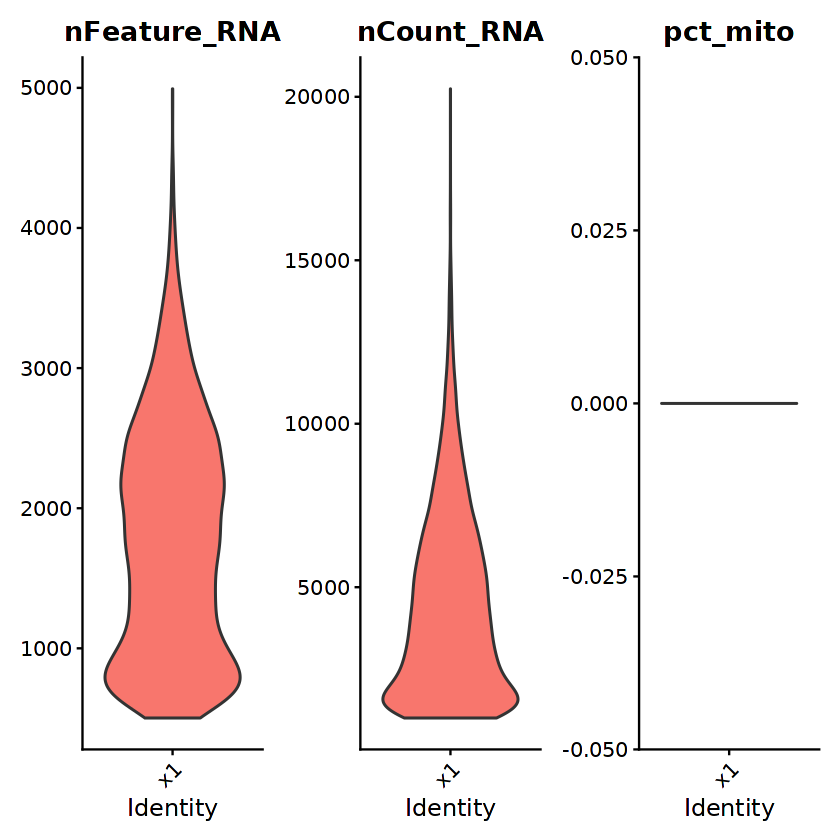

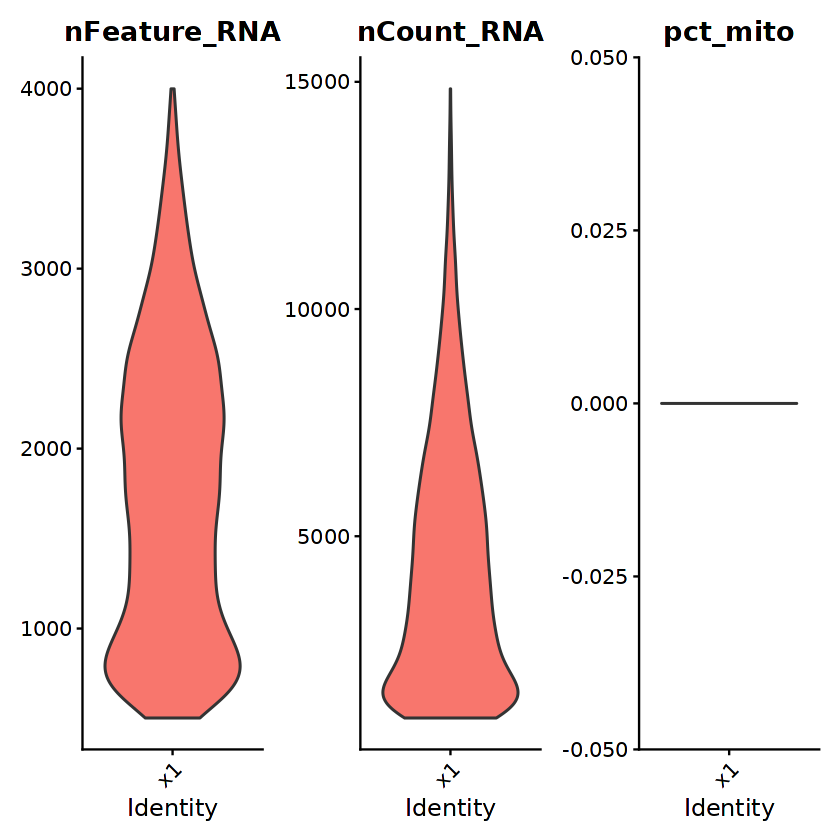

In [49]:
#load metadata
veres.s6x1.meta <- read.table('rawdata/RNA/Veres/GSM3141957_S6x1.cell_metadata.tsv',header=T,sep='\t')
rownames(veres.s6x1.meta)<- veres.s6x1.meta[,1]
veres.s6x1.meta <- veres.s6x1.meta[,-1]

#create seurat object
veres.s6x1 <- CreateSeuratObject(counts=veres.s6x1.raw, project="Veres_s6x1", min.cells = 10, min.features = 500) #meta.data = veres.s6x1.meta, 

#Add metadata
veres.s6x1 = RenameCells(veres.s6x1, add.cell.id = 'veres.s6x1')
veres.s6x1$modality = 'expression'
veres.s6x1$dataset <- 'Veres_s6x1'
veres.s6x1$protocol = 'Veres.x1'
veres.s6x1$stage = 'Stage7_SCi'
veres.s6x1$day = 'Day25'
veres.s6x1$cellsource = 'ESC_HUES8'
veres.s6x1$gender = 'male'

#QC filtering
veres.s6x1[['pct_mito']] = PercentageFeatureSet(veres.s6x1, pattern = '^MT-')
VlnPlot(veres.s6x1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

veres.s6x1 <- subset(veres.s6x1, subset = nFeature_RNA > 500 & nFeature_RNA < 4000 & pct_mito < 20)
VlnPlot(veres.s6x1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(veres.s6x1, file='checkpoints/RNA_datasets/veres_s6x1.rds')
rm(list = c("veres.s6x1.raw","veres.s6x1.meta","veres.s6x1"))

### Stage 6 complete Protocol x2

In [50]:
#Load raw data
veres.s6x2.raw <- as.data.frame(fread('rawdata/RNA/Veres/GSM3141961_S6x2.processed_counts.tsv'))
rownames(veres.s6x2.raw)<- veres.s6x2.raw[,1]
veres.s6x2.raw <- t(veres.s6x2.raw[,-1])
veres.s6x2.raw <- as(veres.s6x2.raw, "sparseMatrix")

In [51]:
#Homogenization of gene names
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5I"] ="ATP5ME"
rownames(veres.s6x2.raw)[colnames(veres.s6x2.raw) == "ATP5G2"] ="ATP5MC2"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5E"] ="ATP5F1E"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5L"] ="ATP5MG"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "TCEB2"] ="ELOB"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SHFM1"] ="SEM1"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "USMG5"] ="ATP5MD"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "NGFRAP1"] ="BEX3"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM213A"] ="PRXL2A"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "GNB2L1"] ="RACK1"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "TCEB3"] ="ELOA"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C8orf59"] ="RBIS"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C19orf24"] ="FAM174C"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C20orf24"] ="RAB5IF"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM173A"] ="ANTKMT"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C6orf1"] ="SMIM29"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM57B"] ="TLCD3B"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "PVRL2"] ="NECTIN2"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM96A"] ="CIAO2A"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "KIAA1715"] ="LNPK"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "RTFDC1"] ="RTF2"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM134A"] ="RETREG2"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "STRA13"] ="CENPX"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C9orf3"] ="AOPEP"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "HBT8"] ="PWAR6"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "PVRL3"] ="NECTIN3"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "WRB"] ="GET1"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ASNA1"] ="GET3"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM60A"] ="SINHCAF"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM63B"] ="MINDY2"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "COL4A3BP"] ="CERT1"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "WHSC1"] ="NSD2"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "APOPT1"] ="COA8"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "TOMM70A"] ="TOMM70"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "PVRL1"] ="NECTIN1"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "TMEM261"] ="DMAC1"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM195A"] ="MCRIP2"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "PPP2R4"] ="PTPA"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "UQR11.1"] ="UQCR11"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C11orf73"] ="HIKESHI"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C19orf60"] ="REX1BD"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ZCCHC11"] ="TUT4"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "LHFP"] ="LHFPL6"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "MESDC2"] ="MESD"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM127B"] ="RTL8A"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C7orf55"] ="FMC1"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "LINC00493"] ="SMIM26"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "WBSCR22"] ="BUD23"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM105A"] ="OTULINL"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM127A"] ="RTL8C"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C14orf1"] ="ERG28"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SEPT2"] ="SEPTIN2"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "VIMP"] ="SELENOS"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C16orf13"] ="METTL26"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SELM"] ="SELENOM"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM195B"] ="MCRIP1"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "MLLT4"] ="AFDN"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "WBP5"] ="TCEAL9"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SEPT11"] ="SEPTIN11"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C19orf70"] ="MICOS13"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "WHSC1L1"] ="NSD3"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5H"] ="ATP5PD"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "TCEB1"] ="ELOC"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5C1"] ="ATP5F1C"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SEP15"] ="SELENOF"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM96B"] ="CIA02B"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C17orf89"] ="NDUFAF8"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "APOA1BP"] ="NAXE"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5F1"] ="ATP5PB"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM46A"] ="TENT5A"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C14orf166"] ="RTRAF"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SEPT7"] ="SEPTIN7"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "MINOS1"] ="MICOS10"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C11orf31"] ="SELENOH"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "GLTSCR2"] ="NOP53"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "LINC01420"] ="NBDY"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "FAM159B"] ="SHISAL2B"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C7orf73"] ="STMP1"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "C19orf43"] ="TRIR"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SELT"] ="SELENOT"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "AES"] ="TLE5"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5G1"] ="ATP5MC1"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5B"] ="ATP5F1B"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SEPW1"] ="SELENOW"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5D"] ="ATP5F1D"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5O"] ="ATP5PO"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SELK"] ="SELENOK"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "HN1"] ="JPT1"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATPIF1"] ="ATP5IF1"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5J"] ="ATP5PF"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5A1"] ="ATP5F1A"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5G3"] ="ATP5MC3"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "ATP5J2"] ="ATP5MF"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "MYEOV2"] ="COPS9"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "UQCR11.1"] ="UQCR11"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SUMO2.1"] ="SUMO2"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "SEPT4"] ="SEPTIN4"
rownames(veres.s6x2.raw)[rownames(veres.s6x2.raw) == "LARGE1"] ="LARGE"

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of pct_mito.”


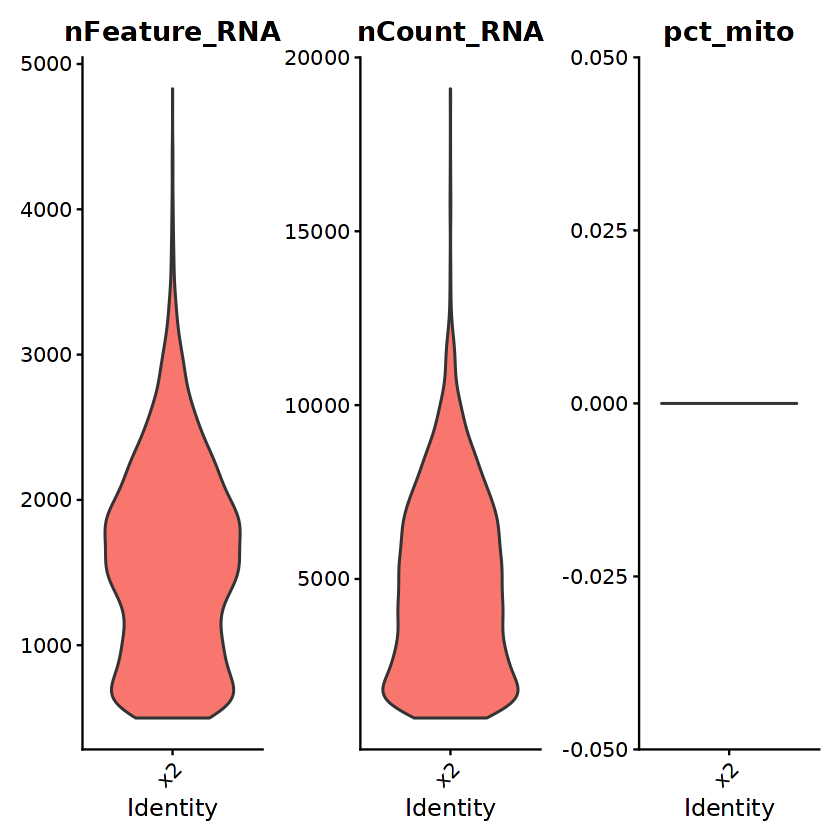

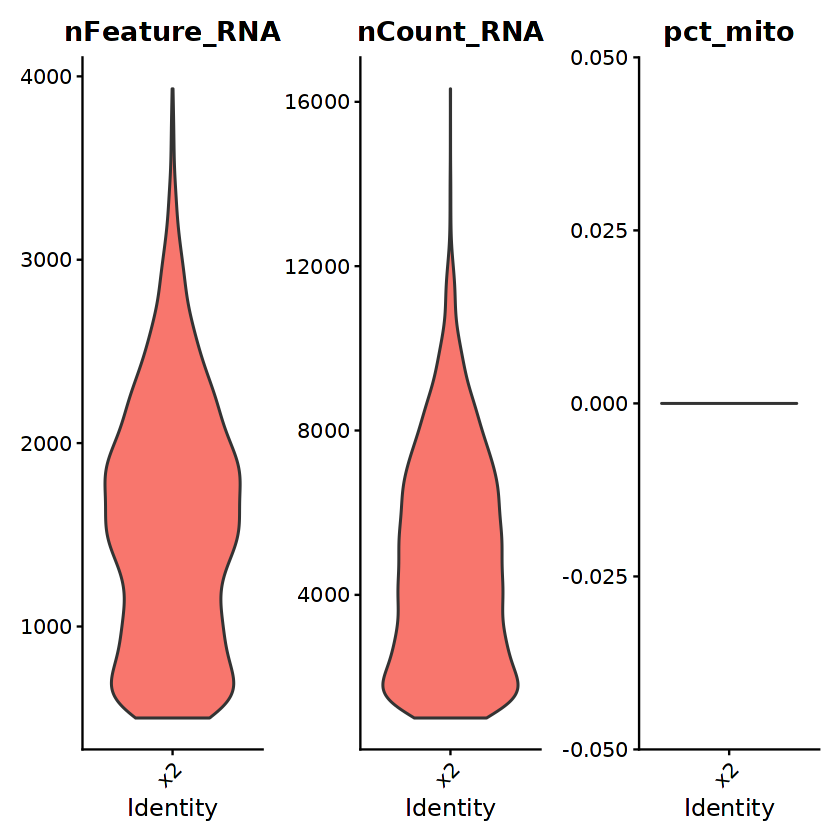

In [52]:
#Load metadata
veres.s6x2.meta <- read.table('rawdata/RNA/Veres/GSM3141961_S6x2.cell_metadata.tsv',header=T,sep='\t')
rownames(veres.s6x2.meta)<- veres.s6x2.meta[,1]
veres.s6x2.meta <- veres.s6x2.meta[,-1]

#Create Seurat object
veres.s6x2 <- CreateSeuratObject(counts=veres.s6x2.raw, project="Veres_s6x2", min.cells = 10, min.features = 500) #meta.data = veres.s6x2.meta, 

#Add metadata
veres.s6x2 = RenameCells(veres.s6x2, add.cell.id = 'veres.s6x2')
veres.s6x2$modality = 'expression'
veres.s6x2$dataset <- 'Veres_s6x2'
veres.s6x2$protocol = 'Veres.x2'
veres.s6x2$stage = 'Stage7_SCi'
veres.s6x2$day = 'Day25'
veres.s6x2$cellsource = 'ESC_HUES8'
veres.s6x2$gender = 'male'

#QC filtering
veres.s6x2[['pct_mito']] = PercentageFeatureSet(veres.s6x2, pattern = '^MT-')
VlnPlot(veres.s6x2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

veres.s6x2 <- subset(veres.s6x2, subset = nFeature_RNA > 500 & nFeature_RNA < 4000 & pct_mito < 20)
VlnPlot(veres.s6x2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(veres.s6x2, file='checkpoints/RNA_datasets/veres_s6x2.rds')
rm(list = c("veres.s6x2.raw","veres.s6x2.meta","veres.s6x2"))

## Punn et al Cell Reports 2020

### Stage 6 Day 13 - HUES8

In [6]:
#Load RNA data
punn.esc.raw <- Read10X(data.dir = 'rawdata/RNA/Punn2020_S6D13/outs/filtered_feature_bc_matrix/')

In [7]:
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5I"] ="ATP5ME"
rownames(punn.esc.raw)[colnames(punn.esc.raw) == "ATP5G2"] ="ATP5MC2"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5E"] ="ATP5F1E"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5L"] ="ATP5MG"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "TCEB2"] ="ELOB"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "SHFM1"] ="SEM1"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "USMG5"] ="ATP5MD"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "NGFRAP1"] ="BEX3"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM213A"] ="PRXL2A"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "GNB2L1"] ="RACK1"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "TCEB3"] ="ELOA"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C8orf59"] ="RBIS"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C19orf24"] ="FAM174C"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C20orf24"] ="RAB5IF"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM173A"] ="ANTKMT"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C6orf1"] ="SMIM29"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "SEPT2"] ="SEPTIN2"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM57B"] ="TLCD3B"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "PVRL2"] ="NECTIN2"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM96A"] ="CIAO2A"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "KIAA1715"] ="LNPK"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "RTFDC1"] ="RTF2"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM134A"] ="RETREG2"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "STRA13"] ="CENPX"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C9orf3"] ="AOPEP"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "HBT8"] ="PWAR6"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "PVRL3"] ="NECTIN3"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "WRB"] ="GET1"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ASNA1"] ="GET3"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM60A"] ="SINHCAF"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM63B"] ="MINDY2"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "COL4A3BP"] ="CERT1"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "WHSC1"] ="NSD2"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "APOPT1"] ="COA8"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "TOMM70A"] ="TOMM70"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "PVRL1"] ="NECTIN1"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "TMEM261"] ="DMAC1"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM195A"] ="MCRIP2"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "PPP2R4"] ="PTPA"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "SUMO2.1"] ="SUMO2"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "UQR11.1"] ="UQCR11"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C11orf73"] ="HIKESHI"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C19orf60"] ="REX1BD"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ZCCHC11"] ="TUT4"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "LHFP"] ="LHFPL6"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "MESDC2"] ="MESD"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM127B"] ="RTL8A"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C7orf55"] ="FMC1"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "LINC00493"] ="SMIM26"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "WBSCR22"] ="BUD23"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM105A"] ="OTULINL"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM127A"] ="RTL8C"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C14orf1"] ="ERG28"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "SEPT2"] ="SEPTIN2"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "VIMP"] ="SELENOS"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C16orf13"] ="METTL26"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "SELM"] ="SELENOM"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM195B"] ="MCRIP1"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "MLLT4"] ="AFDN"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "WBP5"] ="TCEAL9"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "SEPT11"] ="SEPTIN11"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C19orf70"] ="MICOS13"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "WHSC1L1"] ="NSD3"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5H"] ="ATP5PD"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "TCEB1"] ="ELOC"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5C1"] ="ATP5F1C"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "SEP15"] ="SELENOF"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM96B"] ="CIA02B"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C17orf89"] ="NDUFAF8"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "APOA1BP"] ="NAXE"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5F1"] ="ATP5PB"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM46A"] ="TENT5A"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C14orf166"] ="RTRAF"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "SEPT7"] ="SEPTIN7"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "MINOS1"] ="MICOS10"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C11orf31"] ="SELENOH"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "GLTSCR2"] ="NOP53"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "LINC01420"] ="NBDY"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "FAM159B"] ="SHISAL2B"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C7orf73"] ="STMP1"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "C19orf43"] ="TRIR"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "SELT"] ="SELENOT"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "AES"] ="TLE5"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5G1"] ="ATP5MC1"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5B"] ="ATP5F1B"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "SEPW1"] ="SELENOW"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5D"] ="ATP5F1D"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5O"] ="ATP5PO"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "SELK"] ="SELENOK"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "HN1"] ="JPT1"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATPIF1"] ="ATP5IF1"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5J"] ="ATP5PF"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5A1"] ="ATP5F1A"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5G3"] ="ATP5MC3"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "ATP5J2"] ="ATP5MF"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "MYEOV2"] ="COPS9"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "SEPT4"] ="SEPTIN4"
rownames(punn.esc.raw)[rownames(punn.esc.raw) == "LARGE1"] ="LARGE"

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


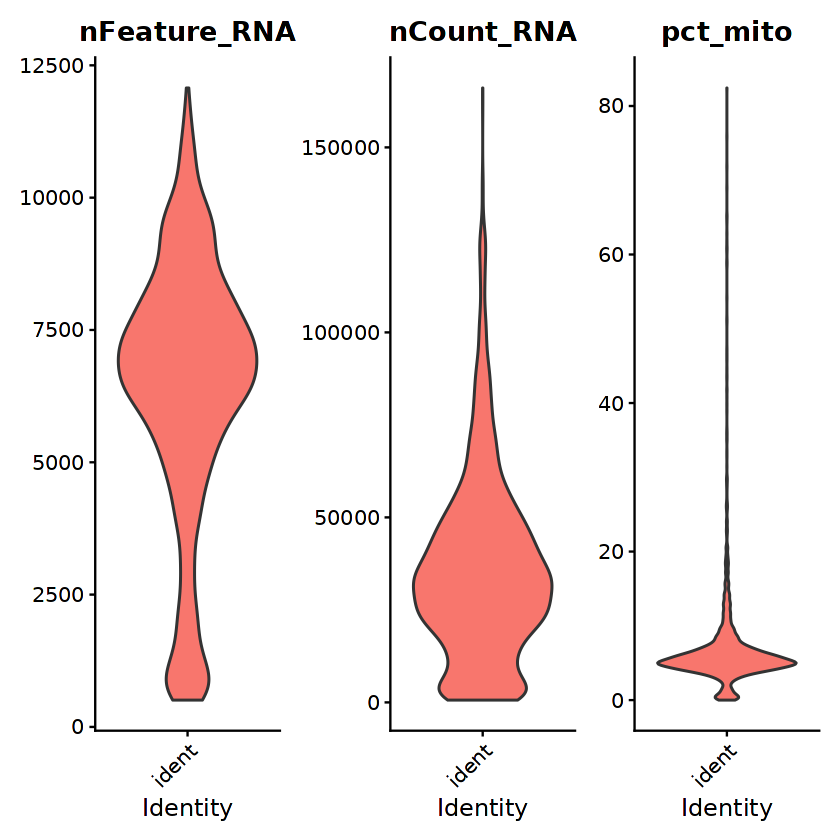

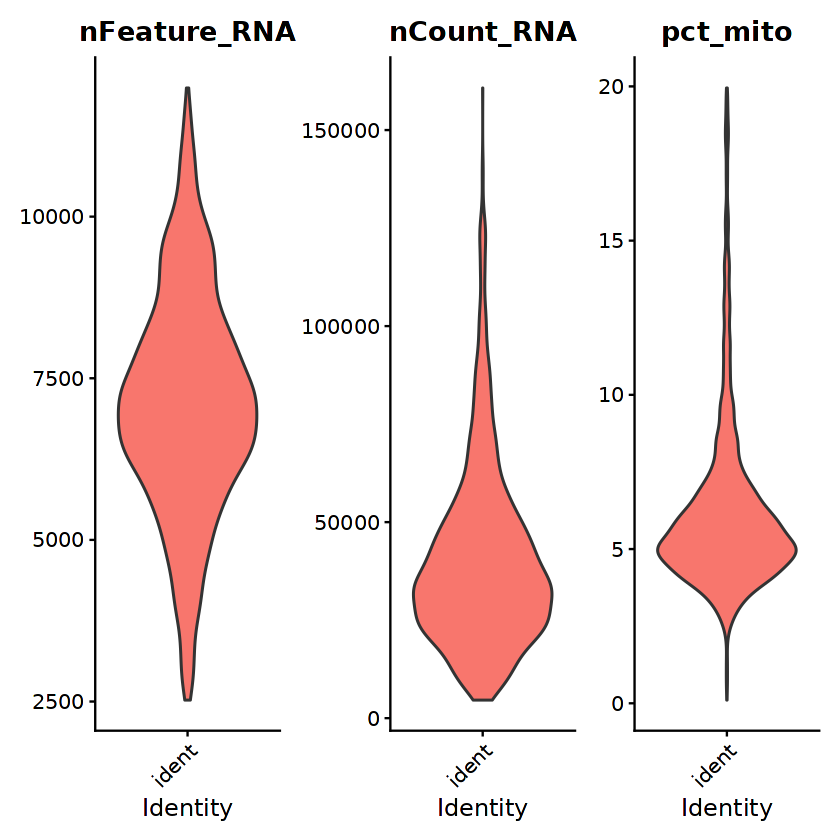

In [8]:
#Create Seurat object
punn.esc <- CreateSeuratObject(counts = punn.esc.raw, project = 'Punn_S6D13_ESC', assay = 'RNA', min.cells = 10, min.features = 500)
rm('punn.esc.raw')

#Add metadata
punn.esc = RenameCells(punn.esc, add.cell.id = 'punn.esc')
punn.esc$modality = 'expression'
punn.esc$dataset <- 'Punn_ESC_S6D14'
punn.esc$protocol = 'Millman.v3'
punn.esc$stage = 'Stage7_SCi'
punn.esc$day = 'Day32'
punn.esc$cellsource = 'ESC_HUES8'
punn.esc$gender = 'male'

#QC filtering
punn.esc[['pct_mito']] = PercentageFeatureSet(punn.esc, pattern = '^MT-')
VlnPlot(punn.esc, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

punn.esc <- subset(punn.esc, subset = nFeature_RNA > 2500 & nFeature_RNA < 12000 & pct_mito < 15)
VlnPlot(punn.esc, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(punn.esc)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
punn.esc = subset(punn.esc, features = anti_mt_genes)

#Save Checkpoint
saveRDS(punn.esc, file='checkpoints/RNA_datasets/punn_s6d13_esc.rds')
rm(punn.esc)

## Maxwell Sci Trans Med

### Stage 6 Day 14 - iPSC WS4corr from WU.WOLF-04

In [58]:
#Load RNA data
punn.ipsc.raw <- Read10X(data.dir = 'rawdata/RNA/Maxwell/WSiPSCcorrS6D14/outs/filtered_feature_bc_matrix')

In [59]:
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5I"] ="ATP5ME"
rownames(punn.ipsc.raw)[colnames(punn.ipsc.raw) == "ATP5G2"] ="ATP5MC2"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5E"] ="ATP5F1E"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5L"] ="ATP5MG"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "TCEB2"] ="ELOB"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "SHFM1"] ="SEM1"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "USMG5"] ="ATP5MD"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "NGFRAP1"] ="BEX3"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM213A"] ="PRXL2A"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "GNB2L1"] ="RACK1"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "TCEB3"] ="ELOA"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C8orf59"] ="RBIS"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C19orf24"] ="FAM174C"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C20orf24"] ="RAB5IF"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM173A"] ="ANTKMT"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C6orf1"] ="SMIM29"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "SEPT2"] ="SEPTIN2"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM57B"] ="TLCD3B"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "PVRL2"] ="NECTIN2"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM96A"] ="CIAO2A"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "KIAA1715"] ="LNPK"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "RTFDC1"] ="RTF2"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM134A"] ="RETREG2"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "STRA13"] ="CENPX"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C9orf3"] ="AOPEP"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "HBT8"] ="PWAR6"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "PVRL3"] ="NECTIN3"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "WRB"] ="GET1"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ASNA1"] ="GET3"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM60A"] ="SINHCAF"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM63B"] ="MINDY2"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "COL4A3BP"] ="CERT1"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "WHSC1"] ="NSD2"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "APOPT1"] ="COA8"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "TOMM70A"] ="TOMM70"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "PVRL1"] ="NECTIN1"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "TMEM261"] ="DMAC1"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM195A"] ="MCRIP2"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "PPP2R4"] ="PTPA"
#rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "SUMO2.1"] ="SUMO2"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "UQR11.1"] ="UQCR11"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C11orf73"] ="HIKESHI"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C19orf60"] ="REX1BD"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ZCCHC11"] ="TUT4"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "LHFP"] ="LHFPL6"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "MESDC2"] ="MESD"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM127B"] ="RTL8A"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C7orf55"] ="FMC1"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "LINC00493"] ="SMIM26"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "WBSCR22"] ="BUD23"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM105A"] ="OTULINL"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM127A"] ="RTL8C"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C14orf1"] ="ERG28"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "SEPT2"] ="SEPTIN2"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "VIMP"] ="SELENOS"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C16orf13"] ="METTL26"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "SELM"] ="SELENOM"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM195B"] ="MCRIP1"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "MLLT4"] ="AFDN"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "WBP5"] ="TCEAL9"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "SEPT11"] ="SEPTIN11"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C19orf70"] ="MICOS13"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "WHSC1L1"] ="NSD3"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5H"] ="ATP5PD"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "TCEB1"] ="ELOC"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5C1"] ="ATP5F1C"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "SEP15"] ="SELENOF"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM96B"] ="CIA02B"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C17orf89"] ="NDUFAF8"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "APOA1BP"] ="NAXE"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5F1"] ="ATP5PB"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM46A"] ="TENT5A"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C14orf166"] ="RTRAF"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "SEPT7"] ="SEPTIN7"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "MINOS1"] ="MICOS10"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C11orf31"] ="SELENOH"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "GLTSCR2"] ="NOP53"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "LINC01420"] ="NBDY"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "FAM159B"] ="SHISAL2B"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C7orf73"] ="STMP1"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "C19orf43"] ="TRIR"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "SELT"] ="SELENOT"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "AES"] ="TLE5"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5G1"] ="ATP5MC1"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5B"] ="ATP5F1B"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "SEPW1"] ="SELENOW"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5D"] ="ATP5F1D"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5O"] ="ATP5PO"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "SELK"] ="SELENOK"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "HN1"] ="JPT1"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATPIF1"] ="ATP5IF1"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5J"] ="ATP5PF"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5A1"] ="ATP5F1A"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5G3"] ="ATP5MC3"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "ATP5J2"] ="ATP5MF"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "MYEOV2"] ="COPS9"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "SEPT4"] ="SEPTIN4"
rownames(punn.ipsc.raw)[rownames(punn.ipsc.raw) == "LARGE1"] ="LARGE"

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


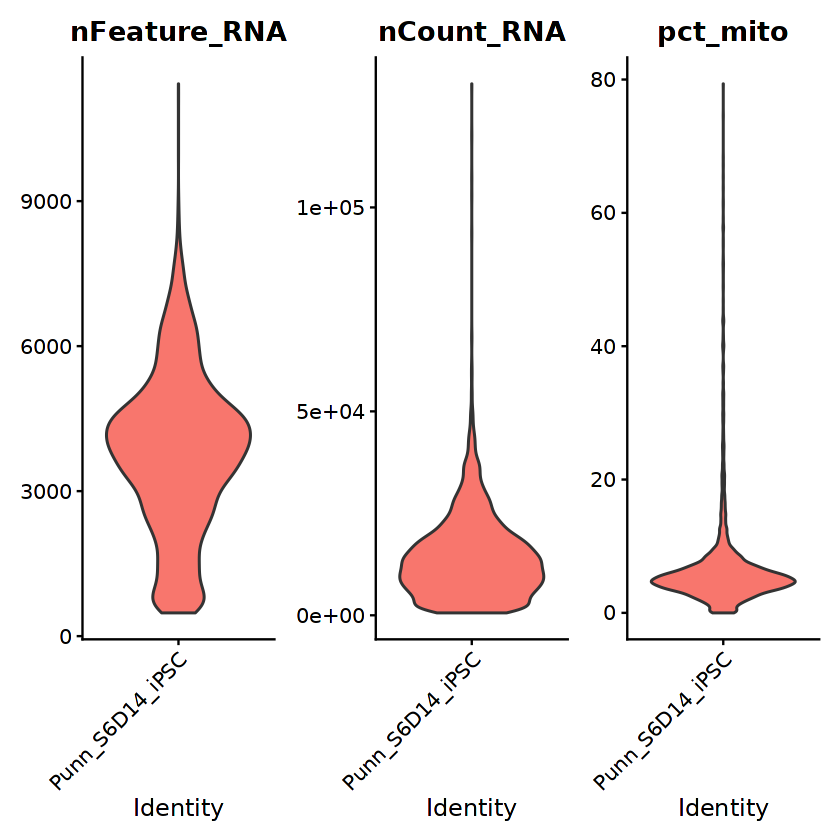

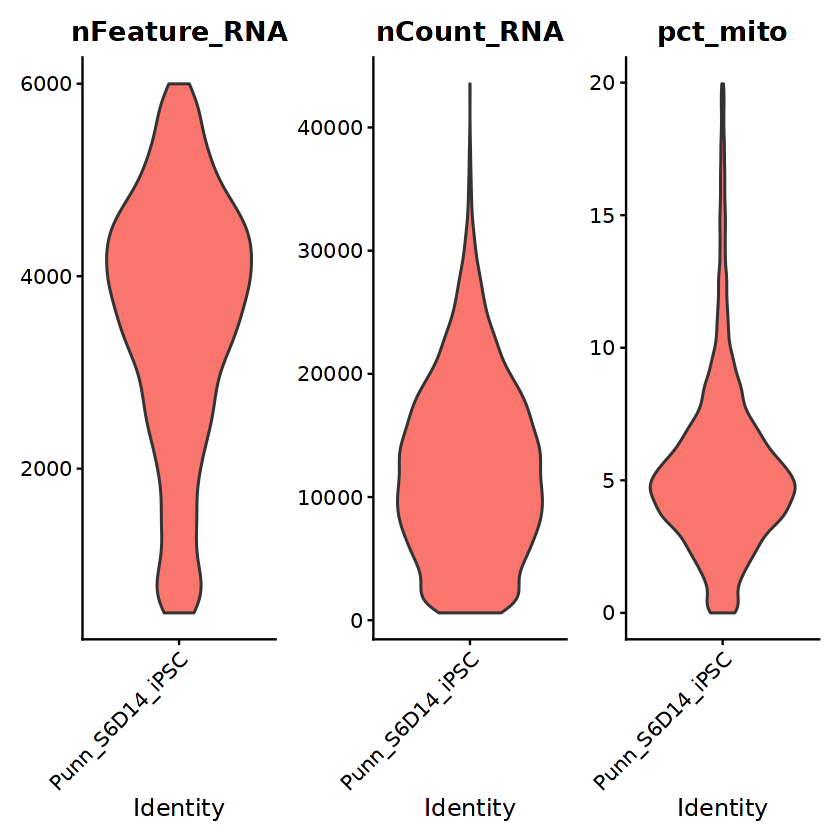

In [60]:
#Create Seurat object
punn.ipsc <- CreateSeuratObject(counts = punn.ipsc.raw, project = 'Punn_S6D14_iPSC', assay = 'RNA', min.cells = 10, min.features = 500)
rm('punn.ipsc.raw')

#Add metadata
punn.ipsc = RenameCells(punn.ipsc, add.cell.id = 'punn.ipsc')
punn.ipsc$modality = 'expression'
punn.ipsc$dataset <- 'Punn_iPSC_S6D14'
punn.ipsc$protocol = 'Millman.v3'
punn.ipsc$stage = 'Stage7_SCi'
punn.ipsc$day = 'Day34'
punn.ipsc$cellsource = 'iPSC_WS4corr'
punn.ipsc$gender = 'female'

#QC filtering
punn.ipsc[['pct_mito']] = PercentageFeatureSet(punn.ipsc, pattern = '^MT-')
VlnPlot(punn.ipsc, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

punn.ipsc <- subset(punn.ipsc, subset = nFeature_RNA > 500 & nFeature_RNA < 6000 & pct_mito < 20)
VlnPlot(punn.ipsc, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(punn.ipsc)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
punn.ipsc = subset(punn.ipsc, features = anti_mt_genes)

#Save Checkpoint
saveRDS(punn.ipsc, file='checkpoints/RNA_datasets/punn_s6d14_ipsc.rds')
rm(punn.ipsc)

## Weng et al Nature Metabolism 2020

### Stage 2 Day 1

In [61]:
#load raw data
weng.s2d1.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274569_S2D1.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s2d1.raw)<- weng.s2d1.raw[,1]
weng.s2d1.raw <- weng.s2d1.raw[,-1]
class(weng.s2d1.raw) <- "integer"
weng.s2d1.raw <- as(weng.s2d1.raw, "sparseMatrix") 

In [ ]:
#Homogenization of gene names
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "H1-0"] ="H1F0"
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "EPRS1"] ="EPRS"
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "TARS1"] ="TARS"
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "H1-10"] ="H1FX"
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "NARS1"] ="NARS"
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s2d1.raw)[rownames(weng.s2d1.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s2d1 <-CreateSeuratObject(counts=weng.s2d1.raw, project='Weng_s2d1', min.cells = 10, min.features = 500)

#Add metadata
weng.s2d1 = RenameCells(weng.s2d1, add.cell.id = 'weng.s2d1')
weng.s2d1$modality <- 'expression'
weng.s2d1$dataset <- 'Weng_s2d1'
weng.s2d1$protocol = 'Rezania'
weng.s2d1$stage = 'Stage2_DE'
weng.s2d1$day = 'Day3'
weng.s2d1$cellsource = 'ESC_H1'
weng.s2d1$gender = 'male'

#QC filtering
weng.s2d1[['pct_mito']] = PercentageFeatureSet(weng.s2d1, pattern = '^MT-')
VlnPlot(weng.s2d1, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s2d1 <- subset(weng.s2d1, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s2d1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s2d1, file='checkpoints/RNA_datasets/weng_s2d1.rds')
rm(list = c("weng.s2d1.raw","weng.s2d1"))

### Stage 2 Day 2

In [ ]:
#load raw data
weng.s2d2.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274570_S2D2.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s2d2.raw)<- weng.s2d2.raw[,1]
weng.s2d2.raw <- weng.s2d2.raw[,-1]
class(weng.s2d2.raw) <- "integer"
weng.s2d2.raw <- as(weng.s2d2.raw, "sparseMatrix") 

In [ ]:
#Homogenization of gene names
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "H1-0"] ="H1F0"
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "EPRS1"] ="EPRS"
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "TARS1"] ="TARS"
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "H1-10"] ="H1FX"
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "NARS1"] ="NARS"
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s2d2.raw)[rownames(weng.s2d2.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s2d2 <-CreateSeuratObject(counts=weng.s2d2.raw, project='Weng_s2d2', min.cells = 10, min.features = 500)

#Add metadata
weng.s2d2 = RenameCells(weng.s2d2, add.cell.id = 'weng.s2d2')
weng.s2d2$modality <- 'expression'
weng.s2d2$dataset <- 'Weng_s2d2'
weng.s2d2$protocol = 'Rezania'
weng.s2d2$stage = 'Stage2_DE'
weng.s2d2$day = 'Day4'
weng.s2d2$cellsource = 'ESC_H1'
weng.s2d2$gender = 'male'

#QC filtering
weng.s2d2[['pct_mito']] = PercentageFeatureSet(weng.s2d2, pattern = '^MT-')
VlnPlot(weng.s2d2, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s2d2 <- subset(weng.s2d2, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s2d2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s2d2, file='checkpoints/RNA_datasets/weng_s2d2.rds')
rm(list = c("weng.s2d2.raw","weng.s2d2"))

### Stage 2 Day 3a

In [ ]:
#load raw data
weng.s2d3a.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274571_S2D3.A.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s2d3a.raw)<- weng.s2d3a.raw[,1]
weng.s2d3a.raw <- weng.s2d3a.raw[,-1]
class(weng.s2d3a.raw) <- "integer"
weng.s2d3a.raw <- as(weng.s2d3a.raw, "sparseMatrix") 

In [ ]:
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "H1-0"] ="H1F0"
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "EPRS1"] ="EPRS"
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "TARS1"] ="TARS"
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "H1-10"] ="H1FX"
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "NARS1"] ="NARS"
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s2d3a.raw)[rownames(weng.s2d3a.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s2d3a <-CreateSeuratObject(counts=weng.s2d3a.raw, project='Weng_s2d3a', min.cells = 10, min.features = 500)

#Add metadata
weng.s2d3a = RenameCells(weng.s2d3a, add.cell.id = 'weng.s2d3a')
weng.s2d3a$modality <- 'expression'
weng.s2d3a$dataset <- 'Weng_s2d3a'
weng.s2d3a$protocol = 'Rezania'
weng.s2d3a$stage = 'Stage3_PGT'
weng.s2d3a$day = 'Day6'
weng.s2d3a$cellsource = 'ESC_H1'
weng.s2d3a$gender = 'male'

#QC filtering
weng.s2d3a[['pct_mito']] = PercentageFeatureSet(weng.s2d3a, pattern = '^MT-')
VlnPlot(weng.s2d3a, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s2d3a <- subset(weng.s2d3a, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s2d3a, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s2d3a, file='checkpoints/RNA_datasets/weng_s2d3a.rds')
rm(list = c("weng.s2d3a.raw","weng.s2d3a"))

### Stage 2 Day 3b

In [ ]:
#load raw data
weng.s2d3b.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274572_S2D3.B.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s2d3b.raw)<- weng.s2d3b.raw[,1]
weng.s2d3b.raw <- weng.s2d3b.raw[,-1]
class(weng.s2d3b.raw) <- "integer"
weng.s2d3b.raw <- as(weng.s2d3b.raw, "sparseMatrix") 

In [ ]:
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "H1-0"] ="H1F0"
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "EPRS1"] ="EPRS"
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "TARS1"] ="TARS"
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "H1-10"] ="H1FX"
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "NARS1"] ="NARS"
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s2d3b.raw)[rownames(weng.s2d3b.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s2d3b <-CreateSeuratObject(counts=weng.s2d3b.raw, project="Weng_s2d3b", min.cells = 10, min.features = 500)

#Add metadata
weng.s2d3b = RenameCells(weng.s2d3b, add.cell.id = 'weng.s2d3b')
weng.s2d3b$modality <- 'expression'
weng.s2d3b$dataset <- 'weng.s2d3b'
weng.s2d3b$protocol = 'Rezania'
weng.s2d3b$stage = 'Stage3_PGT'
weng.s2d3b$day = 'Day6'
weng.s2d3b$cellsource = 'ESC_H1'
weng.s2d3b$gender = 'male'

#QC filtering
weng.s2d3b[['pct_mito']] = PercentageFeatureSet(weng.s2d3b, pattern = '^MT-')
VlnPlot(weng.s2d3b, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s2d3b <- subset(weng.s2d3b, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s2d3b, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s2d3b, file='checkpoints/RNA_datasets/weng_s2d3b.rds')
rm(list = c("weng.s2d3b.raw","weng.s2d3b"))

### Stage 3

In [ ]:
#load raw data
weng.s3.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274574_S3.B.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s3.raw)<- weng.s3.raw[,1]
weng.s3.raw <- weng.s3.raw[,-1]
class(weng.s3.raw) <- "integer"
weng.s3.raw <- as(weng.s3.raw, "sparseMatrix") 

In [ ]:
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "H1-0"] ="H1F0"
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "EPRS1"] ="EPRS"
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "TARS1"] ="TARS"
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "H1-10"] ="H1FX"
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "NARS1"] ="NARS"
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s3.raw)[rownames(weng.s3.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s3 <-CreateSeuratObject(counts=weng.s3.raw, project="Weng_s3", min.cells = 10, min.features = 500)

#Add metadata
weng.s3 = RenameCells(weng.s3, add.cell.id = 'weng.s3')
weng.s3$modality <- 'expression'
weng.s3$dataset <- 'Weng_s3'
weng.s3$protocol = 'Rezania'
weng.s3$stage = 'Stage4_PP1'
weng.s3$day = 'Day9'
weng.s3$cellsource = 'ESC_H1'
weng.s3$gender = 'male'

#QC filtering
weng.s3[['pct_mito']] = PercentageFeatureSet(weng.s3, pattern = '^MT-')
VlnPlot(weng.s3, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s3 <- subset(weng.s3, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s3, file='checkpoints/RNA_datasets/weng_s3.rds')
rm(list = c("weng.s3.raw","weng.s3"))

### Stage 4

In [ ]:
#load raw data
weng.s4.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274575_S4.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s4.raw)<- weng.s4.raw[,1]
weng.s4.raw <- weng.s4.raw[,-1]
class(weng.s4.raw) <- "integer"
weng.s4.raw <- as(weng.s4.raw, "sparseMatrix")

In [ ]:
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "H1-0"] ="H1F0"
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "EPRS1"] ="EPRS"
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "TARS1"] ="TARS"
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "H1-10"] ="H1FX"
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "NARS1"] ="NARS"
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s4.raw)[rownames(weng.s4.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s4 <-CreateSeuratObject(counts=weng.s4.raw, project='Weng_s4', min.cells = 10, min.features = 500)

#Add metadata
weng.s4 = RenameCells(weng.s4, add.cell.id = 'weng.s4')
weng.s4$modality <- 'expression'
weng.s4$dataset <- 'weng.s4'
weng.s4$protocol = 'Rezania'
weng.s4$stage = 'Stage5_PP2'
weng.s4$day = 'Day14'
weng.s4$cellsource = 'ESC_H1'
weng.s4$gender = 'male'

#QC filtering
weng.s4[['pct_mito']] = PercentageFeatureSet(weng.s4, pattern = '^MT-')
VlnPlot(weng.s4, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s4 <- subset(weng.s4, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s4, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s4, file='checkpoints/RNA_datasets/weng_s4.rds')
rm(list = c("weng.s4.raw","weng.s4"))

### Stage 5a

In [ ]:
#load raw data
weng.s5a.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274576_S5.A.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s5a.raw)<- weng.s5a.raw[,1]
weng.s5a.raw <- weng.s5a.raw[,-1]
class(weng.s5a.raw) <- "integer"
weng.s5a.raw <- as(weng.s5a.raw, "sparseMatrix")

In [ ]:
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "H1-0"] ="H1F0"
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "EPRS1"] ="EPRS"
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "TARS1"] ="TARS"
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "H1-10"] ="H1FX"
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "NARS1"] ="NARS"
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s5a.raw)[rownames(weng.s5a.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s5a <-CreateSeuratObject(counts=weng.s5a.raw, project="Weng_s5a", min.cells = 10, min.features = 500)

#Add metadata
weng.s5a = RenameCells(weng.s5a, add.cell.id = 'weng.s5a')
weng.s5a$modality <- 'expression'
weng.s5a$dataset <- 'weng.s5a'
weng.s5a$protocol = 'Rezania'
weng.s5a$stage = 'Stage5_PP2'
weng.s5a$day = 'Day17'
weng.s5a$cellsource = 'ESC_H1'
weng.s5a$gender = 'male'

#QC filtering
weng.s5a[['pct_mito']] = PercentageFeatureSet(weng.s5a, pattern = '^MT-')
VlnPlot(weng.s5a, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s5a <- subset(weng.s5a, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s5a, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s5a, file='checkpoints/RNA_datasets/weng_s5a.rds')
rm(list = c("weng.s5a.raw","weng.s5a"))

### Stage 5b

In [ ]:
#load raw data
weng.s5b.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274577_S5.B.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s5b.raw)<- weng.s5b.raw[,1]
weng.s5b.raw <- weng.s5b.raw[,-1]
class(weng.s5b.raw) <- "integer"
weng.s5b.raw <- as(weng.s5b.raw, "sparseMatrix")

In [ ]:
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "H1-0"] ="H1F0"
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "EPRS1"] ="EPRS"
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "TARS1"] ="TARS"
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "H1-10"] ="H1FX"
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "NARS1"] ="NARS"
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s5b.raw)[rownames(weng.s5b.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s5b <-CreateSeuratObject(counts=weng.s5b.raw, project='Weng_s5b', min.cells = 10, min.features = 500)

#Add metadata
weng.s5b = RenameCells(weng.s5b, add.cell.id = 'weng.s5b')
weng.s5b$modality <- 'expression'
weng.s5b$dataset <- 'weng.s5b'
weng.s5b$protocol = 'Rezania'
weng.s5b$stage = 'Stage5_PP2'
weng.s5b$day = 'Day17'
weng.s5b$cellsource = 'ESC_H1'
weng.s5b$gender = 'male'

#QC filtering
weng.s5b[['pct_mito']] = PercentageFeatureSet(weng.s5b, pattern = '^MT-')
VlnPlot(weng.s5b, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s5b <- subset(weng.s5b, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s5b, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s5b, file='checkpoints/RNA_datasets/weng_s5b.rds')
rm(list = c("weng.s5b.raw","weng.s5b"))

### Stage 5rock 

In [ ]:
#load raw data
weng.s5rock.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274578_S5.ROCK.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s5rock.raw)<- weng.s5rock.raw[,1]
weng.s5rock.raw <- weng.s5rock.raw[,-1]
class(weng.s5rock.raw) <- "integer"
weng.s5rock.raw <- as(weng.s5rock.raw, "sparseMatrix")

In [ ]:
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "H1-0"] ="H1F0"
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "EPRS1"] ="EPRS"
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "TARS1"] ="TARS"
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "H1-10"] ="H1FX"
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "NARS1"] ="NARS"
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s5rock.raw)[rownames(weng.s5rock.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s5rock <-CreateSeuratObject(counts=weng.s5rock.raw, project="Weng_s5rock", min.cells = 10, min.features = 500)

#Add metadata
weng.s5rock = RenameCells(weng.s5rock, add.cell.id = 'weng.s5rock')
weng.s5rock$modality <- 'expression'
weng.s5rock$dataset <- 'weng.s5rock'
weng.s5rock$protocol = 'Weng'
weng.s5rock$stage = 'Stage5_PP2'
weng.s5rock$day = 'Day17'
weng.s5rock$cellsource = 'ESC_H1'
weng.s5rock$gender = 'male'

#QC filtering
weng.s5rock[['pct_mito']] = PercentageFeatureSet(weng.s5rock, pattern = '^MT-')
VlnPlot(weng.s5rock, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s5rock <- subset(weng.s5rock, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s5rock, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s5rock, file='checkpoints/RNA_datasets/weng_s5rock.rds')
rm(list = c("weng.s5rock.raw","weng.s5rock"))

### Stage 6 

In [ ]:
#load raw data
weng.s6.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274579_S6.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s6.raw)<- weng.s6.raw[,1]
weng.s6.raw <- weng.s6.raw[,-1]
class(weng.s6.raw) <- "integer"
weng.s6.raw <- as(weng.s6.raw, "sparseMatrix")

In [ ]:
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "H1-0"] ="H1F0"
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "EPRS1"] ="EPRS"
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "TARS1"] ="TARS"
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "H1-10"] ="H1FX"
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "NARS1"] ="NARS"
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s6.raw)[rownames(weng.s6.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s6 <-CreateSeuratObject(counts=weng.s6.raw, project='Weng_s6', min.cells = 10, min.features = 500)

#Add metadata
weng.s6 = RenameCells(weng.s6, add.cell.id = 'weng.s6')
weng.s6$modality <- 'expression'
weng.s6$dataset <- 'weng.s6'
weng.s6$protocol = 'Rezania'
weng.s6$stage = 'Stage6_EP'
weng.s6$day = 'Day24'
weng.s6$cellsource = 'ESC_H1'
weng.s6$gender = 'male'

#QC filtering
weng.s6[['pct_mito']] = PercentageFeatureSet(weng.s6, pattern = '^MT-')
VlnPlot(weng.s6, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s6 <- subset(weng.s6, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s6, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s6, file='checkpoints/RNA_datasets/weng_s6.rds')
rm(list = c("weng.s6.raw","weng.s6"))

### Stage 6rocka

In [ ]:
#load raw data
weng.s6rocka.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274580_S6.ROCK.A.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s6rocka.raw)<- weng.s6rocka.raw[,1]
weng.s6rocka.raw <- weng.s6rocka.raw[,-1]
class(weng.s6rocka.raw) <- "integer"
weng.s6rocka.raw <- as(weng.s6rocka.raw, "sparseMatrix")

In [ ]:
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "H1-0"] ="H1F0"
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "EPRS1"] ="EPRS"
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "TARS1"] ="TARS"
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "H1-10"] ="H1FX"
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "NARS1"] ="NARS"
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s6rocka.raw)[rownames(weng.s6rocka.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s6rocka <-CreateSeuratObject(counts=weng.s6rocka.raw, project='Weng_s6rocka', min.cells = 10, min.features = 500)

#Add metadata
weng.s6rocka = RenameCells(weng.s6rocka, add.cell.id = 'weng.s6rocka')
weng.s6rocka$modality <- 'expression'
weng.s6rocka$dataset <- 'weng.s6rocka'
weng.s6rocka$protocol = 'Weng'
weng.s6rocka$stage = 'Stage6_EP'
weng.s6rocka$day = 'Day24'
weng.s6rocka$cellsource = 'ESC_H1'
weng.s6rocka$gender = 'male'

#QC filtering
weng.s6rocka[['pct_mito']] = PercentageFeatureSet(weng.s6rocka, pattern = '^MT-')
VlnPlot(weng.s6rocka, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s6rocka <- subset(weng.s6rocka, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s6rocka, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s6rocka, file='checkpoints/RNA_datasets/weng_s6rocka.rds')
rm(list = c("weng.s6rocka.raw","weng.s6rocka"))

### Stage 6rockb

In [ ]:
#load raw data
weng.s6rockb.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274581_S6.ROCK.B.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s6rockb.raw)<- weng.s6rockb.raw[,1]
weng.s6rockb.raw <- weng.s6rockb.raw[,-1]
class(weng.s6rockb.raw) <- "integer"
weng.s6rockb.raw <- as(weng.s6rockb.raw, "sparseMatrix")

In [ ]:
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "H1-0"] ="H1F0"
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "EPRS1"] ="EPRS"
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "TARS1"] ="TARS"
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "H1-10"] ="H1FX"
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "NARS1"] ="NARS"
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s6rockb.raw)[rownames(weng.s6rockb.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s6rockb <-CreateSeuratObject(counts=weng.s6rockb.raw, project="Weng_s6rockb", min.cells = 10, min.features = 500)

#Add metadata
weng.s6rockb = RenameCells(weng.s6rockb, add.cell.id = 'weng.s6rockb')
weng.s6rockb$modality <- 'expression'
weng.s6rockb$dataset <- 'weng.s6rockb'
weng.s6rockb$protocol = 'Weng'
weng.s6rockb$stage = 'Stage6_EP'
weng.s6rockb$day = 'Day24'
weng.s6rockb$cellsource = 'ESC_H1'
weng.s6rockb$gender = 'male'

#QC filtering
weng.s6rockb[['pct_mito']] = PercentageFeatureSet(weng.s6rockb, pattern = '^MT-')
VlnPlot(weng.s6rockb, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s6rockb <- subset(weng.s6rockb, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s6rockb, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s6rockb, file='checkpoints/RNA_datasets/weng_s6rockb.rds')
rm(list = c("weng.s6rockb.raw","weng.s6rockb"))

### Stage 7

In [ ]:
#load raw data
weng.s7.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274582_S7.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s7.raw)<- weng.s7.raw[,1]
weng.s7.raw <- weng.s7.raw[,-1]
class(weng.s7.raw) <- "integer"
weng.s7.raw <- as(weng.s7.raw, "sparseMatrix")

In [ ]:
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "H1-0"] ="H1F0"
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "EPRS1"] ="EPRS"
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "TARS1"] ="TARS"
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "H1-10"] ="H1FX"
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "NARS1"] ="NARS"
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s7.raw)[rownames(weng.s7.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s7 <-CreateSeuratObject(counts=weng.s7.raw, project='Weng_s7', min.cells = 10, min.features = 500)

#Add metadata
weng.s7 = RenameCells(weng.s7, add.cell.id = 'weng.s7')
weng.s7$modality <- 'expression'
weng.s7$dataset <- 'weng.s7'
weng.s7$protocol = 'Rezania'
weng.s7$stage = 'Stage7_SCi'
weng.s7$day = 'Day31'
weng.s7$cellsource = 'ESC_H1'
weng.s7$gender = 'male'

#QC filtering
weng.s7[['pct_mito']] = PercentageFeatureSet(weng.s7, pattern = '^MT-')
VlnPlot(weng.s7, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s7 <- subset(weng.s7, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s7, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s7, file='checkpoints/RNA_datasets/weng_s7.rds')
rm(list = c("weng.s7.raw","weng.s7"))

### Stage 7rock

In [ ]:
#load raw data
weng.s7rock.raw<-as.matrix(fread('rawdata/RNA/Weng/GSM4274583_S7.ROCK.gene_exon_tagged.cleaned.dge.txt'))
rownames(weng.s7rock.raw)<- weng.s7rock.raw[,1]
weng.s7rock.raw <- weng.s7rock.raw[,-1]
class(weng.s7rock.raw) <- "integer"
weng.s7rock.raw <- as(weng.s7rock.raw, "sparseMatrix")

In [ ]:
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "H3-3B"] ="H3F3B"
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "H2AJ"] ="H2AFJ"
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "H2AZ1"] ="H2AFZ"
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "MACROH2A1"] ="H2AFY"
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "H1-0"] ="H1F0"
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "EPRS1"] ="EPRS"
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "PME3IP1"] ="FAM192A"
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "TARS1"] ="TARS"
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "H1-10"] ="H1FX"
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "H4C3"] ="HIST1H4C"
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "NARS1"] ="NARS"
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "H2AZ2"] ="H2AFV"
rownames(weng.s7rock.raw)[rownames(weng.s7rock.raw) == "H1-4"] ="HIST1H1E"

In [ ]:
#create seurat object
weng.s7rock <-CreateSeuratObject(counts=weng.s7rock.raw, project='Weng_s7rock', min.cells = 10, min.features = 500)

#Add metadata
weng.s7rock = RenameCells(weng.s7rock, add.cell.id = 'weng.s7rock')
weng.s7rock$modality <- 'expression'
weng.s7rock$dataset <- 'weng.s7rock'
weng.s7rock$protocol = 'Weng'
weng.s7rock$stage = 'Stage7_SCi'
weng.s7rock$day = 'Day31'
weng.s7rock$cellsource = 'ESC_H1'
weng.s7rock$gender = 'male'

#QC filtering
weng.s7rock[['pct_mito']] = PercentageFeatureSet(weng.s7rock, pattern = '^MT-')
VlnPlot(weng.s7rock, features = c('nFeature_RNA', 'nCount_RNA'), ncol = 3, pt.size = 0)

weng.s7rock <- subset(weng.s7rock, subset = nFeature_RNA > 500 & nFeature_RNA < 4000)
VlnPlot(weng.s7rock, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Save Checkpoint
saveRDS(weng.s7rock, file='checkpoints/RNA_datasets/weng_s7rock.rds')
rm(list = c("weng.s7rock.raw","weng.s7rock"))

## Balboa et al Nature Biotechnology 2022

### Stage 5 DT - H1

In [ ]:
#Load RNA data
balboa.s5dt.raw <- Read10X(data.dir = 'rawdata/RNA/Balboa/Stage5_DT/outs/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5I"] ="ATP5ME"
rownames(balboa.s5dt.raw)[colnames(balboa.s5dt.raw) == "ATP5G2"] ="ATP5MC2"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5E"] ="ATP5F1E"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5L"] ="ATP5MG"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "TCEB2"] ="ELOB"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SHFM1"] ="SEM1"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "USMG5"] ="ATP5MD"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "NGFRAP1"] ="BEX3"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM213A"] ="PRXL2A"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "GNB2L1"] ="RACK1"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "TCEB3"] ="ELOA"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C8orf59"] ="RBIS"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C19orf24"] ="FAM174C"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C20orf24"] ="RAB5IF"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM173A"] ="ANTKMT"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C6orf1"] ="SMIM29"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM57B"] ="TLCD3B"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "PVRL2"] ="NECTIN2"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM96A"] ="CIAO2A"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "KIAA1715"] ="LNPK"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "RTFDC1"] ="RTF2"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM134A"] ="RETREG2"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "STRA13"] ="CENPX"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C9orf3"] ="AOPEP"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "HBT8"] ="PWAR6"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "PVRL3"] ="NECTIN3"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "WRB"] ="GET1"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ASNA1"] ="GET3"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM60A"] ="SINHCAF"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM63B"] ="MINDY2"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "COL4A3BP"] ="CERT1"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "WHSC1"] ="NSD2"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "APOPT1"] ="COA8"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "TOMM70A"] ="TOMM70"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "PVRL1"] ="NECTIN1"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "TMEM261"] ="DMAC1"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM195A"] ="MCRIP2"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "PPP2R4"] ="PTPA"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "UQR11.1"] ="UQCR11"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C11orf73"] ="HIKESHI"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C19orf60"] ="REX1BD"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ZCCHC11"] ="TUT4"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "LHFP"] ="LHFPL6"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "MESDC2"] ="MESD"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM127B"] ="RTL8A"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C7orf55"] ="FMC1"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "LINC00493"] ="SMIM26"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "WBSCR22"] ="BUD23"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM105A"] ="OTULINL"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM127A"] ="RTL8C"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C14orf1"] ="ERG28"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "VIMP"] ="SELENOS"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C16orf13"] ="METTL26"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SELM"] ="SELENOM"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM195B"] ="MCRIP1"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "MLLT4"] ="AFDN"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "WBP5"] ="TCEAL9"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SEPT11"] ="SEPTIN11"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C19orf70"] ="MICOS13"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "WHSC1L1"] ="NSD3"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5H"] ="ATP5PD"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "TCEB1"] ="ELOC"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5C1"] ="ATP5F1C"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SEP15"] ="SELENOF"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM96B"] ="CIA02B"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C17orf89"] ="NDUFAF8"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "APOA1BP"] ="NAXE"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5F1"] ="ATP5PB"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM46A"] ="TENT5A"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C14orf166"] ="RTRAF"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SEPT7"] ="SEPTIN7"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "MINOS1"] ="MICOS10"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C11orf31"] ="SELENOH"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "GLTSCR2"] ="NOP53"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "LINC01420"] ="NBDY"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "FAM159B"] ="SHISAL2B"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C7orf73"] ="STMP1"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "C19orf43"] ="TRIR"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SELT"] ="SELENOT"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "AES"] ="TLE5"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5G1"] ="ATP5MC1"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5B"] ="ATP5F1B"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SEPW1"] ="SELENOW"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5D"] ="ATP5F1D"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5O"] ="ATP5PO"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SELK"] ="SELENOK"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "HN1"] ="JPT1"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATPIF1"] ="ATP5IF1"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5J"] ="ATP5PF"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5A1"] ="ATP5F1A"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5G3"] ="ATP5MC3"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "ATP5J2"] ="ATP5MF"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "MYEOV2"] ="COPS9"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "UQCR11.1"] ="UQCR11"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "SEPT4"] ="SEPTIN4"
rownames(balboa.s5dt.raw)[rownames(balboa.s5dt.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
balboa.s5dt <- CreateSeuratObject(counts = balboa.s5dt.raw, project = 'Balboa_S5DT', assay = 'RNA', min.cells = 10, min.features = 500)
rm('balboa.s5dt.raw')

#Add metadata
balboa.s5dt = RenameCells(balboa.s5dt, add.cell.id = 'balboa.s5dt')
balboa.s5dt$modality <- 'expression'
balboa.s5dt$dataset <- 'Balboa_S5DT'
balboa.s5dt$protocol = 'Balboa'
balboa.s5dt$stage = 'Stage5_PP2'
balboa.s5dt$day = 'Day16'
balboa.s5dt$cellsource = 'ESC_H1'
balboa.s5dt$gender = 'male'

#QC filtering
balboa.s5dt[['pct_mito']] = PercentageFeatureSet(balboa.s5dt, pattern = '^MT-')
VlnPlot(balboa.s5dt, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

balboa.s5dt <- subset(balboa.s5dt, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(balboa.s5dt, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(balboa.s5dt)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
balboa.s5dt = subset(balboa.s5dt, features = anti_mt_genes)

#Save Checkpoint
saveRDS(balboa.s5dt, file='checkpoints/RNA_datasets/balboa_s5dt.rds')
rm(balboa.s5dt)

### Stage 5 NT - H1

In [ ]:
#Load RNA data
balboa.s5nt.raw <- Read10X(data.dir = 'rawdata/RNA/Balboa/Stage5_NT/outs/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5I"] ="ATP5ME"
rownames(balboa.s5nt.raw)[colnames(balboa.s5nt.raw) == "ATP5G2"] ="ATP5MC2"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5E"] ="ATP5F1E"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5L"] ="ATP5MG"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "TCEB2"] ="ELOB"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SHFM1"] ="SEM1"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "USMG5"] ="ATP5MD"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "NGFRAP1"] ="BEX3"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM213A"] ="PRXL2A"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "GNB2L1"] ="RACK1"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "TCEB3"] ="ELOA"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C8orf59"] ="RBIS"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C19orf24"] ="FAM174C"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C20orf24"] ="RAB5IF"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM173A"] ="ANTKMT"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C6orf1"] ="SMIM29"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM57B"] ="TLCD3B"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "PVRL2"] ="NECTIN2"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM96A"] ="CIAO2A"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "KIAA1715"] ="LNPK"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "RTFDC1"] ="RTF2"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM134A"] ="RETREG2"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "STRA13"] ="CENPX"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C9orf3"] ="AOPEP"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "HBT8"] ="PWAR6"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "PVRL3"] ="NECTIN3"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "WRB"] ="GET1"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ASNA1"] ="GET3"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM60A"] ="SINHCAF"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM63B"] ="MINDY2"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "COL4A3BP"] ="CERT1"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "WHSC1"] ="NSD2"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "APOPT1"] ="COA8"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "TOMM70A"] ="TOMM70"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "PVRL1"] ="NECTIN1"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "TMEM261"] ="DMAC1"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM195A"] ="MCRIP2"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "PPP2R4"] ="PTPA"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "UQR11.1"] ="UQCR11"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C11orf73"] ="HIKESHI"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C19orf60"] ="REX1BD"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ZCCHC11"] ="TUT4"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "LHFP"] ="LHFPL6"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "MESDC2"] ="MESD"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM127B"] ="RTL8A"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C7orf55"] ="FMC1"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "LINC00493"] ="SMIM26"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "WBSCR22"] ="BUD23"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM105A"] ="OTULINL"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM127A"] ="RTL8C"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C14orf1"] ="ERG28"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "VIMP"] ="SELENOS"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C16orf13"] ="METTL26"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SELM"] ="SELENOM"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM195B"] ="MCRIP1"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "MLLT4"] ="AFDN"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "WBP5"] ="TCEAL9"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SEPT11"] ="SEPTIN11"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C19orf70"] ="MICOS13"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "WHSC1L1"] ="NSD3"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5H"] ="ATP5PD"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "TCEB1"] ="ELOC"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5C1"] ="ATP5F1C"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SEP15"] ="SELENOF"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM96B"] ="CIA02B"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C17orf89"] ="NDUFAF8"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "APOA1BP"] ="NAXE"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5F1"] ="ATP5PB"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM46A"] ="TENT5A"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C14orf166"] ="RTRAF"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SEPT7"] ="SEPTIN7"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "MINOS1"] ="MICOS10"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C11orf31"] ="SELENOH"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "GLTSCR2"] ="NOP53"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "LINC01420"] ="NBDY"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "FAM159B"] ="SHISAL2B"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C7orf73"] ="STMP1"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "C19orf43"] ="TRIR"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SELT"] ="SELENOT"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "AES"] ="TLE5"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5G1"] ="ATP5MC1"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5B"] ="ATP5F1B"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SEPW1"] ="SELENOW"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5D"] ="ATP5F1D"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5O"] ="ATP5PO"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SELK"] ="SELENOK"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "HN1"] ="JPT1"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATPIF1"] ="ATP5IF1"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5J"] ="ATP5PF"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5A1"] ="ATP5F1A"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5G3"] ="ATP5MC3"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "ATP5J2"] ="ATP5MF"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "MYEOV2"] ="COPS9"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "UQCR11.1"] ="UQCR11"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "SEPT4"] ="SEPTIN4"
rownames(balboa.s5nt.raw)[rownames(balboa.s5nt.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
balboa.sndt <- CreateSeuratObject(counts = balboa.s5nt.raw, project = 'Balboa_S5NT', assay = 'RNA', min.cells = 10, min.features = 500)
rm('balboa.s5nt.raw')

#Add metadata
balboa.sndt = RenameCells(balboa.sndt, add.cell.id = 'balboa.sndt')
balboa.sndt$modality <- 'expression'
balboa.sndt$dataset <- 'Balboa_S5NT'
balboa.sndt$protocol = 'Balboa'
balboa.sndt$stage = 'Stage5_PP2'
balboa.sndt$day = 'Day16'
balboa.sndt$cellsource = 'ESC_H1'
balboa.sndt$gender = 'male'

#QC filtering
balboa.sndt[['pct_mito']] = PercentageFeatureSet(balboa.sndt, pattern = '^MT-')
VlnPlot(balboa.sndt, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

balboa.sndt <- subset(balboa.sndt, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(balboa.sndt, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(balboa.sndt)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
balboa.sndt = subset(balboa.sndt, features = anti_mt_genes)

#Save Checkpoint
saveRDS(balboa.sndt, file='checkpoints/RNA_datasets/balboa_s5nt.rds')
rm(balboa.sndt)

### Stage 7 week 0 A11

In [ ]:
#Load RNA data
balboa.s7w0a11.raw <- Read10X(data.dir = 'rawdata/RNA/Balboa/Stage7week0_A11/outs/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5I"] ="ATP5ME"
rownames(balboa.s7w0a11.raw)[colnames(balboa.s7w0a11.raw) == "ATP5G2"] ="ATP5MC2"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5E"] ="ATP5F1E"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5L"] ="ATP5MG"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "TCEB2"] ="ELOB"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SHFM1"] ="SEM1"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "USMG5"] ="ATP5MD"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "NGFRAP1"] ="BEX3"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM213A"] ="PRXL2A"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "GNB2L1"] ="RACK1"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "TCEB3"] ="ELOA"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C8orf59"] ="RBIS"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C19orf24"] ="FAM174C"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C20orf24"] ="RAB5IF"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM173A"] ="ANTKMT"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C6orf1"] ="SMIM29"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM57B"] ="TLCD3B"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "PVRL2"] ="NECTIN2"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM96A"] ="CIAO2A"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "KIAA1715"] ="LNPK"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "RTFDC1"] ="RTF2"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM134A"] ="RETREG2"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "STRA13"] ="CENPX"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C9orf3"] ="AOPEP"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "HBT8"] ="PWAR6"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "PVRL3"] ="NECTIN3"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "WRB"] ="GET1"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ASNA1"] ="GET3"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM60A"] ="SINHCAF"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM63B"] ="MINDY2"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "COL4A3BP"] ="CERT1"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "WHSC1"] ="NSD2"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "APOPT1"] ="COA8"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "TOMM70A"] ="TOMM70"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "PVRL1"] ="NECTIN1"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "TMEM261"] ="DMAC1"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM195A"] ="MCRIP2"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "PPP2R4"] ="PTPA"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "UQR11.1"] ="UQCR11"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C11orf73"] ="HIKESHI"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C19orf60"] ="REX1BD"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ZCCHC11"] ="TUT4"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "LHFP"] ="LHFPL6"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "MESDC2"] ="MESD"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM127B"] ="RTL8A"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C7orf55"] ="FMC1"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "LINC00493"] ="SMIM26"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "WBSCR22"] ="BUD23"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM105A"] ="OTULINL"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM127A"] ="RTL8C"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C14orf1"] ="ERG28"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "VIMP"] ="SELENOS"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C16orf13"] ="METTL26"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SELM"] ="SELENOM"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM195B"] ="MCRIP1"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "MLLT4"] ="AFDN"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "WBP5"] ="TCEAL9"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SEPT11"] ="SEPTIN11"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C19orf70"] ="MICOS13"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "WHSC1L1"] ="NSD3"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5H"] ="ATP5PD"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "TCEB1"] ="ELOC"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5C1"] ="ATP5F1C"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SEP15"] ="SELENOF"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM96B"] ="CIA02B"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C17orf89"] ="NDUFAF8"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "APOA1BP"] ="NAXE"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5F1"] ="ATP5PB"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM46A"] ="TENT5A"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C14orf166"] ="RTRAF"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SEPT7"] ="SEPTIN7"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "MINOS1"] ="MICOS10"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C11orf31"] ="SELENOH"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "GLTSCR2"] ="NOP53"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "LINC01420"] ="NBDY"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "FAM159B"] ="SHISAL2B"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C7orf73"] ="STMP1"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "C19orf43"] ="TRIR"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SELT"] ="SELENOT"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "AES"] ="TLE5"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5G1"] ="ATP5MC1"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5B"] ="ATP5F1B"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SEPW1"] ="SELENOW"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5D"] ="ATP5F1D"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5O"] ="ATP5PO"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SELK"] ="SELENOK"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "HN1"] ="JPT1"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATPIF1"] ="ATP5IF1"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5J"] ="ATP5PF"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5A1"] ="ATP5F1A"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5G3"] ="ATP5MC3"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "ATP5J2"] ="ATP5MF"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "MYEOV2"] ="COPS9"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "UQCR11.1"] ="UQCR11"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "SEPT4"] ="SEPTIN4"
rownames(balboa.s7w0a11.raw)[rownames(balboa.s7w0a11.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
balboa.s7w0a11 <- CreateSeuratObject(counts = balboa.s7w0a11.raw, project = 'Balboa_S7w0A11', assay = 'RNA', min.cells = 10, min.features = 500)
rm('balboa.s7w0a11.raw')

#Add metadata
balboa.s7w0a11 = RenameCells(balboa.s7w0a11, add.cell.id = 'balboa.s7w0a11')
balboa.s7w0a11$modality <- 'expression'
balboa.s7w0a11$dataset <- 'Balboa_S7w0_A11'
balboa.s7w0a11$protocol = 'Balboa'
balboa.s7w0a11$stage = 'Stage7_SCi'
balboa.s7w0a11$day = 'Day24'
balboa.s7w0a11$cellsource = 'ESC_H1'
balboa.s7w0a11$gender = 'male'

#QC filtering
balboa.s7w0a11[['pct_mito']] = PercentageFeatureSet(balboa.s7w0a11, pattern = '^MT-')
VlnPlot(balboa.s7w0a11, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

balboa.s7w0a11 <- subset(balboa.s7w0a11, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(balboa.s7w0a11, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(balboa.s7w0a11)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
balboa.s7w0a11 = subset(balboa.s7w0a11, features = anti_mt_genes)

#Save Checkpoint
saveRDS(balboa.s7w0a11, file='checkpoints/RNA_datasets/balboa_s7w0a11.rds')
rm(balboa.s7w0a11)

### Stage 7 week 0 B3 

In [ ]:
#Load RNA data
balboa.s7w0b3.raw <- Read10X(data.dir = 'rawdata/RNA/Balboa/Stage7week0_B3/outs/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5I"] ="ATP5ME"
rownames(balboa.s7w0b3.raw)[colnames(balboa.s7w0b3.raw) == "ATP5G2"] ="ATP5MC2"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5E"] ="ATP5F1E"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5L"] ="ATP5MG"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "TCEB2"] ="ELOB"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SHFM1"] ="SEM1"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "USMG5"] ="ATP5MD"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "NGFRAP1"] ="BEX3"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM213A"] ="PRXL2A"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "GNB2L1"] ="RACK1"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "TCEB3"] ="ELOA"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C8orf59"] ="RBIS"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C19orf24"] ="FAM174C"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C20orf24"] ="RAB5IF"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM173A"] ="ANTKMT"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C6orf1"] ="SMIM29"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM57B"] ="TLCD3B"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "PVRL2"] ="NECTIN2"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM96A"] ="CIAO2A"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "KIAA1715"] ="LNPK"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "RTFDC1"] ="RTF2"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM134A"] ="RETREG2"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "STRA13"] ="CENPX"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C9orf3"] ="AOPEP"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "HBT8"] ="PWAR6"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "PVRL3"] ="NECTIN3"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "WRB"] ="GET1"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ASNA1"] ="GET3"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM60A"] ="SINHCAF"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM63B"] ="MINDY2"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "COL4A3BP"] ="CERT1"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "WHSC1"] ="NSD2"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "APOPT1"] ="COA8"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "TOMM70A"] ="TOMM70"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "PVRL1"] ="NECTIN1"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "TMEM261"] ="DMAC1"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM195A"] ="MCRIP2"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "PPP2R4"] ="PTPA"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "UQR11.1"] ="UQCR11"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C11orf73"] ="HIKESHI"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C19orf60"] ="REX1BD"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ZCCHC11"] ="TUT4"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "LHFP"] ="LHFPL6"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "MESDC2"] ="MESD"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM127B"] ="RTL8A"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C7orf55"] ="FMC1"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "LINC00493"] ="SMIM26"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "WBSCR22"] ="BUD23"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM105A"] ="OTULINL"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM127A"] ="RTL8C"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C14orf1"] ="ERG28"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "VIMP"] ="SELENOS"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C16orf13"] ="METTL26"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SELM"] ="SELENOM"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM195B"] ="MCRIP1"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "MLLT4"] ="AFDN"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "WBP5"] ="TCEAL9"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SEPT11"] ="SEPTIN11"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C19orf70"] ="MICOS13"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "WHSC1L1"] ="NSD3"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5H"] ="ATP5PD"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "TCEB1"] ="ELOC"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5C1"] ="ATP5F1C"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SEP15"] ="SELENOF"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM96B"] ="CIA02B"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C17orf89"] ="NDUFAF8"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "APOA1BP"] ="NAXE"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5F1"] ="ATP5PB"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM46A"] ="TENT5A"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C14orf166"] ="RTRAF"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SEPT7"] ="SEPTIN7"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "MINOS1"] ="MICOS10"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C11orf31"] ="SELENOH"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "GLTSCR2"] ="NOP53"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "LINC01420"] ="NBDY"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "FAM159B"] ="SHISAL2B"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C7orf73"] ="STMP1"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "C19orf43"] ="TRIR"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SELT"] ="SELENOT"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "AES"] ="TLE5"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5G1"] ="ATP5MC1"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5B"] ="ATP5F1B"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SEPW1"] ="SELENOW"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5D"] ="ATP5F1D"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5O"] ="ATP5PO"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SELK"] ="SELENOK"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "HN1"] ="JPT1"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATPIF1"] ="ATP5IF1"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5J"] ="ATP5PF"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5A1"] ="ATP5F1A"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5G3"] ="ATP5MC3"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "ATP5J2"] ="ATP5MF"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "MYEOV2"] ="COPS9"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "UQCR11.1"] ="UQCR11"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "SEPT4"] ="SEPTIN4"
rownames(balboa.s7w0b3.raw)[rownames(balboa.s7w0b3.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
balboa.s7w0b3 <- CreateSeuratObject(counts = balboa.s7w0b3.raw, project = 'Balboa_S7w0B3', assay = 'RNA', min.cells = 10, min.features = 500)
rm('balboa.s7w0b3.raw')

#Add metadata
balboa.s7w0b3 = RenameCells(balboa.s7w0b3, add.cell.id = 'balboa.s7w0b3')
balboa.s7w0b3$modality <- 'expression'
balboa.s7w0b3$dataset <- 'Balboa_S7w0_B3'
balboa.s7w0b3$protocol = 'Balboa'
balboa.s7w0b3$stage = 'Stage7_SCi'
balboa.s7w0b3$day = 'Day24'
balboa.s7w0b3$cellsource = 'ESC_H1'
balboa.s7w0b3$gender = 'male'

#QC filtering
balboa.s7w0b3[['pct_mito']] = PercentageFeatureSet(balboa.s7w0b3, pattern = '^MT-')
VlnPlot(balboa.s7w0b3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

balboa.s7w0b3 <- subset(balboa.s7w0b3, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(balboa.s7w0b3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(balboa.s7w0b3)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
balboa.s7w0b3 = subset(balboa.s7w0b3, features = anti_mt_genes)

#Save Checkpoint
saveRDS(balboa.s7w0b3, file='checkpoints/RNA_datasets/balboa_s7w0b3.rds')
rm(balboa.s7w0b3)

### Stage 7 week 0 B5

In [ ]:
#Load RNA data
balboa.s7w0b5.raw <- Read10X(data.dir = 'rawdata/RNA/Balboa/Stage7week0_B5/outs/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5I"] ="ATP5ME"
rownames(balboa.s7w0b5.raw)[colnames(balboa.s7w0b5.raw) == "ATP5G2"] ="ATP5MC2"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5E"] ="ATP5F1E"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5L"] ="ATP5MG"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "TCEB2"] ="ELOB"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SHFM1"] ="SEM1"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "USMG5"] ="ATP5MD"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "NGFRAP1"] ="BEX3"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM213A"] ="PRXL2A"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "GNB2L1"] ="RACK1"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "TCEB3"] ="ELOA"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C8orf59"] ="RBIS"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C19orf24"] ="FAM174C"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C20orf24"] ="RAB5IF"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM173A"] ="ANTKMT"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C6orf1"] ="SMIM29"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM57B"] ="TLCD3B"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "PVRL2"] ="NECTIN2"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM96A"] ="CIAO2A"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "KIAA1715"] ="LNPK"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "RTFDC1"] ="RTF2"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM134A"] ="RETREG2"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "STRA13"] ="CENPX"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C9orf3"] ="AOPEP"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "HBT8"] ="PWAR6"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "PVRL3"] ="NECTIN3"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "WRB"] ="GET1"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ASNA1"] ="GET3"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM60A"] ="SINHCAF"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM63B"] ="MINDY2"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "COL4A3BP"] ="CERT1"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "WHSC1"] ="NSD2"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "APOPT1"] ="COA8"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "TOMM70A"] ="TOMM70"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "PVRL1"] ="NECTIN1"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "TMEM261"] ="DMAC1"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM195A"] ="MCRIP2"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "PPP2R4"] ="PTPA"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "UQR11.1"] ="UQCR11"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C11orf73"] ="HIKESHI"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C19orf60"] ="REX1BD"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ZCCHC11"] ="TUT4"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "LHFP"] ="LHFPL6"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "MESDC2"] ="MESD"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM127B"] ="RTL8A"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C7orf55"] ="FMC1"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "LINC00493"] ="SMIM26"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "WBSCR22"] ="BUD23"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM105A"] ="OTULINL"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM127A"] ="RTL8C"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C14orf1"] ="ERG28"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "VIMP"] ="SELENOS"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C16orf13"] ="METTL26"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SELM"] ="SELENOM"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM195B"] ="MCRIP1"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "MLLT4"] ="AFDN"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "WBP5"] ="TCEAL9"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SEPT11"] ="SEPTIN11"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C19orf70"] ="MICOS13"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "WHSC1L1"] ="NSD3"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5H"] ="ATP5PD"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "TCEB1"] ="ELOC"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5C1"] ="ATP5F1C"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SEP15"] ="SELENOF"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM96B"] ="CIA02B"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C17orf89"] ="NDUFAF8"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "APOA1BP"] ="NAXE"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5F1"] ="ATP5PB"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM46A"] ="TENT5A"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C14orf166"] ="RTRAF"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SEPT7"] ="SEPTIN7"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "MINOS1"] ="MICOS10"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C11orf31"] ="SELENOH"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "GLTSCR2"] ="NOP53"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "LINC01420"] ="NBDY"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "FAM159B"] ="SHISAL2B"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C7orf73"] ="STMP1"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "C19orf43"] ="TRIR"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SELT"] ="SELENOT"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "AES"] ="TLE5"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5G1"] ="ATP5MC1"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5B"] ="ATP5F1B"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SEPW1"] ="SELENOW"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5D"] ="ATP5F1D"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5O"] ="ATP5PO"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SELK"] ="SELENOK"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "HN1"] ="JPT1"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATPIF1"] ="ATP5IF1"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5J"] ="ATP5PF"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5A1"] ="ATP5F1A"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5G3"] ="ATP5MC3"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "ATP5J2"] ="ATP5MF"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "MYEOV2"] ="COPS9"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "UQCR11.1"] ="UQCR11"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "SEPT4"] ="SEPTIN4"
rownames(balboa.s7w0b5.raw)[rownames(balboa.s7w0b5.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
balboa.s7w0b5 <- CreateSeuratObject(counts = balboa.s7w0b5.raw, project = 'Balboa_S7w0B5', assay = 'RNA', min.cells = 10, min.features = 500)
rm('balboa.s7w0b5.raw')

#Add metadata
balboa.s7w0b5 = RenameCells(balboa.s7w0b5, add.cell.id = 'balboa.s7w0b5')
balboa.s7w0b5$modality <- 'expression'
balboa.s7w0b5$dataset <- 'Balboa_S7w0_B5'
balboa.s7w0b5$protocol = 'Balboa'
balboa.s7w0b5$stage = 'Stage7_SCi'
balboa.s7w0b5$day = 'Day24'
balboa.s7w0b5$cellsource = 'ESC_H1'
balboa.s7w0b5$gender = 'male'

#QC filtering
balboa.s7w0b5[['pct_mito']] = PercentageFeatureSet(balboa.s7w0b5, pattern = '^MT-')
VlnPlot(balboa.s7w0b5, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

balboa.s7w0b5 <- subset(balboa.s7w0b5, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(balboa.s7w0b5, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(balboa.s7w0b5)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
balboa.s7w0b5 = subset(balboa.s7w0b5, features = anti_mt_genes)

#Save Checkpoint
saveRDS(balboa.s7w0b5, file='checkpoints/RNA_datasets/balboa_s7w0b5.rds')
rm(balboa.s7w0b5)

### Stage 7 week 3 D18

In [ ]:
#Load RNA data
balboa.s7w3d18.raw <- Read10X(data.dir = 'rawdata/RNA/Balboa/Stage7week3_D18/outs/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5I"] ="ATP5ME"
rownames(balboa.s7w3d18.raw)[colnames(balboa.s7w3d18.raw) == "ATP5G2"] ="ATP5MC2"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5E"] ="ATP5F1E"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5L"] ="ATP5MG"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "TCEB2"] ="ELOB"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SHFM1"] ="SEM1"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "USMG5"] ="ATP5MD"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "NGFRAP1"] ="BEX3"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM213A"] ="PRXL2A"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "GNB2L1"] ="RACK1"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "TCEB3"] ="ELOA"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C8orf59"] ="RBIS"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C19orf24"] ="FAM174C"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C20orf24"] ="RAB5IF"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM173A"] ="ANTKMT"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C6orf1"] ="SMIM29"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM57B"] ="TLCD3B"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "PVRL2"] ="NECTIN2"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM96A"] ="CIAO2A"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "KIAA1715"] ="LNPK"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "RTFDC1"] ="RTF2"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM134A"] ="RETREG2"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "STRA13"] ="CENPX"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C9orf3"] ="AOPEP"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "HBT8"] ="PWAR6"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "PVRL3"] ="NECTIN3"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "WRB"] ="GET1"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ASNA1"] ="GET3"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM60A"] ="SINHCAF"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM63B"] ="MINDY2"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "COL4A3BP"] ="CERT1"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "WHSC1"] ="NSD2"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "APOPT1"] ="COA8"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "TOMM70A"] ="TOMM70"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "PVRL1"] ="NECTIN1"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "TMEM261"] ="DMAC1"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM195A"] ="MCRIP2"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "PPP2R4"] ="PTPA"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "UQR11.1"] ="UQCR11"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C11orf73"] ="HIKESHI"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C19orf60"] ="REX1BD"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ZCCHC11"] ="TUT4"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "LHFP"] ="LHFPL6"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "MESDC2"] ="MESD"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM127B"] ="RTL8A"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C7orf55"] ="FMC1"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "LINC00493"] ="SMIM26"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "WBSCR22"] ="BUD23"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM105A"] ="OTULINL"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM127A"] ="RTL8C"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C14orf1"] ="ERG28"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "VIMP"] ="SELENOS"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C16orf13"] ="METTL26"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SELM"] ="SELENOM"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM195B"] ="MCRIP1"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "MLLT4"] ="AFDN"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "WBP5"] ="TCEAL9"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SEPT11"] ="SEPTIN11"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C19orf70"] ="MICOS13"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "WHSC1L1"] ="NSD3"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5H"] ="ATP5PD"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "TCEB1"] ="ELOC"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5C1"] ="ATP5F1C"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SEP15"] ="SELENOF"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM96B"] ="CIA02B"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C17orf89"] ="NDUFAF8"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "APOA1BP"] ="NAXE"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5F1"] ="ATP5PB"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM46A"] ="TENT5A"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C14orf166"] ="RTRAF"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SEPT7"] ="SEPTIN7"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "MINOS1"] ="MICOS10"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C11orf31"] ="SELENOH"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "GLTSCR2"] ="NOP53"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "LINC01420"] ="NBDY"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "FAM159B"] ="SHISAL2B"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C7orf73"] ="STMP1"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "C19orf43"] ="TRIR"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SELT"] ="SELENOT"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "AES"] ="TLE5"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5G1"] ="ATP5MC1"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5B"] ="ATP5F1B"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SEPW1"] ="SELENOW"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5D"] ="ATP5F1D"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5O"] ="ATP5PO"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SELK"] ="SELENOK"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "HN1"] ="JPT1"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATPIF1"] ="ATP5IF1"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5J"] ="ATP5PF"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5A1"] ="ATP5F1A"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5G3"] ="ATP5MC3"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "ATP5J2"] ="ATP5MF"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "MYEOV2"] ="COPS9"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "UQCR11.1"] ="UQCR11"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "SEPT4"] ="SEPTIN4"
rownames(balboa.s7w3d18.raw)[rownames(balboa.s7w3d18.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
balboa.s7w3d18 <- CreateSeuratObject(counts = balboa.s7w3d18.raw, project = 'Balboa_S7w3D18', assay = 'RNA', min.cells = 10, min.features = 500)
rm('balboa.s7w3d18.raw')

#Add metadata
balboa.s7w3d18 = RenameCells(balboa.s7w3d18, add.cell.id = 'balboa.s7w3d18')
balboa.s7w3d18$modality <- 'expression'
balboa.s7w3d18$dataset <- 'Balboa_S7w3_D18'
balboa.s7w3d18$protocol = 'Balboa'
balboa.s7w3d18$stage = 'Stage7_SCi'
balboa.s7w3d18$day = 'Day45'
balboa.s7w3d18$cellsource = 'ESC_H1'
balboa.s7w3d18$gender = 'male'

#QC filtering
balboa.s7w3d18[['pct_mito']] = PercentageFeatureSet(balboa.s7w3d18, pattern = '^MT-')
VlnPlot(balboa.s7w3d18, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

balboa.s7w3d18 <- subset(balboa.s7w3d18, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(balboa.s7w3d18, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(balboa.s7w3d18)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
balboa.s7w3d18 = subset(balboa.s7w3d18, features = anti_mt_genes)

#Save Checkpoint
saveRDS(balboa.s7w3d18, file='checkpoints/RNA_datasets/balboa_s7w3d18.rds')
rm(balboa.s7w3d18)

### Stage 7 week 3 D20

In [ ]:
#Load RNA data
balboa.s7w3d20.raw <- Read10X(data.dir = 'rawdata/RNA/Balboa/Stage7week3_D20/outs/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5I"] ="ATP5ME"
rownames(balboa.s7w3d20.raw)[colnames(balboa.s7w3d20.raw) == "ATP5G2"] ="ATP5MC2"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5E"] ="ATP5F1E"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5L"] ="ATP5MG"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "TCEB2"] ="ELOB"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SHFM1"] ="SEM1"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "USMG5"] ="ATP5MD"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "NGFRAP1"] ="BEX3"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM213A"] ="PRXL2A"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "GNB2L1"] ="RACK1"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "TCEB3"] ="ELOA"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C8orf59"] ="RBIS"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C19orf24"] ="FAM174C"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C20orf24"] ="RAB5IF"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM173A"] ="ANTKMT"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C6orf1"] ="SMIM29"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM57B"] ="TLCD3B"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "PVRL2"] ="NECTIN2"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM96A"] ="CIAO2A"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "KIAA1715"] ="LNPK"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "RTFDC1"] ="RTF2"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM134A"] ="RETREG2"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "STRA13"] ="CENPX"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C9orf3"] ="AOPEP"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "HBT8"] ="PWAR6"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "PVRL3"] ="NECTIN3"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "WRB"] ="GET1"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ASNA1"] ="GET3"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM60A"] ="SINHCAF"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM63B"] ="MINDY2"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "COL4A3BP"] ="CERT1"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "WHSC1"] ="NSD2"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "APOPT1"] ="COA8"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "TOMM70A"] ="TOMM70"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "PVRL1"] ="NECTIN1"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "TMEM261"] ="DMAC1"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM195A"] ="MCRIP2"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "PPP2R4"] ="PTPA"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "UQR11.1"] ="UQCR11"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C11orf73"] ="HIKESHI"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C19orf60"] ="REX1BD"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ZCCHC11"] ="TUT4"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "LHFP"] ="LHFPL6"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "MESDC2"] ="MESD"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM127B"] ="RTL8A"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C7orf55"] ="FMC1"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "LINC00493"] ="SMIM26"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "WBSCR22"] ="BUD23"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM105A"] ="OTULINL"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM127A"] ="RTL8C"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C14orf1"] ="ERG28"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "VIMP"] ="SELENOS"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C16orf13"] ="METTL26"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SELM"] ="SELENOM"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM195B"] ="MCRIP1"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "MLLT4"] ="AFDN"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "WBP5"] ="TCEAL9"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SEPT11"] ="SEPTIN11"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C19orf70"] ="MICOS13"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "WHSC1L1"] ="NSD3"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5H"] ="ATP5PD"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "TCEB1"] ="ELOC"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5C1"] ="ATP5F1C"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SEP15"] ="SELENOF"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM96B"] ="CIA02B"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C17orf89"] ="NDUFAF8"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "APOA1BP"] ="NAXE"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5F1"] ="ATP5PB"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM46A"] ="TENT5A"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C14orf166"] ="RTRAF"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SEPT7"] ="SEPTIN7"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "MINOS1"] ="MICOS10"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C11orf31"] ="SELENOH"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "GLTSCR2"] ="NOP53"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "LINC01420"] ="NBDY"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "FAM159B"] ="SHISAL2B"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C7orf73"] ="STMP1"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "C19orf43"] ="TRIR"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SELT"] ="SELENOT"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "AES"] ="TLE5"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5G1"] ="ATP5MC1"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5B"] ="ATP5F1B"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SEPW1"] ="SELENOW"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5D"] ="ATP5F1D"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5O"] ="ATP5PO"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SELK"] ="SELENOK"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "HN1"] ="JPT1"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATPIF1"] ="ATP5IF1"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5J"] ="ATP5PF"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5A1"] ="ATP5F1A"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5G3"] ="ATP5MC3"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "ATP5J2"] ="ATP5MF"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "MYEOV2"] ="COPS9"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "UQCR11.1"] ="UQCR11"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "SEPT4"] ="SEPTIN4"
rownames(balboa.s7w3d20.raw)[rownames(balboa.s7w3d20.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
balboa.s7w3d20 <- CreateSeuratObject(counts = balboa.s7w3d20.raw, project = 'Balboa_S7w3D20', assay = 'RNA', min.cells = 10, min.features = 500)
rm('balboa.s7w3d20.raw')

#Add metadata
balboa.s7w3d20 = RenameCells(balboa.s7w3d20, add.cell.id = 'balboa.s7w3d20')
balboa.s7w3d20$modality <- 'expression'
balboa.s7w3d20$dataset <- 'Balboa_S7w3_D20'
balboa.s7w3d20$protocol = 'Balboa'
balboa.s7w3d20$stage = 'Stage7_SCi'
balboa.s7w3d20$day = 'Day45'
balboa.s7w3d20$cellsource = 'ESC_H1'
balboa.s7w3d20$gender = 'male'

#QC filtering
balboa.s7w3d20[['pct_mito']] = PercentageFeatureSet(balboa.s7w3d20, pattern = '^MT-')
VlnPlot(balboa.s7w3d20, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

balboa.s7w3d20 <- subset(balboa.s7w3d20, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 20)
VlnPlot(balboa.s7w3d20, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(balboa.s7w3d20)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
balboa.s7w3d20 = subset(balboa.s7w3d20, features = anti_mt_genes)

#Save Checkpoint
saveRDS(balboa.s7w3d20, file='checkpoints/RNA_datasets/balboa_s7w3d20.rds')
rm(balboa.s7w3d20)

### Stage 7 week 3 D25

In [ ]:
#Load RNA data
balboa.s7w3d25.raw <- Read10X(data.dir = 'rawdata/RNA/Balboa/Stage7week3_D25/outs/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5I"] ="ATP5ME"
rownames(balboa.s7w3d25.raw)[colnames(balboa.s7w3d25.raw) == "ATP5G2"] ="ATP5MC2"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5E"] ="ATP5F1E"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5L"] ="ATP5MG"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "TCEB2"] ="ELOB"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SHFM1"] ="SEM1"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "USMG5"] ="ATP5MD"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "NGFRAP1"] ="BEX3"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM213A"] ="PRXL2A"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "GNB2L1"] ="RACK1"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "TCEB3"] ="ELOA"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C8orf59"] ="RBIS"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C19orf24"] ="FAM174C"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C20orf24"] ="RAB5IF"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM173A"] ="ANTKMT"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C6orf1"] ="SMIM29"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM57B"] ="TLCD3B"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "PVRL2"] ="NECTIN2"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM96A"] ="CIAO2A"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "KIAA1715"] ="LNPK"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "RTFDC1"] ="RTF2"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM134A"] ="RETREG2"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "STRA13"] ="CENPX"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C9orf3"] ="AOPEP"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "HBT8"] ="PWAR6"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "PVRL3"] ="NECTIN3"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "WRB"] ="GET1"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ASNA1"] ="GET3"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM60A"] ="SINHCAF"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM63B"] ="MINDY2"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "COL4A3BP"] ="CERT1"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "WHSC1"] ="NSD2"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "APOPT1"] ="COA8"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "TOMM70A"] ="TOMM70"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "PVRL1"] ="NECTIN1"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "TMEM261"] ="DMAC1"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM195A"] ="MCRIP2"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "PPP2R4"] ="PTPA"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "UQR11.1"] ="UQCR11"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C11orf73"] ="HIKESHI"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C19orf60"] ="REX1BD"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ZCCHC11"] ="TUT4"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "LHFP"] ="LHFPL6"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "MESDC2"] ="MESD"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM127B"] ="RTL8A"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C7orf55"] ="FMC1"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "LINC00493"] ="SMIM26"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "WBSCR22"] ="BUD23"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM105A"] ="OTULINL"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM127A"] ="RTL8C"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C14orf1"] ="ERG28"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "VIMP"] ="SELENOS"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C16orf13"] ="METTL26"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SELM"] ="SELENOM"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM195B"] ="MCRIP1"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "MLLT4"] ="AFDN"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "WBP5"] ="TCEAL9"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SEPT11"] ="SEPTIN11"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C19orf70"] ="MICOS13"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "WHSC1L1"] ="NSD3"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5H"] ="ATP5PD"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "TCEB1"] ="ELOC"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5C1"] ="ATP5F1C"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SEP15"] ="SELENOF"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM96B"] ="CIA02B"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C17orf89"] ="NDUFAF8"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "APOA1BP"] ="NAXE"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5F1"] ="ATP5PB"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM46A"] ="TENT5A"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C14orf166"] ="RTRAF"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SEPT7"] ="SEPTIN7"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "MINOS1"] ="MICOS10"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C11orf31"] ="SELENOH"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "GLTSCR2"] ="NOP53"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "LINC01420"] ="NBDY"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "FAM159B"] ="SHISAL2B"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C7orf73"] ="STMP1"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "C19orf43"] ="TRIR"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SELT"] ="SELENOT"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "AES"] ="TLE5"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5G1"] ="ATP5MC1"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5B"] ="ATP5F1B"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SEPW1"] ="SELENOW"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5D"] ="ATP5F1D"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5O"] ="ATP5PO"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SELK"] ="SELENOK"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "HN1"] ="JPT1"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATPIF1"] ="ATP5IF1"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5J"] ="ATP5PF"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5A1"] ="ATP5F1A"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5G3"] ="ATP5MC3"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "ATP5J2"] ="ATP5MF"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "MYEOV2"] ="COPS9"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "UQCR11.1"] ="UQCR11"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "SEPT4"] ="SEPTIN4"
rownames(balboa.s7w3d25.raw)[rownames(balboa.s7w3d25.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
balboa.s7w3d25 <- CreateSeuratObject(counts = balboa.s7w3d25.raw, project = 'Balboa_S7w3D25', assay = 'RNA', min.cells = 10, min.features = 500)
rm('balboa.s7w3d25.raw')

#Add metadata
balboa.s7w3d25 = RenameCells(balboa.s7w3d25, add.cell.id = 'balboa.s7w3d25')
balboa.s7w3d25$modality <- 'expression'
balboa.s7w3d25$dataset <- 'Balboa_S7w3_D25'
balboa.s7w3d25$protocol = 'Balboa'
balboa.s7w3d25$stage = 'Stage7_SCi'
balboa.s7w3d25$day = 'Day45'
balboa.s7w3d25$cellsource = 'ESC_H1'
balboa.s7w3d25$gender = 'male'

#QC filtering
balboa.s7w3d25[['pct_mito']] = PercentageFeatureSet(balboa.s7w3d25, pattern = '^MT-')
VlnPlot(balboa.s7w3d25, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

balboa.s7w3d25 <- subset(balboa.s7w3d25, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(balboa.s7w3d25, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(balboa.s7w3d25)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
balboa.s7w3d25 = subset(balboa.s7w3d25, features = anti_mt_genes)

#Save Checkpoint
saveRDS(balboa.s7w3d25, file='checkpoints/RNA_datasets/balboa_s7w3d25.rds')
rm(balboa.s7w3d25)

### Stage 7 week 6 exp22

In [ ]:
#Load RNA data
balboa.s7w6exp22.raw <- Read10X(data.dir = 'rawdata/RNA/Balboa/Stage7week6_exp22/outs/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5I"] ="ATP5ME"
rownames(balboa.s7w6exp22.raw)[colnames(balboa.s7w6exp22.raw) == "ATP5G2"] ="ATP5MC2"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5E"] ="ATP5F1E"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5L"] ="ATP5MG"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "TCEB2"] ="ELOB"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SHFM1"] ="SEM1"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "USMG5"] ="ATP5MD"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "NGFRAP1"] ="BEX3"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM213A"] ="PRXL2A"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "GNB2L1"] ="RACK1"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "TCEB3"] ="ELOA"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C8orf59"] ="RBIS"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C19orf24"] ="FAM174C"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C20orf24"] ="RAB5IF"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM173A"] ="ANTKMT"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C6orf1"] ="SMIM29"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM57B"] ="TLCD3B"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "PVRL2"] ="NECTIN2"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM96A"] ="CIAO2A"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "KIAA1715"] ="LNPK"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "RTFDC1"] ="RTF2"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM134A"] ="RETREG2"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "STRA13"] ="CENPX"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C9orf3"] ="AOPEP"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "HBT8"] ="PWAR6"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "PVRL3"] ="NECTIN3"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "WRB"] ="GET1"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ASNA1"] ="GET3"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM60A"] ="SINHCAF"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM63B"] ="MINDY2"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "COL4A3BP"] ="CERT1"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "WHSC1"] ="NSD2"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "APOPT1"] ="COA8"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "TOMM70A"] ="TOMM70"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "PVRL1"] ="NECTIN1"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "TMEM261"] ="DMAC1"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM195A"] ="MCRIP2"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "PPP2R4"] ="PTPA"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "UQR11.1"] ="UQCR11"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C11orf73"] ="HIKESHI"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C19orf60"] ="REX1BD"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ZCCHC11"] ="TUT4"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "LHFP"] ="LHFPL6"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "MESDC2"] ="MESD"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM127B"] ="RTL8A"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C7orf55"] ="FMC1"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "LINC00493"] ="SMIM26"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "WBSCR22"] ="BUD23"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM105A"] ="OTULINL"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM127A"] ="RTL8C"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C14orf1"] ="ERG28"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "VIMP"] ="SELENOS"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C16orf13"] ="METTL26"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SELM"] ="SELENOM"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM195B"] ="MCRIP1"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "MLLT4"] ="AFDN"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "WBP5"] ="TCEAL9"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SEPT11"] ="SEPTIN11"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C19orf70"] ="MICOS13"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "WHSC1L1"] ="NSD3"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5H"] ="ATP5PD"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "TCEB1"] ="ELOC"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5C1"] ="ATP5F1C"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SEP15"] ="SELENOF"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM96B"] ="CIA02B"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C17orf89"] ="NDUFAF8"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "APOA1BP"] ="NAXE"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5F1"] ="ATP5PB"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM46A"] ="TENT5A"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C14orf166"] ="RTRAF"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SEPT7"] ="SEPTIN7"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "MINOS1"] ="MICOS10"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C11orf31"] ="SELENOH"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "GLTSCR2"] ="NOP53"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "LINC01420"] ="NBDY"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "FAM159B"] ="SHISAL2B"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C7orf73"] ="STMP1"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "C19orf43"] ="TRIR"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SELT"] ="SELENOT"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "AES"] ="TLE5"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5G1"] ="ATP5MC1"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5B"] ="ATP5F1B"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SEPW1"] ="SELENOW"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5D"] ="ATP5F1D"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5O"] ="ATP5PO"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SELK"] ="SELENOK"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "HN1"] ="JPT1"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATPIF1"] ="ATP5IF1"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5J"] ="ATP5PF"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5A1"] ="ATP5F1A"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5G3"] ="ATP5MC3"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "ATP5J2"] ="ATP5MF"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "MYEOV2"] ="COPS9"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "UQCR11.1"] ="UQCR11"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "SEPT4"] ="SEPTIN4"
rownames(balboa.s7w6exp22.raw)[rownames(balboa.s7w6exp22.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
balboa.s7w6exp22 <- CreateSeuratObject(counts = balboa.s7w6exp22.raw, project = 'Balboa_S7w6exp22', assay = 'RNA', min.cells = 10, min.features = 500)
rm('balboa.s7w6exp22.raw')

#Add metadata
balboa.s7w6exp22 = RenameCells(balboa.s7w6exp22, add.cell.id = 'balboa.s7w6exp22')
balboa.s7w6exp22$modality <- 'expression'
balboa.s7w6exp22$dataset <- 'Balboa_S7w6_exp22'
balboa.s7w6exp22$protocol = 'Balboa'
balboa.s7w6exp22$stage = 'Stage7_SCi'
balboa.s7w6exp22$day = 'Day66'
balboa.s7w6exp22$cellsource = 'ESC_H1'
balboa.s7w6exp22$gender = 'male'

#QC filtering
balboa.s7w6exp22[['pct_mito']] = PercentageFeatureSet(balboa.s7w6exp22, pattern = '^MT-')
VlnPlot(balboa.s7w6exp22, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

balboa.s7w6exp22 <- subset(balboa.s7w6exp22, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(balboa.s7w6exp22, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(balboa.s7w6exp22)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
balboa.s7w6exp22 = subset(balboa.s7w6exp22, features = anti_mt_genes)

#Save Checkpoint
saveRDS(balboa.s7w6exp22, file='checkpoints/RNA_datasets/balboa_s7w6exp22.rds')
rm(balboa.s7w6exp22)

### Stage 7 week 6 exp23

In [ ]:
#Load RNA data
balboa.s7w6exp23.raw <- Read10X(data.dir = 'rawdata/RNA/Balboa/Stage7week6_exp23/outs/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5I"] ="ATP5ME"
rownames(balboa.s7w6exp23.raw)[colnames(balboa.s7w6exp23.raw) == "ATP5G2"] ="ATP5MC2"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5E"] ="ATP5F1E"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5L"] ="ATP5MG"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "TCEB2"] ="ELOB"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SHFM1"] ="SEM1"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "USMG5"] ="ATP5MD"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "NGFRAP1"] ="BEX3"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM213A"] ="PRXL2A"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "GNB2L1"] ="RACK1"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "TCEB3"] ="ELOA"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C8orf59"] ="RBIS"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C19orf24"] ="FAM174C"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C20orf24"] ="RAB5IF"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM173A"] ="ANTKMT"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C6orf1"] ="SMIM29"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM57B"] ="TLCD3B"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "PVRL2"] ="NECTIN2"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM96A"] ="CIAO2A"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "KIAA1715"] ="LNPK"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "RTFDC1"] ="RTF2"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM134A"] ="RETREG2"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "STRA13"] ="CENPX"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C9orf3"] ="AOPEP"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "HBT8"] ="PWAR6"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "PVRL3"] ="NECTIN3"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "WRB"] ="GET1"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ASNA1"] ="GET3"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM60A"] ="SINHCAF"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM63B"] ="MINDY2"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "COL4A3BP"] ="CERT1"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "WHSC1"] ="NSD2"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "APOPT1"] ="COA8"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "TOMM70A"] ="TOMM70"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "PVRL1"] ="NECTIN1"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "TMEM261"] ="DMAC1"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM195A"] ="MCRIP2"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "PPP2R4"] ="PTPA"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "UQR11.1"] ="UQCR11"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C11orf73"] ="HIKESHI"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C19orf60"] ="REX1BD"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ZCCHC11"] ="TUT4"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "LHFP"] ="LHFPL6"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "MESDC2"] ="MESD"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM127B"] ="RTL8A"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C7orf55"] ="FMC1"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "LINC00493"] ="SMIM26"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "WBSCR22"] ="BUD23"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM105A"] ="OTULINL"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM127A"] ="RTL8C"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C14orf1"] ="ERG28"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SEPT2"] ="SEPTIN2"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "VIMP"] ="SELENOS"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C16orf13"] ="METTL26"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SELM"] ="SELENOM"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM195B"] ="MCRIP1"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "MLLT4"] ="AFDN"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "WBP5"] ="TCEAL9"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SEPT11"] ="SEPTIN11"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C19orf70"] ="MICOS13"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "WHSC1L1"] ="NSD3"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5H"] ="ATP5PD"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "TCEB1"] ="ELOC"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5C1"] ="ATP5F1C"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SEP15"] ="SELENOF"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM96B"] ="CIA02B"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C17orf89"] ="NDUFAF8"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "APOA1BP"] ="NAXE"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5F1"] ="ATP5PB"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM46A"] ="TENT5A"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C14orf166"] ="RTRAF"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SEPT7"] ="SEPTIN7"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "MINOS1"] ="MICOS10"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C11orf31"] ="SELENOH"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "GLTSCR2"] ="NOP53"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "LINC01420"] ="NBDY"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "FAM159B"] ="SHISAL2B"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C7orf73"] ="STMP1"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "C19orf43"] ="TRIR"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SELT"] ="SELENOT"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "AES"] ="TLE5"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5G1"] ="ATP5MC1"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5B"] ="ATP5F1B"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SEPW1"] ="SELENOW"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5D"] ="ATP5F1D"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5O"] ="ATP5PO"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SELK"] ="SELENOK"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "HN1"] ="JPT1"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATPIF1"] ="ATP5IF1"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5J"] ="ATP5PF"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5A1"] ="ATP5F1A"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5G3"] ="ATP5MC3"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "ATP5J2"] ="ATP5MF"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "MYEOV2"] ="COPS9"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "UQCR11.1"] ="UQCR11"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SUMO2.1"] ="SUMO2"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "SEPT4"] ="SEPTIN4"
rownames(balboa.s7w6exp23.raw)[rownames(balboa.s7w6exp23.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
balboa.s7w6exp23 <- CreateSeuratObject(counts = balboa.s7w6exp23.raw, project = 'Balboa_S7w6exp23', assay = 'RNA', min.cells = 10, min.features = 500)
rm('balboa.s7w6exp23.raw')

#Add metadata
balboa.s7w6exp23 = RenameCells(balboa.s7w6exp23, add.cell.id = 'balboa.s7w6exp23')
balboa.s7w6exp23$modality <- 'expression'
balboa.s7w6exp23$dataset <- 'Balboa_S7w6_exp23'
balboa.s7w6exp23$protocol = 'Balboa'
balboa.s7w6exp23$stage = 'Stage7_SCi'
balboa.s7w6exp23$day = 'Day66'
balboa.s7w6exp23$cellsource = 'ESC_H1'
balboa.s7w6exp23$gender = 'male'

#QC filtering
balboa.s7w6exp23[['pct_mito']] = PercentageFeatureSet(balboa.s7w6exp23, pattern = '^MT-')
VlnPlot(balboa.s7w6exp23, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

balboa.s7w6exp23 <- subset(balboa.s7w6exp23, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(balboa.s7w6exp23, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(balboa.s7w6exp23)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
balboa.s7w6exp23 = subset(balboa.s7w6exp23, features = anti_mt_genes)

#Save Checkpoint
saveRDS(balboa.s7w6exp23, file='checkpoints/RNA_datasets/balboa_s7w6exp23.rds')
rm(balboa.s7w6exp23)

## Zhu et al Developmental Cell 2023

### Day 11 - scRNAseq 

In [ ]:
#Load RNA data
zhu.day11.raw <- Read10X(data.dir = 'rawdata/RNA/zhu_rna_day11/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5I"] ="ATP5ME"
rownames(zhu.day11.raw)[colnames(zhu.day11.raw) == "ATP5G2"] ="ATP5MC2"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5E"] ="ATP5F1E"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5L"] ="ATP5MG"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "TCEB2"] ="ELOB"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SHFM1"] ="SEM1"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "USMG5"] ="ATP5MD"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "NGFRAP1"] ="BEX3"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM213A"] ="PRXL2A"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "GNB2L1"] ="RACK1"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "TCEB3"] ="ELOA"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C8orf59"] ="RBIS"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C19orf24"] ="FAM174C"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C20orf24"] ="RAB5IF"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM173A"] ="ANTKMT"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C6orf1"] ="SMIM29"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM57B"] ="TLCD3B"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "PVRL2"] ="NECTIN2"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM96A"] ="CIAO2A"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "KIAA1715"] ="LNPK"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "RTFDC1"] ="RTF2"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM134A"] ="RETREG2"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "STRA13"] ="CENPX"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C9orf3"] ="AOPEP"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "HBT8"] ="PWAR6"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "PVRL3"] ="NECTIN3"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "WRB"] ="GET1"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ASNA1"] ="GET3"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM60A"] ="SINHCAF"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM63B"] ="MINDY2"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "COL4A3BP"] ="CERT1"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "WHSC1"] ="NSD2"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "APOPT1"] ="COA8"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "TOMM70A"] ="TOMM70"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "PVRL1"] ="NECTIN1"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "TMEM261"] ="DMAC1"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM195A"] ="MCRIP2"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "PPP2R4"] ="PTPA"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "UQR11.1"] ="UQCR11"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C11orf73"] ="HIKESHI"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C19orf60"] ="REX1BD"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ZCCHC11"] ="TUT4"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "LHFP"] ="LHFPL6"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "MESDC2"] ="MESD"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM127B"] ="RTL8A"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C7orf55"] ="FMC1"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "LINC00493"] ="SMIM26"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "WBSCR22"] ="BUD23"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM105A"] ="OTULINL"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM127A"] ="RTL8C"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C14orf1"] ="ERG28"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "VIMP"] ="SELENOS"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C16orf13"] ="METTL26"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SELM"] ="SELENOM"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM195B"] ="MCRIP1"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "MLLT4"] ="AFDN"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "WBP5"] ="TCEAL9"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SEPT11"] ="SEPTIN11"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C19orf70"] ="MICOS13"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "WHSC1L1"] ="NSD3"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5H"] ="ATP5PD"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "TCEB1"] ="ELOC"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5C1"] ="ATP5F1C"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SEP15"] ="SELENOF"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM96B"] ="CIA02B"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C17orf89"] ="NDUFAF8"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "APOA1BP"] ="NAXE"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5F1"] ="ATP5PB"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM46A"] ="TENT5A"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C14orf166"] ="RTRAF"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SEPT7"] ="SEPTIN7"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "MINOS1"] ="MICOS10"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C11orf31"] ="SELENOH"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "GLTSCR2"] ="NOP53"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "LINC01420"] ="NBDY"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "FAM159B"] ="SHISAL2B"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C7orf73"] ="STMP1"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "C19orf43"] ="TRIR"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SELT"] ="SELENOT"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "AES"] ="TLE5"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5G1"] ="ATP5MC1"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5B"] ="ATP5F1B"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SEPW1"] ="SELENOW"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5D"] ="ATP5F1D"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5O"] ="ATP5PO"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SELK"] ="SELENOK"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "HN1"] ="JPT1"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATPIF1"] ="ATP5IF1"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5J"] ="ATP5PF"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5A1"] ="ATP5F1A"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5G3"] ="ATP5MC3"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "ATP5J2"] ="ATP5MF"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "MYEOV2"] ="COPS9"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "UQCR11.1"] ="UQCR11"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "SEPT4"] ="SEPTIN4"
rownames(zhu.day11.raw)[rownames(zhu.day11.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
zhu.d11 <- CreateSeuratObject(counts = zhu.day11.raw, project = 'Zhu_RNA_Day11', assay = 'RNA', min.cells = 10, min.features = 500)
rm('zhu.day11.raw')

#Add metadata
zhu.d11 = RenameCells(zhu.d11, add.cell.id = 'zhu.d11')
zhu.d11$modality <- 'expression'
zhu.d11$dataset <- 'zhu.d11'
zhu.d11$protocol = 'Zhu'
zhu.d11$stage = 'Stage4_PP1'
zhu.d11$day = 'Day11'
zhu.d11$cellsource = 'ESC_H1'
zhu.d11$gender = 'male'

#QC filtering
zhu.d11[['pct_mito']] = PercentageFeatureSet(zhu.d11, pattern = '^MT-')
VlnPlot(zhu.d11, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

zhu.d11 <- subset(zhu.d11, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(zhu.d11, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(zhu.d11)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
zhu.d11 = subset(zhu.d11, features = anti_mt_genes)

#Save Checkpoint
saveRDS(zhu.d11, file='checkpoints/RNA_datasets/zhu_rna_day11.rds')
rm(zhu.d11)

### Day 14 - scRNAseq

In [ ]:
#Load RNA data
zhu.day14.raw <- Read10X(data.dir = 'rawdata/RNA/zhu_rna_day14/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5I"] ="ATP5ME"
rownames(zhu.day14.raw)[colnames(zhu.day14.raw) == "ATP5G2"] ="ATP5MC2"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5E"] ="ATP5F1E"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5L"] ="ATP5MG"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "TCEB2"] ="ELOB"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SHFM1"] ="SEM1"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "USMG5"] ="ATP5MD"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "NGFRAP1"] ="BEX3"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM213A"] ="PRXL2A"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "GNB2L1"] ="RACK1"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "TCEB3"] ="ELOA"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C8orf59"] ="RBIS"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C19orf24"] ="FAM174C"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C20orf24"] ="RAB5IF"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM173A"] ="ANTKMT"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C6orf1"] ="SMIM29"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM57B"] ="TLCD3B"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "PVRL2"] ="NECTIN2"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM96A"] ="CIAO2A"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "KIAA1715"] ="LNPK"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "RTFDC1"] ="RTF2"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM134A"] ="RETREG2"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "STRA13"] ="CENPX"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C9orf3"] ="AOPEP"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "HBT8"] ="PWAR6"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "PVRL3"] ="NECTIN3"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "WRB"] ="GET1"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ASNA1"] ="GET3"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM60A"] ="SINHCAF"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM63B"] ="MINDY2"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "COL4A3BP"] ="CERT1"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "WHSC1"] ="NSD2"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "APOPT1"] ="COA8"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "TOMM70A"] ="TOMM70"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "PVRL1"] ="NECTIN1"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "TMEM261"] ="DMAC1"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM195A"] ="MCRIP2"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "PPP2R4"] ="PTPA"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "UQR11.1"] ="UQCR11"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C11orf73"] ="HIKESHI"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C19orf60"] ="REX1BD"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ZCCHC11"] ="TUT4"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "LHFP"] ="LHFPL6"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "MESDC2"] ="MESD"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM127B"] ="RTL8A"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C7orf55"] ="FMC1"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "LINC00493"] ="SMIM26"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "WBSCR22"] ="BUD23"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM105A"] ="OTULINL"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM127A"] ="RTL8C"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C14orf1"] ="ERG28"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "VIMP"] ="SELENOS"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C16orf13"] ="METTL26"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SELM"] ="SELENOM"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM195B"] ="MCRIP1"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "MLLT4"] ="AFDN"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "WBP5"] ="TCEAL9"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SEPT11"] ="SEPTIN11"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C19orf70"] ="MICOS13"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "WHSC1L1"] ="NSD3"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5H"] ="ATP5PD"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "TCEB1"] ="ELOC"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5C1"] ="ATP5F1C"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SEP15"] ="SELENOF"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM96B"] ="CIA02B"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C17orf89"] ="NDUFAF8"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "APOA1BP"] ="NAXE"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5F1"] ="ATP5PB"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM46A"] ="TENT5A"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C14orf166"] ="RTRAF"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SEPT7"] ="SEPTIN7"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "MINOS1"] ="MICOS10"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C11orf31"] ="SELENOH"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "GLTSCR2"] ="NOP53"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "LINC01420"] ="NBDY"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "FAM159B"] ="SHISAL2B"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C7orf73"] ="STMP1"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "C19orf43"] ="TRIR"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SELT"] ="SELENOT"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "AES"] ="TLE5"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5G1"] ="ATP5MC1"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5B"] ="ATP5F1B"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SEPW1"] ="SELENOW"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5D"] ="ATP5F1D"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5O"] ="ATP5PO"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SELK"] ="SELENOK"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "HN1"] ="JPT1"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATPIF1"] ="ATP5IF1"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5J"] ="ATP5PF"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5A1"] ="ATP5F1A"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5G3"] ="ATP5MC3"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "ATP5J2"] ="ATP5MF"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "MYEOV2"] ="COPS9"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "UQCR11.1"] ="UQCR11"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "SEPT4"] ="SEPTIN4"
rownames(zhu.day14.raw)[rownames(zhu.day14.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
zhu.d14 <- CreateSeuratObject(counts = zhu.day14.raw, project = 'Zhu_RNA_Day14', assay = 'RNA', min.cells = 10, min.features = 500)
rm('zhu.day14.raw')

#Add metadata
zhu.d14 = RenameCells(zhu.d14, add.cell.id = 'zhu.d14')
zhu.d14$modality <- 'expression'
zhu.d14$dataset <- 'zhu.d14'
zhu.d14$protocol = 'Zhu'
zhu.d14$stage = 'Stage5_PP2'
zhu.d14$day = 'Day14'
zhu.d14$cellsource = 'ESC_H1'
zhu.d14$gender = 'male'

#QC filtering
zhu.d14[['pct_mito']] = PercentageFeatureSet(zhu.d14, pattern = '^MT-')
VlnPlot(zhu.d14, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

zhu.d14 <- subset(zhu.d14, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(zhu.d14, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(zhu.d14)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
zhu.d14 = subset(zhu.d14, features = anti_mt_genes)

#Save Checkpoint
saveRDS(zhu.d14, file='checkpoints/RNA_datasets/zhu_rna_day14.rds')
rm(zhu.d14)

### Day 21 - scRNAseq

In [ ]:
#Load RNA data
zhu.day21.raw <- Read10X(data.dir = 'rawdata/RNA/zhu_rna_day21/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5I"] ="ATP5ME"
rownames(zhu.day21.raw)[colnames(zhu.day21.raw) == "ATP5G2"] ="ATP5MC2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5E"] ="ATP5F1E"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5L"] ="ATP5MG"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "TCEB2"] ="ELOB"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SHFM1"] ="SEM1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "USMG5"] ="ATP5MD"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "NGFRAP1"] ="BEX3"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM213A"] ="PRXL2A"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "GNB2L1"] ="RACK1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "TCEB3"] ="ELOA"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C8orf59"] ="RBIS"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C19orf24"] ="FAM174C"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C20orf24"] ="RAB5IF"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM173A"] ="ANTKMT"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C6orf1"] ="SMIM29"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM57B"] ="TLCD3B"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "PVRL2"] ="NECTIN2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM96A"] ="CIAO2A"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "KIAA1715"] ="LNPK"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "RTFDC1"] ="RTF2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM134A"] ="RETREG2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "STRA13"] ="CENPX"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C9orf3"] ="AOPEP"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "HBT8"] ="PWAR6"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "PVRL3"] ="NECTIN3"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "WRB"] ="GET1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ASNA1"] ="GET3"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM60A"] ="SINHCAF"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM63B"] ="MINDY2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "COL4A3BP"] ="CERT1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "WHSC1"] ="NSD2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "APOPT1"] ="COA8"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "TOMM70A"] ="TOMM70"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "PVRL1"] ="NECTIN1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "TMEM261"] ="DMAC1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM195A"] ="MCRIP2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "PPP2R4"] ="PTPA"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "UQR11.1"] ="UQCR11"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C11orf73"] ="HIKESHI"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C19orf60"] ="REX1BD"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ZCCHC11"] ="TUT4"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "LHFP"] ="LHFPL6"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "MESDC2"] ="MESD"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM127B"] ="RTL8A"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C7orf55"] ="FMC1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "LINC00493"] ="SMIM26"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "WBSCR22"] ="BUD23"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM105A"] ="OTULINL"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM127A"] ="RTL8C"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C14orf1"] ="ERG28"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "VIMP"] ="SELENOS"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C16orf13"] ="METTL26"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SELM"] ="SELENOM"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM195B"] ="MCRIP1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "MLLT4"] ="AFDN"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "WBP5"] ="TCEAL9"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEPT11"] ="SEPTIN11"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C19orf70"] ="MICOS13"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "WHSC1L1"] ="NSD3"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5H"] ="ATP5PD"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "TCEB1"] ="ELOC"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5C1"] ="ATP5F1C"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEP15"] ="SELENOF"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM96B"] ="CIA02B"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C17orf89"] ="NDUFAF8"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "APOA1BP"] ="NAXE"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5F1"] ="ATP5PB"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM46A"] ="TENT5A"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C14orf166"] ="RTRAF"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEPT7"] ="SEPTIN7"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "MINOS1"] ="MICOS10"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C11orf31"] ="SELENOH"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "GLTSCR2"] ="NOP53"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "LINC01420"] ="NBDY"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM159B"] ="SHISAL2B"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C7orf73"] ="STMP1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C19orf43"] ="TRIR"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SELT"] ="SELENOT"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "AES"] ="TLE5"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5G1"] ="ATP5MC1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5B"] ="ATP5F1B"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEPW1"] ="SELENOW"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5D"] ="ATP5F1D"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5O"] ="ATP5PO"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SELK"] ="SELENOK"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "HN1"] ="JPT1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATPIF1"] ="ATP5IF1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5J"] ="ATP5PF"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5A1"] ="ATP5F1A"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5G3"] ="ATP5MC3"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5J2"] ="ATP5MF"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "MYEOV2"] ="COPS9"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "UQCR11.1"] ="UQCR11"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEPT4"] ="SEPTIN4"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
zhu.d21 <- CreateSeuratObject(counts = zhu.day21.raw, project = 'Zhu_RNA_Day21', assay = 'RNA', min.cells = 10, min.features = 500)
rm('zhu.day21.raw')

#Add metadata
zhu.d21 = RenameCells(zhu.d21, add.cell.id = 'zhu.d21')
zhu.d21$modality <- 'expression'
zhu.d21$dataset <- 'zhu.d21'
zhu.d21$protocol = 'Zhu'
zhu.d21$stage = 'Stage6_EP'
zhu.d21$day = 'Day21'
zhu.d21$cellsource = 'ESC_H1'
zhu.d21$gender = 'male'

#QC filtering
zhu.d21[['pct_mito']] = PercentageFeatureSet(zhu.d21, pattern = '^MT-')
VlnPlot(zhu.d21, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

zhu.d21 <- subset(zhu.d21, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(zhu.d21, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(zhu.d21)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
zhu.d21 = subset(zhu.d21, features = anti_mt_genes)

#Save Checkpoint
saveRDS(zhu.d21, file='checkpoints/RNA_datasets/zhu_rna_day21.rds')
rm(zhu.d21)

### Day 32 - scRNAseq

In [ ]:
#Load RNA data
zhu.day32.raw <- Read10X(data.dir = 'rawdata/RNA/zhu_rna_day32/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5I"] ="ATP5ME"
rownames(zhu.day32.raw)[colnames(zhu.day32.raw) == "ATP5G2"] ="ATP5MC2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5E"] ="ATP5F1E"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5L"] ="ATP5MG"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "TCEB2"] ="ELOB"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SHFM1"] ="SEM1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "USMG5"] ="ATP5MD"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "NGFRAP1"] ="BEX3"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM213A"] ="PRXL2A"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "GNB2L1"] ="RACK1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "TCEB3"] ="ELOA"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C8orf59"] ="RBIS"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C19orf24"] ="FAM174C"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C20orf24"] ="RAB5IF"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM173A"] ="ANTKMT"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C6orf1"] ="SMIM29"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM57B"] ="TLCD3B"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "PVRL2"] ="NECTIN2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM96A"] ="CIAO2A"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "KIAA1715"] ="LNPK"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "RTFDC1"] ="RTF2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM134A"] ="RETREG2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "STRA13"] ="CENPX"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C9orf3"] ="AOPEP"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "HBT8"] ="PWAR6"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "PVRL3"] ="NECTIN3"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "WRB"] ="GET1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ASNA1"] ="GET3"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM60A"] ="SINHCAF"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM63B"] ="MINDY2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "COL4A3BP"] ="CERT1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "WHSC1"] ="NSD2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "APOPT1"] ="COA8"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "TOMM70A"] ="TOMM70"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "PVRL1"] ="NECTIN1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "TMEM261"] ="DMAC1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM195A"] ="MCRIP2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "PPP2R4"] ="PTPA"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "UQR11.1"] ="UQCR11"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C11orf73"] ="HIKESHI"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C19orf60"] ="REX1BD"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ZCCHC11"] ="TUT4"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "LHFP"] ="LHFPL6"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "MESDC2"] ="MESD"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM127B"] ="RTL8A"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C7orf55"] ="FMC1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "LINC00493"] ="SMIM26"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "WBSCR22"] ="BUD23"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM105A"] ="OTULINL"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM127A"] ="RTL8C"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C14orf1"] ="ERG28"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "VIMP"] ="SELENOS"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C16orf13"] ="METTL26"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SELM"] ="SELENOM"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM195B"] ="MCRIP1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "MLLT4"] ="AFDN"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "WBP5"] ="TCEAL9"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEPT11"] ="SEPTIN11"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C19orf70"] ="MICOS13"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "WHSC1L1"] ="NSD3"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5H"] ="ATP5PD"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "TCEB1"] ="ELOC"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5C1"] ="ATP5F1C"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEP15"] ="SELENOF"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM96B"] ="CIA02B"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C17orf89"] ="NDUFAF8"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "APOA1BP"] ="NAXE"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5F1"] ="ATP5PB"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM46A"] ="TENT5A"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C14orf166"] ="RTRAF"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEPT7"] ="SEPTIN7"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "MINOS1"] ="MICOS10"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C11orf31"] ="SELENOH"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "GLTSCR2"] ="NOP53"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "LINC01420"] ="NBDY"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM159B"] ="SHISAL2B"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C7orf73"] ="STMP1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C19orf43"] ="TRIR"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SELT"] ="SELENOT"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "AES"] ="TLE5"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5G1"] ="ATP5MC1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5B"] ="ATP5F1B"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEPW1"] ="SELENOW"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5D"] ="ATP5F1D"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5O"] ="ATP5PO"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SELK"] ="SELENOK"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "HN1"] ="JPT1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATPIF1"] ="ATP5IF1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5J"] ="ATP5PF"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5A1"] ="ATP5F1A"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5G3"] ="ATP5MC3"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5J2"] ="ATP5MF"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "MYEOV2"] ="COPS9"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "UQCR11.1"] ="UQCR11"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEPT4"] ="SEPTIN4"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
zhu.d32 <- CreateSeuratObject(counts = zhu.day32.raw, project = 'Zhu_RNA_Day32', assay = 'RNA', min.cells = 10, min.features = 500)
rm('zhu.day32.raw')

#Add metadata
zhu.d32 = RenameCells(zhu.d32, add.cell.id = 'zhu.d32')
zhu.d32$modality <- 'expression'
zhu.d32$dataset <- 'zhu.d32'
zhu.d32$protocol = 'Zhu'
zhu.d32$stage = 'Stage7_SCi'
zhu.d32$day = 'Day32'
zhu.d32$cellsource = 'ESC_H1'
zhu.d32$gender = 'male'

#QC filtering
zhu.d32[['pct_mito']] = PercentageFeatureSet(zhu.d32, pattern = '^MT-')
VlnPlot(zhu.d32, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

zhu.d32 <- subset(zhu.d32, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(zhu.d32, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(zhu.d32)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
zhu.d32 = subset(zhu.d32, features = anti_mt_genes)

#Save Checkpoint
saveRDS(zhu.d32, file='checkpoints/RNA_datasets/zhu_rna_day32.rds')
rm(zhu.d32)

### Day 39 - scRNAseq

In [ ]:
#Load RNA data
zhu.day39.raw <- Read10X(data.dir = 'rawdata/RNA/zhu_rna_day39/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5I"] ="ATP5ME"
rownames(zhu.day39.raw)[colnames(zhu.day39.raw) == "ATP5G2"] ="ATP5MC2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5E"] ="ATP5F1E"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5L"] ="ATP5MG"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "TCEB2"] ="ELOB"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SHFM1"] ="SEM1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "USMG5"] ="ATP5MD"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "NGFRAP1"] ="BEX3"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM213A"] ="PRXL2A"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "GNB2L1"] ="RACK1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "TCEB3"] ="ELOA"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C8orf59"] ="RBIS"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C19orf24"] ="FAM174C"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C20orf24"] ="RAB5IF"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM173A"] ="ANTKMT"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C6orf1"] ="SMIM29"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM57B"] ="TLCD3B"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "PVRL2"] ="NECTIN2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM96A"] ="CIAO2A"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "KIAA1715"] ="LNPK"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "RTFDC1"] ="RTF2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM134A"] ="RETREG2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "STRA13"] ="CENPX"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C9orf3"] ="AOPEP"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "HBT8"] ="PWAR6"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "PVRL3"] ="NECTIN3"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "WRB"] ="GET1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ASNA1"] ="GET3"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM60A"] ="SINHCAF"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM63B"] ="MINDY2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "COL4A3BP"] ="CERT1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "WHSC1"] ="NSD2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "APOPT1"] ="COA8"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "TOMM70A"] ="TOMM70"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "PVRL1"] ="NECTIN1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "TMEM261"] ="DMAC1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM195A"] ="MCRIP2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "PPP2R4"] ="PTPA"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "UQR11.1"] ="UQCR11"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C11orf73"] ="HIKESHI"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C19orf60"] ="REX1BD"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ZCCHC11"] ="TUT4"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "LHFP"] ="LHFPL6"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "MESDC2"] ="MESD"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM127B"] ="RTL8A"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C7orf55"] ="FMC1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "LINC00493"] ="SMIM26"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "WBSCR22"] ="BUD23"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM105A"] ="OTULINL"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM127A"] ="RTL8C"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C14orf1"] ="ERG28"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "VIMP"] ="SELENOS"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C16orf13"] ="METTL26"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SELM"] ="SELENOM"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM195B"] ="MCRIP1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "MLLT4"] ="AFDN"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "WBP5"] ="TCEAL9"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEPT11"] ="SEPTIN11"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C19orf70"] ="MICOS13"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "WHSC1L1"] ="NSD3"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5H"] ="ATP5PD"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "TCEB1"] ="ELOC"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5C1"] ="ATP5F1C"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEP15"] ="SELENOF"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM96B"] ="CIA02B"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C17orf89"] ="NDUFAF8"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "APOA1BP"] ="NAXE"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5F1"] ="ATP5PB"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM46A"] ="TENT5A"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C14orf166"] ="RTRAF"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEPT7"] ="SEPTIN7"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "MINOS1"] ="MICOS10"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C11orf31"] ="SELENOH"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "GLTSCR2"] ="NOP53"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "LINC01420"] ="NBDY"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM159B"] ="SHISAL2B"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C7orf73"] ="STMP1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C19orf43"] ="TRIR"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SELT"] ="SELENOT"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "AES"] ="TLE5"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5G1"] ="ATP5MC1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5B"] ="ATP5F1B"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEPW1"] ="SELENOW"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5D"] ="ATP5F1D"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5O"] ="ATP5PO"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SELK"] ="SELENOK"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "HN1"] ="JPT1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATPIF1"] ="ATP5IF1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5J"] ="ATP5PF"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5A1"] ="ATP5F1A"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5G3"] ="ATP5MC3"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5J2"] ="ATP5MF"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "MYEOV2"] ="COPS9"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "UQCR11.1"] ="UQCR11"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEPT4"] ="SEPTIN4"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
zhu.d39 <- CreateSeuratObject(counts = zhu.day39.raw, project = 'Zhu_RNA_Day39', assay = 'RNA', min.cells = 10, min.features = 500)
rm('zhu.day39.raw')

#Add metadata
zhu.d39 = RenameCells(zhu.d39, add.cell.id = 'zhu.d39')
zhu.d39$modality <- 'expression'
zhu.d39$dataset <- 'zhu.d39'
zhu.d39$protocol = 'Zhu'
zhu.d39$stage = 'Stage7_SCi'
zhu.d39$day = 'Day39'
zhu.d39$cellsource = 'ESC_H1'
zhu.d39$gender = 'male'

#QC filtering
zhu.d39[['pct_mito']] = PercentageFeatureSet(zhu.d39, pattern = '^MT-')
VlnPlot(zhu.d39, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

zhu.d39 <- subset(zhu.d39, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(zhu.d39, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(zhu.d39)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
zhu.d39 = subset(zhu.d39, features = anti_mt_genes)

#Save Checkpoint
saveRDS(zhu.d39, file='checkpoints/RNA_datasets/zhu_rna_day39.rds')
rm(zhu.d39)

### Day 21 - snRNAseq

In [ ]:
#Load RNA data
zhu.day21.raw <- Read10X(data.dir = 'rawdata/RNA/zhu_snrna_day21/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5I"] ="ATP5ME"
rownames(zhu.day21.raw)[colnames(zhu.day21.raw) == "ATP5G2"] ="ATP5MC2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5E"] ="ATP5F1E"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5L"] ="ATP5MG"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "TCEB2"] ="ELOB"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SHFM1"] ="SEM1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "USMG5"] ="ATP5MD"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "NGFRAP1"] ="BEX3"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM213A"] ="PRXL2A"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "GNB2L1"] ="RACK1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "TCEB3"] ="ELOA"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C8orf59"] ="RBIS"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C19orf24"] ="FAM174C"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C20orf24"] ="RAB5IF"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM173A"] ="ANTKMT"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C6orf1"] ="SMIM29"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM57B"] ="TLCD3B"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "PVRL2"] ="NECTIN2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM96A"] ="CIAO2A"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "KIAA1715"] ="LNPK"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "RTFDC1"] ="RTF2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM134A"] ="RETREG2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "STRA13"] ="CENPX"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C9orf3"] ="AOPEP"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "HBT8"] ="PWAR6"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "PVRL3"] ="NECTIN3"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "WRB"] ="GET1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ASNA1"] ="GET3"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM60A"] ="SINHCAF"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM63B"] ="MINDY2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "COL4A3BP"] ="CERT1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "WHSC1"] ="NSD2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "APOPT1"] ="COA8"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "TOMM70A"] ="TOMM70"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "PVRL1"] ="NECTIN1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "TMEM261"] ="DMAC1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM195A"] ="MCRIP2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "PPP2R4"] ="PTPA"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "UQR11.1"] ="UQCR11"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C11orf73"] ="HIKESHI"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C19orf60"] ="REX1BD"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ZCCHC11"] ="TUT4"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "LHFP"] ="LHFPL6"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "MESDC2"] ="MESD"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM127B"] ="RTL8A"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C7orf55"] ="FMC1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "LINC00493"] ="SMIM26"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "WBSCR22"] ="BUD23"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM105A"] ="OTULINL"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM127A"] ="RTL8C"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C14orf1"] ="ERG28"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "VIMP"] ="SELENOS"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C16orf13"] ="METTL26"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SELM"] ="SELENOM"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM195B"] ="MCRIP1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "MLLT4"] ="AFDN"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "WBP5"] ="TCEAL9"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEPT11"] ="SEPTIN11"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C19orf70"] ="MICOS13"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "WHSC1L1"] ="NSD3"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5H"] ="ATP5PD"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "TCEB1"] ="ELOC"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5C1"] ="ATP5F1C"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEP15"] ="SELENOF"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM96B"] ="CIA02B"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C17orf89"] ="NDUFAF8"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "APOA1BP"] ="NAXE"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5F1"] ="ATP5PB"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM46A"] ="TENT5A"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C14orf166"] ="RTRAF"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEPT7"] ="SEPTIN7"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "MINOS1"] ="MICOS10"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C11orf31"] ="SELENOH"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "GLTSCR2"] ="NOP53"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "LINC01420"] ="NBDY"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "FAM159B"] ="SHISAL2B"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C7orf73"] ="STMP1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "C19orf43"] ="TRIR"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SELT"] ="SELENOT"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "AES"] ="TLE5"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5G1"] ="ATP5MC1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5B"] ="ATP5F1B"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEPW1"] ="SELENOW"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5D"] ="ATP5F1D"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5O"] ="ATP5PO"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SELK"] ="SELENOK"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "HN1"] ="JPT1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATPIF1"] ="ATP5IF1"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5J"] ="ATP5PF"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5A1"] ="ATP5F1A"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5G3"] ="ATP5MC3"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "ATP5J2"] ="ATP5MF"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "MYEOV2"] ="COPS9"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "UQCR11.1"] ="UQCR11"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "SEPT4"] ="SEPTIN4"
rownames(zhu.day21.raw)[rownames(zhu.day21.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
zhu.d21 <- CreateSeuratObject(counts = zhu.day21.raw, project = 'Zhu_RNA_Day21', assay = 'RNA', min.cells = 10, min.features = 500)
rm('zhu.day21.raw')

#Add metadata
zhu.d21 = RenameCells(zhu.d21, add.cell.id = 'zhu.sn.d21')
zhu.d21$modality <- 'expression'
zhu.d21$dataset <- 'zhu.sn.d21'
zhu.d21$protocol = 'Zhu'
zhu.d21$stage = 'Stage6_EP'
zhu.d21$day = 'Day21'
zhu.d21$cellsource = 'ESC_H1'
zhu.d21$gender = 'male'

#QC filtering
zhu.d21[['pct_mito']] = PercentageFeatureSet(zhu.d21, pattern = '^MT-')
VlnPlot(zhu.d21, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

zhu.d21 <- subset(zhu.d21, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(zhu.d21, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(zhu.d21)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
zhu.d21 = subset(zhu.d21, features = anti_mt_genes)

#Save Checkpoint
saveRDS(zhu.d21, file='checkpoints/RNA_datasets/zhu_snrna_day21.rds')
rm(zhu.d21)

### Day 32 - snRNAseq

In [ ]:
#Load RNA data
zhu.day32.raw <- Read10X(data.dir = 'rawdata/RNA/zhu_snrna_day32/filtered_feature_bc_matrix/')

In [ ]:
#Homogenization of gene names
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5I"] ="ATP5ME"
rownames(zhu.day32.raw)[colnames(zhu.day32.raw) == "ATP5G2"] ="ATP5MC2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5E"] ="ATP5F1E"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5L"] ="ATP5MG"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "TCEB2"] ="ELOB"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SHFM1"] ="SEM1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "USMG5"] ="ATP5MD"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "NGFRAP1"] ="BEX3"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM213A"] ="PRXL2A"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "GNB2L1"] ="RACK1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "TCEB3"] ="ELOA"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C8orf59"] ="RBIS"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C19orf24"] ="FAM174C"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C20orf24"] ="RAB5IF"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM173A"] ="ANTKMT"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C6orf1"] ="SMIM29"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM57B"] ="TLCD3B"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "PVRL2"] ="NECTIN2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM96A"] ="CIAO2A"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "KIAA1715"] ="LNPK"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "RTFDC1"] ="RTF2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM134A"] ="RETREG2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "STRA13"] ="CENPX"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C9orf3"] ="AOPEP"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "HBT8"] ="PWAR6"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "PVRL3"] ="NECTIN3"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "WRB"] ="GET1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ASNA1"] ="GET3"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM60A"] ="SINHCAF"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM63B"] ="MINDY2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "COL4A3BP"] ="CERT1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "WHSC1"] ="NSD2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "APOPT1"] ="COA8"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "TOMM70A"] ="TOMM70"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "PVRL1"] ="NECTIN1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "TMEM261"] ="DMAC1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM195A"] ="MCRIP2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "PPP2R4"] ="PTPA"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "UQR11.1"] ="UQCR11"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C11orf73"] ="HIKESHI"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C19orf60"] ="REX1BD"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ZCCHC11"] ="TUT4"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "LHFP"] ="LHFPL6"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "MESDC2"] ="MESD"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM127B"] ="RTL8A"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C7orf55"] ="FMC1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "LINC00493"] ="SMIM26"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "WBSCR22"] ="BUD23"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM105A"] ="OTULINL"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM127A"] ="RTL8C"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C14orf1"] ="ERG28"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "VIMP"] ="SELENOS"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C16orf13"] ="METTL26"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SELM"] ="SELENOM"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM195B"] ="MCRIP1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "MLLT4"] ="AFDN"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "WBP5"] ="TCEAL9"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEPT11"] ="SEPTIN11"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C19orf70"] ="MICOS13"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "WHSC1L1"] ="NSD3"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5H"] ="ATP5PD"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "TCEB1"] ="ELOC"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5C1"] ="ATP5F1C"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEP15"] ="SELENOF"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM96B"] ="CIA02B"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C17orf89"] ="NDUFAF8"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "APOA1BP"] ="NAXE"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5F1"] ="ATP5PB"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM46A"] ="TENT5A"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C14orf166"] ="RTRAF"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEPT7"] ="SEPTIN7"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "MINOS1"] ="MICOS10"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C11orf31"] ="SELENOH"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "GLTSCR2"] ="NOP53"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "LINC01420"] ="NBDY"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "FAM159B"] ="SHISAL2B"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C7orf73"] ="STMP1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "C19orf43"] ="TRIR"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SELT"] ="SELENOT"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "AES"] ="TLE5"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5G1"] ="ATP5MC1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5B"] ="ATP5F1B"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEPW1"] ="SELENOW"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5D"] ="ATP5F1D"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5O"] ="ATP5PO"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SELK"] ="SELENOK"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "HN1"] ="JPT1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATPIF1"] ="ATP5IF1"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5J"] ="ATP5PF"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5A1"] ="ATP5F1A"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5G3"] ="ATP5MC3"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "ATP5J2"] ="ATP5MF"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "MYEOV2"] ="COPS9"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "UQCR11.1"] ="UQCR11"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "SEPT4"] ="SEPTIN4"
rownames(zhu.day32.raw)[rownames(zhu.day32.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
zhu.d32 <- CreateSeuratObject(counts = zhu.day32.raw, project = 'Zhu_RNA_Day32', assay = 'RNA', min.cells = 10, min.features = 500)
rm('zhu.day32.raw')

#Add metadata
zhu.d32 = RenameCells(zhu.d32, add.cell.id = 'zhu.sn.d32')
zhu.d32$modality <- 'expression'
zhu.d32$dataset <- 'zhu.sn.d32'
zhu.d32$protocol = 'Zhu'
zhu.d32$stage = 'Stage7_SCi'
zhu.d32$day = 'Day32'
zhu.d32$cellsource = 'ESC_H1'
zhu.d32$gender = 'male'

#QC filtering
zhu.d32[['pct_mito']] = PercentageFeatureSet(zhu.d32, pattern = '^MT-')
VlnPlot(zhu.d32, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

zhu.d32 <- subset(zhu.d32, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(zhu.d32, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(zhu.d32)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
zhu.d32 = subset(zhu.d32, features = anti_mt_genes)

#Save Checkpoint
saveRDS(zhu.d32, file='checkpoints/RNA_datasets/zhu_snrna_day32.rds')
rm(zhu.d32)

### Day 39 - snRNAseq

In [ ]:
#Load RNA data
zhu.day39.raw <- Read10X(data.dir = 'rawdata/RNA/zhu_snrna_day39/filtered_feature_bc_matrix/')

In [ ]:
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5I"] ="ATP5ME"
rownames(zhu.day39.raw)[colnames(zhu.day39.raw) == "ATP5G2"] ="ATP5MC2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5E"] ="ATP5F1E"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5L"] ="ATP5MG"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "TCEB2"] ="ELOB"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SHFM1"] ="SEM1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "USMG5"] ="ATP5MD"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "NGFRAP1"] ="BEX3"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM213A"] ="PRXL2A"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "GNB2L1"] ="RACK1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "TCEB3"] ="ELOA"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C8orf59"] ="RBIS"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C19orf24"] ="FAM174C"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C20orf24"] ="RAB5IF"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM173A"] ="ANTKMT"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C6orf1"] ="SMIM29"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM57B"] ="TLCD3B"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "PVRL2"] ="NECTIN2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM96A"] ="CIAO2A"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "KIAA1715"] ="LNPK"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "RTFDC1"] ="RTF2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM134A"] ="RETREG2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "STRA13"] ="CENPX"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C9orf3"] ="AOPEP"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "HBT8"] ="PWAR6"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "PVRL3"] ="NECTIN3"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "WRB"] ="GET1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ASNA1"] ="GET3"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM60A"] ="SINHCAF"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM63B"] ="MINDY2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "COL4A3BP"] ="CERT1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "WHSC1"] ="NSD2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "APOPT1"] ="COA8"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "TOMM70A"] ="TOMM70"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "PVRL1"] ="NECTIN1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "TMEM261"] ="DMAC1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM195A"] ="MCRIP2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "PPP2R4"] ="PTPA"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "UQR11.1"] ="UQCR11"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C11orf73"] ="HIKESHI"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C19orf60"] ="REX1BD"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ZCCHC11"] ="TUT4"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "LHFP"] ="LHFPL6"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "MESDC2"] ="MESD"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM127B"] ="RTL8A"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C7orf55"] ="FMC1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "LINC00493"] ="SMIM26"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "WBSCR22"] ="BUD23"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM105A"] ="OTULINL"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM127A"] ="RTL8C"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C14orf1"] ="ERG28"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEPT2"] ="SEPTIN2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "VIMP"] ="SELENOS"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C16orf13"] ="METTL26"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SELM"] ="SELENOM"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM195B"] ="MCRIP1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "MLLT4"] ="AFDN"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "WBP5"] ="TCEAL9"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEPT11"] ="SEPTIN11"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C19orf70"] ="MICOS13"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "WHSC1L1"] ="NSD3"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5H"] ="ATP5PD"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "TCEB1"] ="ELOC"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5C1"] ="ATP5F1C"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEP15"] ="SELENOF"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM96B"] ="CIA02B"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C17orf89"] ="NDUFAF8"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "APOA1BP"] ="NAXE"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5F1"] ="ATP5PB"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM46A"] ="TENT5A"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C14orf166"] ="RTRAF"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEPT7"] ="SEPTIN7"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "MINOS1"] ="MICOS10"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C11orf31"] ="SELENOH"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "GLTSCR2"] ="NOP53"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "LINC01420"] ="NBDY"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "FAM159B"] ="SHISAL2B"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C7orf73"] ="STMP1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "C19orf43"] ="TRIR"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SELT"] ="SELENOT"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "AES"] ="TLE5"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5G1"] ="ATP5MC1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5B"] ="ATP5F1B"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEPW1"] ="SELENOW"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5D"] ="ATP5F1D"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5O"] ="ATP5PO"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SELK"] ="SELENOK"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "HN1"] ="JPT1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATPIF1"] ="ATP5IF1"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5J"] ="ATP5PF"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5A1"] ="ATP5F1A"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5G3"] ="ATP5MC3"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "ATP5J2"] ="ATP5MF"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "MYEOV2"] ="COPS9"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "UQCR11.1"] ="UQCR11"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SUMO2.1"] ="SUMO2"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "SEPT4"] ="SEPTIN4"
rownames(zhu.day39.raw)[rownames(zhu.day39.raw) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
zhu.d39 <- CreateSeuratObject(counts = zhu.day39.raw, project = 'Zhu_RNA_Day39', assay = 'RNA', min.cells = 10, min.features = 500)
rm('zhu.day39.raw')

#Add metadata
zhu.d39 = RenameCells(zhu.d39, add.cell.id = 'zhu.sn.d39')
zhu.d39$modality <- 'expression'
zhu.d39$dataset <- 'zhu.sn.d39'
zhu.d39$protocol = 'Zhu'
zhu.d39$stage = 'Stage7_SCi'
zhu.d39$day = 'Day39'
zhu.d39$cellsource = 'ESC_H1'
zhu.d39$gender = 'male'

#QC filtering
zhu.d39[['pct_mito']] = PercentageFeatureSet(zhu.d39, pattern = '^MT-')
VlnPlot(zhu.d39, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

zhu.d39 <- subset(zhu.d39, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(zhu.d39, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(zhu.d39)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
zhu.d39 = subset(zhu.d39, features = anti_mt_genes)

#Save Checkpoint
saveRDS(zhu.d39, file='checkpoints/RNA_datasets/zhu_snrna_day39.rds')
rm(zhu.d39)

## Punn et al Nature Cell Biology 2023

### Punn SC-islet 1 ####

In [ ]:
#Load RNA data
punn.sci1.raw <- Read10X_h5('rawdata/Multiome/SCislet1/outs/filtered_feature_bc_matrix.h5')

In [ ]:
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(punn.sci1.raw$`Gene Expression`)[colnames(punn.sci1.raw$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "WRB"] ="GET1"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "AES"] ="TLE5"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "HN1"] ="JPT1"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(punn.sci1.raw$`Gene Expression`)[rownames(punn.sci1.raw$`Gene Expression`) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
punn.sci1 <- CreateSeuratObject(counts = punn.sci1.raw$`Gene Expression`, project = 'Punn_SCislet_rna', assay = 'RNA', min.cells = 10, min.features = 500)
rm('punn.sci1.raw')

#Add metadata
punn.sci1 = RenameCells(punn.sci1, add.cell.id = 'punn.sci1')
punn.sci1$modality <- 'paired'
punn.sci1$dataset <- 'Punn_scislet1'
punn.sci1$protocol = 'Millman.v3'
punn.sci1$stage = 'Stage7_SCi'
punn.sci1$day = 'Day34'
punn.sci1$cellsource = 'ESC_HUES8'
punn.sci1$gender = 'male'

#QC filtering
punn.sci1[['pct_mito']] = PercentageFeatureSet(punn.sci1, pattern = '^MT-')
VlnPlot(punn.sci1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

punn.sci1 <- subset(punn.sci1, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(punn.sci1, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(punn.sci1)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
punn.sci1 = subset(punn.sci1, features = anti_mt_genes)

#Save Checkpoint
saveRDS(punn.sci1, file='checkpoints/RNA_datasets/punn_s6d14-1.rds')
rm(punn.sci1)

### Punn SC-islet 2

In [ ]:
#Load RNA data
punn.sci2.raw <- Read10X_h5('rawdata/Multiome/SCislet2/outs/filtered_feature_bc_matrix.h5')

In [ ]:
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(punn.sci2.raw$`Gene Expression`)[colnames(punn.sci2.raw$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "WRB"] ="GET1"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "AES"] ="TLE5"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "HN1"] ="JPT1"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(punn.sci2.raw$`Gene Expression`)[rownames(punn.sci2.raw$`Gene Expression`) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
punn.sci2 <- CreateSeuratObject(counts = punn.sci2.raw$`Gene Expression`, project = 'Punn_SCislet_rna', assay = 'RNA', min.cells = 10, min.features = 500)
rm('punn.sci2.raw')

#Add metadata
punn.sci2 = RenameCells(punn.sci2, add.cell.id = 'punn.sci2')
punn.sci2$modality <- 'paired'
punn.sci2$dataset <- 'Punn_scislet2'
punn.sci2$protocol = 'Millman.v3'
punn.sci2$stage = 'Stage7_SCi'
punn.sci2$day = 'Day34'
punn.sci2$cellsource = 'ESC_HUES8'
punn.sci2$gender = 'male'

#QC filtering
punn.sci2[['pct_mito']] = PercentageFeatureSet(punn.sci2, pattern = '^MT-')
VlnPlot(punn.sci2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

punn.sci2 <- subset(punn.sci2, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(punn.sci2, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(punn.sci2)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
punn.sci2 = subset(punn.sci2, features = anti_mt_genes)

#Save Checkpoint
saveRDS(punn.sci2, file='checkpoints/RNA_datasets/punn_s6d14-2.rds')
rm(punn.sci2)

### Punn SC-islet 3

In [ ]:
#Load RNA data
punn.sci3.raw <- Read10X_h5('rawdata/Multiome/week2/outs/filtered_feature_bc_matrix.h5')

In [ ]:
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(punn.sci3.raw$`Gene Expression`)[colnames(punn.sci3.raw$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "WRB"] ="GET1"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "AES"] ="TLE5"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "HN1"] ="JPT1"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(punn.sci3.raw$`Gene Expression`)[rownames(punn.sci3.raw$`Gene Expression`) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
punn.sci3 <- CreateSeuratObject(counts = punn.sci3.raw$`Gene Expression`, project = 'Punn_SCislet_rna', assay = 'RNA', min.cells = 10, min.features = 500)
rm('punn.sci3.raw')

#Add metadata
punn.sci3 = RenameCells(punn.sci3, add.cell.id = 'punn.sci3')
punn.sci3$modality <- 'paired'
punn.sci3$dataset <- 'Punn_scislet3'
punn.sci3$protocol = 'Millman.v3'
punn.sci3$stage = 'Stage7_SCi'
punn.sci3$day = 'Day34'
punn.sci3$cellsource = 'ESC_HUES8'
punn.sci3$gender = 'male'

#QC filtering
punn.sci3[['pct_mito']] = PercentageFeatureSet(punn.sci3, pattern = '^MT-')
VlnPlot(punn.sci3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

punn.sci3 <- subset(punn.sci3, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(punn.sci3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(punn.sci3)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
punn.sci3 = subset(punn.sci3, features = anti_mt_genes)

#Save Checkpoint
saveRDS(punn.sci3, file='checkpoints/RNA_datasets/punn_s6d14-3.rds')
rm(punn.sci3)

### Punn SC-islet week 3

In [ ]:
#Load RNA data
punn.sciw3.raw <- Read10X_h5('rawdata/Multiome/week3/outs/filtered_feature_bc_matrix.h5')

In [ ]:
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(punn.sciw3.raw$`Gene Expression`)[colnames(punn.sciw3.raw$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "WRB"] ="GET1"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "AES"] ="TLE5"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "HN1"] ="JPT1"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(punn.sciw3.raw$`Gene Expression`)[rownames(punn.sciw3.raw$`Gene Expression`) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
punn.sciw3 <- CreateSeuratObject(counts = punn.sciw3.raw$`Gene Expression`, project = 'Punn_SCislet_rna', assay = 'RNA', min.cells = 10, min.features = 500)
rm('punn.sciw3.raw')

#Add metadata
punn.sciw3 = RenameCells(punn.sciw3, add.cell.id = 'punn.sciw3')
punn.sciw3$modality <- 'paired'
punn.sciw3$dataset <- 'Punn_scisletw3'
punn.sciw3$protocol = 'Millman.v3'
punn.sciw3$stage = 'Stage7_SCi'
punn.sciw3$day = 'Day41'
punn.sciw3$cellsource = 'ESC_HUES8'
punn.sciw3$gender = 'male'

#QC filtering
punn.sciw3[['pct_mito']] = PercentageFeatureSet(punn.sciw3, pattern = '^MT-')
VlnPlot(punn.sciw3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

punn.sciw3 <- subset(punn.sciw3, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 25)
VlnPlot(punn.sciw3, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(punn.sciw3)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
punn.sciw3 = subset(punn.sciw3, features = anti_mt_genes)

#Save Checkpoint
saveRDS(punn.sciw3, file='checkpoints/RNA_datasets/punn_s6d21.rds')
rm(punn.sciw3)

### Punn SC-islet week 4

In [ ]:
#Load RNA data
punn.sciw4.raw <- Read10X_h5('rawdata/Multiome/week4/outs/filtered_feature_bc_matrix.h5')

In [ ]:
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5I"] ="ATP5ME"
rownames(punn.sciw4.raw$`Gene Expression`)[colnames(punn.sciw4.raw$`Gene Expression`) == "ATP5G2"] ="ATP5MC2"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5E"] ="ATP5F1E"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5L"] ="ATP5MG"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "TCEB2"] ="ELOB"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SHFM1"] ="SEM1"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "USMG5"] ="ATP5MD"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "NGFRAP1"] ="BEX3"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM213A"] ="PRXL2A"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "GNB2L1"] ="RACK1"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "TCEB3"] ="ELOA"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C8orf59"] ="RBIS"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C19orf24"] ="FAM174C"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C20orf24"] ="RAB5IF"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM173A"] ="ANTKMT"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C6orf1"] ="SMIM29"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM57B"] ="TLCD3B"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "PVRL2"] ="NECTIN2"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM96A"] ="CIAO2A"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "KIAA1715"] ="LNPK"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "RTFDC1"] ="RTF2"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM134A"] ="RETREG2"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "STRA13"] ="CENPX"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C9orf3"] ="AOPEP"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "HBT8"] ="PWAR6"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "PVRL3"] ="NECTIN3"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "WRB"] ="GET1"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ASNA1"] ="GET3"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM60A"] ="SINHCAF"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM63B"] ="MINDY2"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "COL4A3BP"] ="CERT1"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "WHSC1"] ="NSD2"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "APOPT1"] ="COA8"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "TOMM70A"] ="TOMM70"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "PVRL1"] ="NECTIN1"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "TMEM261"] ="DMAC1"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM195A"] ="MCRIP2"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "PPP2R4"] ="PTPA"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "UQR11.1"] ="UQCR11"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C11orf73"] ="HIKESHI"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C19orf60"] ="REX1BD"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ZCCHC11"] ="TUT4"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "LHFP"] ="LHFPL6"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "MESDC2"] ="MESD"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM127B"] ="RTL8A"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C7orf55"] ="FMC1"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "LINC00493"] ="SMIM26"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "WBSCR22"] ="BUD23"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM105A"] ="OTULINL"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM127A"] ="RTL8C"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C14orf1"] ="ERG28"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SEPT2"] ="SEPTIN2"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "VIMP"] ="SELENOS"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C16orf13"] ="METTL26"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SELM"] ="SELENOM"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM195B"] ="MCRIP1"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "MLLT4"] ="AFDN"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "WBP5"] ="TCEAL9"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SEPT11"] ="SEPTIN11"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C19orf70"] ="MICOS13"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "WHSC1L1"] ="NSD3"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5H"] ="ATP5PD"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "TCEB1"] ="ELOC"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5C1"] ="ATP5F1C"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SEP15"] ="SELENOF"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM96B"] ="CIA02B"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C17orf89"] ="NDUFAF8"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "APOA1BP"] ="NAXE"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5F1"] ="ATP5PB"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM46A"] ="TENT5A"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C14orf166"] ="RTRAF"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SEPT7"] ="SEPTIN7"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "MINOS1"] ="MICOS10"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C11orf31"] ="SELENOH"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "GLTSCR2"] ="NOP53"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "LINC01420"] ="NBDY"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "FAM159B"] ="SHISAL2B"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C7orf73"] ="STMP1"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "C19orf43"] ="TRIR"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SELT"] ="SELENOT"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "AES"] ="TLE5"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5G1"] ="ATP5MC1"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5B"] ="ATP5F1B"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SEPW1"] ="SELENOW"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5D"] ="ATP5F1D"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5O"] ="ATP5PO"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SELK"] ="SELENOK"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "HN1"] ="JPT1"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATPIF1"] ="ATP5IF1"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5J"] ="ATP5PF"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5A1"] ="ATP5F1A"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5G3"] ="ATP5MC3"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "ATP5J2"] ="ATP5MF"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "MYEOV2"] ="COPS9"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "UQCR11.1"] ="UQCR11"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SUMO2.1"] ="SUMO2"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "LRRC75A-AS1"] ="SNHG29"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "SEPT4"] ="SEPTIN4"
rownames(punn.sciw4.raw$`Gene Expression`)[rownames(punn.sciw4.raw$`Gene Expression`) == "LARGE1"] ="LARGE"

In [ ]:
#Create Seurat object
punn.sciw4 <- CreateSeuratObject(counts = punn.sciw4.raw$`Gene Expression`, project = 'Punn_SCislet_rna', assay = 'RNA', min.cells = 10, min.features = 500)
rm('punn.sciw4.raw')

#Add metadata
punn.sciw4 = RenameCells(punn.sciw4, add.cell.id = 'punn.sciw4')
punn.sciw4$modality <- 'paired'
punn.sciw4$dataset <- 'Punn_scisletw4'
punn.sciw4$protocol = 'Millman.v3'
punn.sciw4$stage = 'Stage7_SCi'
punn.sciw4$day = 'Day48'
punn.sciw4$cellsource = 'ESC_HUES8'
punn.sciw4$gender = 'male'

#QC filtering
punn.sciw4[['pct_mito']] = PercentageFeatureSet(punn.sciw4, pattern = '^MT-')
VlnPlot(punn.sciw4, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

punn.sciw4 <- subset(punn.sciw4, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 30)
VlnPlot(punn.sciw4, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(punn.sciw4)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
punn.sciw4 = subset(punn.sciw4, features = anti_mt_genes)

#Save Checkpoint
saveRDS(punn.sciw4, file='checkpoints/RNA_datasets/punn_s6d28.rds')
rm(punn.sciw4)

## Hua et al Cell Stem Cell 2024

In [63]:
#Load RNA data
hua.raw <- Read10X(data.dir = 'rawdata/RNA/Hua/filtered_feature_bc_matrix/')

In [64]:
#Homogenization of gene names
rownames(hua.raw)[rownames(hua.raw) == "ATP5I"] ="ATP5ME"
rownames(hua.raw)[colnames(hua.raw) == "ATP5G2"] ="ATP5MC2"
rownames(hua.raw)[rownames(hua.raw) == "ATP5E"] ="ATP5F1E"
rownames(hua.raw)[rownames(hua.raw) == "ATP5L"] ="ATP5MG"
rownames(hua.raw)[rownames(hua.raw) == "TCEB2"] ="ELOB"
rownames(hua.raw)[rownames(hua.raw) == "SHFM1"] ="SEM1"
rownames(hua.raw)[rownames(hua.raw) == "USMG5"] ="ATP5MD"
rownames(hua.raw)[rownames(hua.raw) == "NGFRAP1"] ="BEX3"
rownames(hua.raw)[rownames(hua.raw) == "FAM213A"] ="PRXL2A"
rownames(hua.raw)[rownames(hua.raw) == "GNB2L1"] ="RACK1"
rownames(hua.raw)[rownames(hua.raw) == "TCEB3"] ="ELOA"
rownames(hua.raw)[rownames(hua.raw) == "C8orf59"] ="RBIS"
rownames(hua.raw)[rownames(hua.raw) == "C19orf24"] ="FAM174C"
rownames(hua.raw)[rownames(hua.raw) == "C20orf24"] ="RAB5IF"
rownames(hua.raw)[rownames(hua.raw) == "FAM173A"] ="ANTKMT"
rownames(hua.raw)[rownames(hua.raw) == "C6orf1"] ="SMIM29"
rownames(hua.raw)[rownames(hua.raw) == "SEPT2"] ="SEPTIN2"
rownames(hua.raw)[rownames(hua.raw) == "FAM57B"] ="TLCD3B"
rownames(hua.raw)[rownames(hua.raw) == "PVRL2"] ="NECTIN2"
rownames(hua.raw)[rownames(hua.raw) == "FAM96A"] ="CIAO2A"
rownames(hua.raw)[rownames(hua.raw) == "KIAA1715"] ="LNPK"
rownames(hua.raw)[rownames(hua.raw) == "RTFDC1"] ="RTF2"
rownames(hua.raw)[rownames(hua.raw) == "FAM134A"] ="RETREG2"
rownames(hua.raw)[rownames(hua.raw) == "STRA13"] ="CENPX"
rownames(hua.raw)[rownames(hua.raw) == "C9orf3"] ="AOPEP"
rownames(hua.raw)[rownames(hua.raw) == "HBT8"] ="PWAR6"
rownames(hua.raw)[rownames(hua.raw) == "PVRL3"] ="NECTIN3"
rownames(hua.raw)[rownames(hua.raw) == "WRB"] ="GET1"
rownames(hua.raw)[rownames(hua.raw) == "ASNA1"] ="GET3"
rownames(hua.raw)[rownames(hua.raw) == "FAM60A"] ="SINHCAF"
rownames(hua.raw)[rownames(hua.raw) == "FAM63B"] ="MINDY2"
rownames(hua.raw)[rownames(hua.raw) == "COL4A3BP"] ="CERT1"
rownames(hua.raw)[rownames(hua.raw) == "WHSC1"] ="NSD2"
rownames(hua.raw)[rownames(hua.raw) == "APOPT1"] ="COA8"
rownames(hua.raw)[rownames(hua.raw) == "TOMM70A"] ="TOMM70"
rownames(hua.raw)[rownames(hua.raw) == "PVRL1"] ="NECTIN1"
rownames(hua.raw)[rownames(hua.raw) == "TMEM261"] ="DMAC1"
rownames(hua.raw)[rownames(hua.raw) == "FAM195A"] ="MCRIP2"
rownames(hua.raw)[rownames(hua.raw) == "PPP2R4"] ="PTPA"
rownames(hua.raw)[rownames(hua.raw) == "SUMO2.1"] ="SUMO2"
rownames(hua.raw)[rownames(hua.raw) == "UQR11.1"] ="UQCR11"
rownames(hua.raw)[rownames(hua.raw) == "C11orf73"] ="HIKESHI"
rownames(hua.raw)[rownames(hua.raw) == "C19orf60"] ="REX1BD"
rownames(hua.raw)[rownames(hua.raw) == "ZCCHC11"] ="TUT4"
rownames(hua.raw)[rownames(hua.raw) == "LHFP"] ="LHFPL6"
rownames(hua.raw)[rownames(hua.raw) == "MESDC2"] ="MESD"
rownames(hua.raw)[rownames(hua.raw) == "FAM127B"] ="RTL8A"
rownames(hua.raw)[rownames(hua.raw) == "C7orf55"] ="FMC1"
rownames(hua.raw)[rownames(hua.raw) == "LINC00493"] ="SMIM26"
rownames(hua.raw)[rownames(hua.raw) == "WBSCR22"] ="BUD23"
rownames(hua.raw)[rownames(hua.raw) == "FAM105A"] ="OTULINL"
rownames(hua.raw)[rownames(hua.raw) == "FAM127A"] ="RTL8C"
rownames(hua.raw)[rownames(hua.raw) == "C14orf1"] ="ERG28"
rownames(hua.raw)[rownames(hua.raw) == "SEPT2"] ="SEPTIN2"
rownames(hua.raw)[rownames(hua.raw) == "VIMP"] ="SELENOS"
rownames(hua.raw)[rownames(hua.raw) == "C16orf13"] ="METTL26"
rownames(hua.raw)[rownames(hua.raw) == "SELM"] ="SELENOM"
rownames(hua.raw)[rownames(hua.raw) == "FAM195B"] ="MCRIP1"
rownames(hua.raw)[rownames(hua.raw) == "MLLT4"] ="AFDN"
rownames(hua.raw)[rownames(hua.raw) == "WBP5"] ="TCEAL9"
rownames(hua.raw)[rownames(hua.raw) == "SEPT11"] ="SEPTIN11"
rownames(hua.raw)[rownames(hua.raw) == "C19orf70"] ="MICOS13"
rownames(hua.raw)[rownames(hua.raw) == "WHSC1L1"] ="NSD3"
rownames(hua.raw)[rownames(hua.raw) == "ATP5H"] ="ATP5PD"
rownames(hua.raw)[rownames(hua.raw) == "TCEB1"] ="ELOC"
rownames(hua.raw)[rownames(hua.raw) == "ATP5C1"] ="ATP5F1C"
rownames(hua.raw)[rownames(hua.raw) == "SEP15"] ="SELENOF"
rownames(hua.raw)[rownames(hua.raw) == "FAM96B"] ="CIA02B"
rownames(hua.raw)[rownames(hua.raw) == "C17orf89"] ="NDUFAF8"
rownames(hua.raw)[rownames(hua.raw) == "APOA1BP"] ="NAXE"
rownames(hua.raw)[rownames(hua.raw) == "ATP5F1"] ="ATP5PB"
rownames(hua.raw)[rownames(hua.raw) == "FAM46A"] ="TENT5A"
rownames(hua.raw)[rownames(hua.raw) == "C14orf166"] ="RTRAF"
rownames(hua.raw)[rownames(hua.raw) == "SEPT7"] ="SEPTIN7"
rownames(hua.raw)[rownames(hua.raw) == "MINOS1"] ="MICOS10"
rownames(hua.raw)[rownames(hua.raw) == "C11orf31"] ="SELENOH"
rownames(hua.raw)[rownames(hua.raw) == "GLTSCR2"] ="NOP53"
rownames(hua.raw)[rownames(hua.raw) == "LINC01420"] ="NBDY"
rownames(hua.raw)[rownames(hua.raw) == "FAM159B"] ="SHISAL2B"
rownames(hua.raw)[rownames(hua.raw) == "C7orf73"] ="STMP1"
rownames(hua.raw)[rownames(hua.raw) == "C19orf43"] ="TRIR"
rownames(hua.raw)[rownames(hua.raw) == "SELT"] ="SELENOT"
rownames(hua.raw)[rownames(hua.raw) == "AES"] ="TLE5"
rownames(hua.raw)[rownames(hua.raw) == "ATP5G1"] ="ATP5MC1"
rownames(hua.raw)[rownames(hua.raw) == "ATP5B"] ="ATP5F1B"
rownames(hua.raw)[rownames(hua.raw) == "SEPW1"] ="SELENOW"
rownames(hua.raw)[rownames(hua.raw) == "ATP5D"] ="ATP5F1D"
rownames(hua.raw)[rownames(hua.raw) == "ATP5O"] ="ATP5PO"
rownames(hua.raw)[rownames(hua.raw) == "SELK"] ="SELENOK"
rownames(hua.raw)[rownames(hua.raw) == "HN1"] ="JPT1"
rownames(hua.raw)[rownames(hua.raw) == "ATPIF1"] ="ATP5IF1"
rownames(hua.raw)[rownames(hua.raw) == "ATP5J"] ="ATP5PF"
rownames(hua.raw)[rownames(hua.raw) == "ATP5A1"] ="ATP5F1A"
rownames(hua.raw)[rownames(hua.raw) == "ATP5G3"] ="ATP5MC3"
rownames(hua.raw)[rownames(hua.raw) == "ATP5J2"] ="ATP5MF"
rownames(hua.raw)[rownames(hua.raw) == "MYEOV2"] ="COPS9"
rownames(hua.raw)[rownames(hua.raw) == "UQCR11.1"] ="UQCR11"
rownames(hua.raw)[rownames(hua.raw) == "SUMO2.1"] ="SUMO2"
rownames(hua.raw)[rownames(hua.raw) == "LRRC75A-AS1"] ="SNHG29"
rownames(hua.raw)[rownames(hua.raw) == "SEPT4"] ="SEPTIN4"
rownames(hua.raw)[rownames(hua.raw) == "LARGE1"] ="LARGE"

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


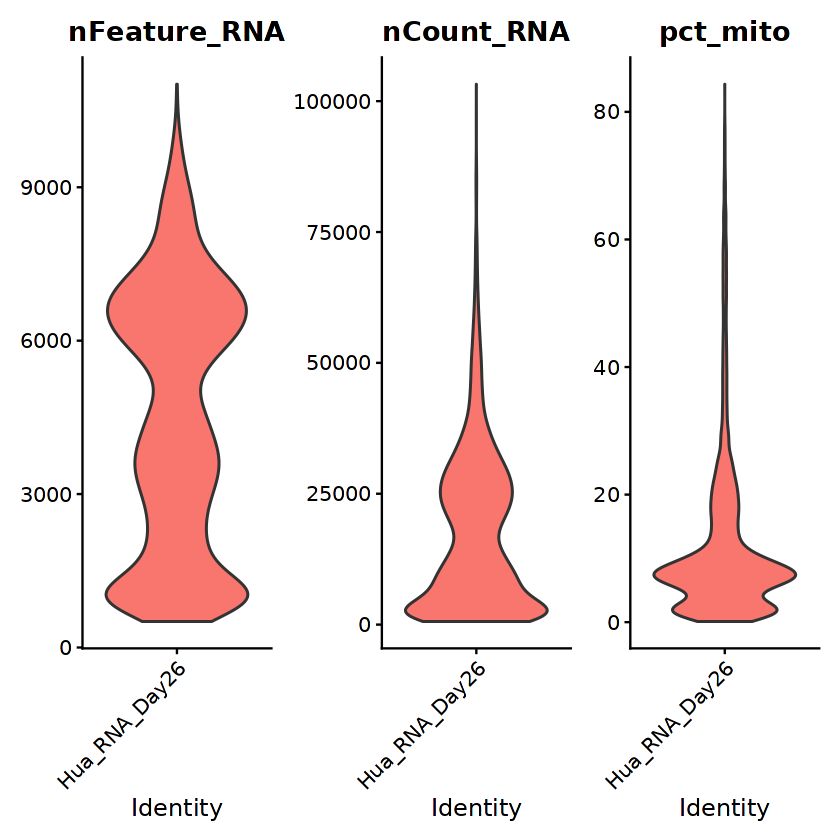

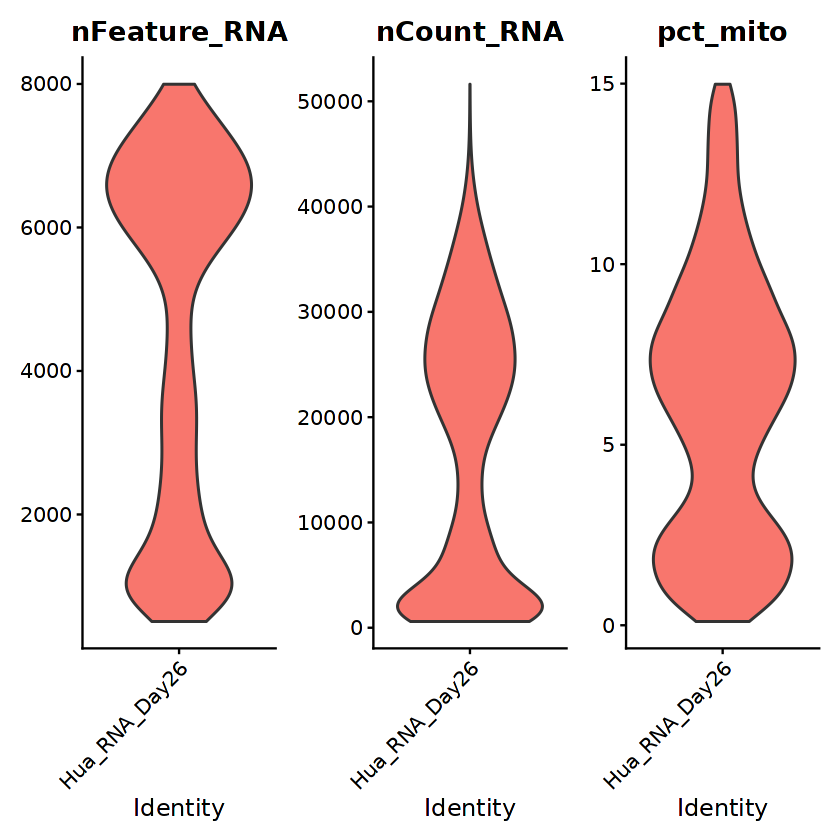

In [65]:
#Create Seurat object
hua.d26 <- CreateSeuratObject(counts = hua.raw, project = 'Hua_RNA_Day26', assay = 'RNA', min.cells = 10, min.features = 500)
rm('hua.raw')

#Add metadata
hua.d26 = RenameCells(hua.d26, add.cell.id = 'hua.d26')
hua.d26$modality <- 'expression'
hua.d26$dataset <- 'hua.d26'
hua.d26$protocol = 'Hua'
hua.d26$stage = 'Stage7_SCi'
hua.d26$day = 'Day26'
hua.d26$cellsource = 'iPSC_Peking'
hua.d26$gender = 'UNK'

#QC filtering
hua.d26[['pct_mito']] = PercentageFeatureSet(hua.d26, pattern = '^MT-')
VlnPlot(hua.d26, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

hua.d26 <- subset(hua.d26, subset = nFeature_RNA > 500 & nFeature_RNA < 8000 & pct_mito < 15)
VlnPlot(hua.d26, features = c('nFeature_RNA', 'nCount_RNA', 'pct_mito'), ncol = 3, pt.size = 0)

#Remove mitochondrial genes (MT) for consistency
all_genes = rownames(hua.d26)
anti_mt_genes = all_genes[grep(x = all_genes, pattern ='^MT-', invert = T)]
mt_genes = all_genes[grepl(x = all_genes, pattern = 'MT-')]
hua.d26 = subset(hua.d26, features = anti_mt_genes)

#Save Checkpoint
saveRDS(hua.d26, file='checkpoints/RNA_datasets/hua_rna_day26.rds')
rm(hua.d26)

# Merge RNA Data

## Reload each dataset

In [ ]:
data.list <- list()
meta <- data.frame()

files <- list.files(path = 'checkpoints/RNA_datasets', pattern="*.rds", full.names=FALSE)

for (i in seq_along(files)) {
    data <- readRDS(file = paste('checkpoints/RNA_datasets/', files[i], sep=""))  
    data.list <- append(data.list,data)
    
    meta<- bind_rows(meta,data.list[[i]][[]])
}

counts.list <- lapply(X = data.list, FUN = function(x) {
    x <- x[["RNA"]]$counts
})

obj <- CreateSeuratObject(counts = counts.list, names.field = 1, names.delim = "_", meta.data = meta)
rm(list = c('data.list','data','counts.list','meta'))

## Preprocess

In [ ]:
obj <- JoinLayers(obj)
obj[["RNA"]] <- split(obj[["RNA"]], f = obj$dataset)

suppressWarnings({
obj <- NormalizeData(obj, verbose = FALSE)
obj <- FindVariableFeatures(obj, verbose = FALSE)
obj <- ScaleData(obj, verbose = FALSE)
obj <- RunPCA(obj, verbose = FALSE)
obj <- RunUMAP(obj, reduction = "pca", dims = 1:30, reduction.name = "umap.merged.rna")
})

# Save RNA Data

In [ ]:
saveRDS(obj, file="checkpoints/DT_RNAmerged.rds")

In [ ]:
sink("Notebooks/3_DigitalTwin/01_DT_RNAPreprocess-sessionInfo.txt")
sessionInfo()
sink()

In [ ]:
# Mientras tanto este mundo gira y gira sin poderlo detener - Octavo Dia by Shakira